In [1]:
from pathlib import Path
import mne
import numpy as np
import matplotlib.pyplot as plt

# Notebook is inside ML_PROJECT1/notebooks,
# so move one level up to the project root.
PROJECT_ROOT = Path.cwd().parent

edf_path = PROJECT_ROOT / "data" / "CHB-MIT" / "chb01" / "chb01_03.edf"

print("Project root:", PROJECT_ROOT)
print("EDF:", edf_path)
print("Exists:", edf_path.exists())

raw = mne.io.read_raw_edf(
    edf_path,
    preload=True,
    verbose=False
)

print("\nRecording:")
print(raw)
print("\nSampling frequency:", raw.info["sfreq"])
print("Channels:", len(raw.ch_names))
print("Duration:", raw.times[-1], "seconds")

Project root: c:\Users\Soumya Bhardwaj\ML_PROJECT1
EDF: c:\Users\Soumya Bhardwaj\ML_PROJECT1\data\CHB-MIT\chb01\chb01_03.edf
Exists: True


C:\Users\Soumya Bhardwaj\AppData\Local\Temp\ipykernel_2128\1020820749.py:16: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(



Recording:
<RawEDF | chb01_03.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>

Sampling frequency: 256.0
Channels: 23
Duration: 3599.99609375 seconds


In [2]:
from pathlib import Path
import mne
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

edf_path = PROJECT_ROOT / "data" / "CHB-MIT" / "chb01" / "chb01_03.edf"

print("Project root:", PROJECT_ROOT)
print("EDF:", edf_path)
print("Exists:", edf_path.exists())

raw = mne.io.read_raw_edf(
    edf_path,
    preload=True,
    verbose=False
)

print("\nRecording:")
print(raw)
print("\nSampling frequency:", raw.info["sfreq"])
print("Channels:", len(raw.ch_names))
print("Duration:", raw.times[-1], "seconds")

Project root: c:\Users\Soumya Bhardwaj\ML_PROJECT1
EDF: c:\Users\Soumya Bhardwaj\ML_PROJECT1\data\CHB-MIT\chb01\chb01_03.edf
Exists: True

Recording:
<RawEDF | chb01_03.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>

Sampling frequency: 256.0
Channels: 23
Duration: 3599.99609375 seconds


C:\Users\Soumya Bhardwaj\AppData\Local\Temp\ipykernel_2128\1357760806.py:14: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


In [3]:
raw_filtered = raw.copy()

raw_filtered.filter(
    l_freq=0.5,
    h_freq=70.0,
    picks="eeg",
    verbose=False
)

print("Band-pass filtering complete.")
print("Frequency range: 0.5–70 Hz")

Band-pass filtering complete.
Frequency range: 0.5–70 Hz


Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


c:\Users\Soumya Bhardwaj\ML_PROJECT1\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


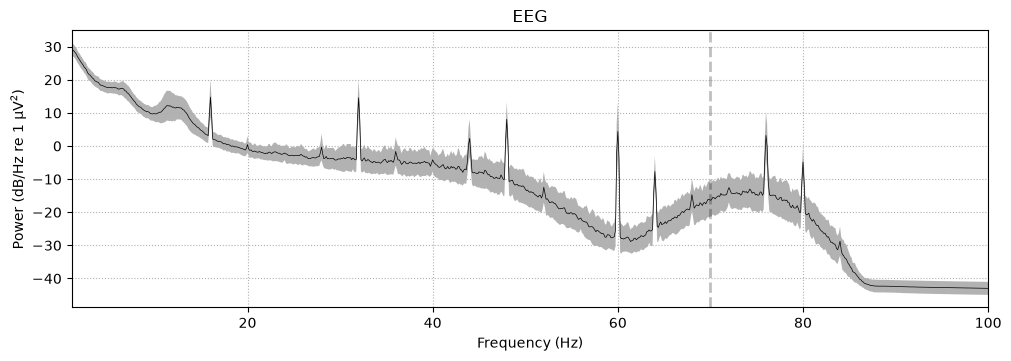

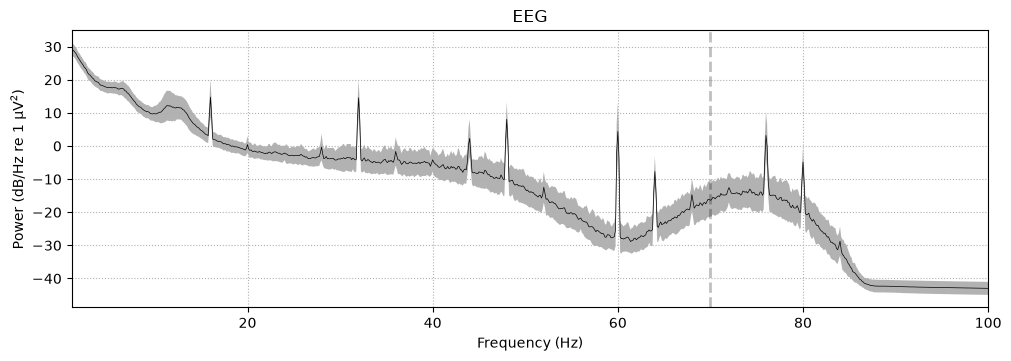

In [4]:
psd = raw_filtered.compute_psd(
    fmin=1,
    fmax=100,
    picks="eeg"
)

psd.plot(
    average=True,
    dB=True
)

In [5]:
# Defining the seizure interval from the CHB-MIT annotation
seizure_start = 2996
seizure_end = 3036

# Window configuration
window_size = 10       # seconds
step_size = 10         # seconds, no overlap for now

print("Seizure:", seizure_start, "to", seizure_end, "seconds")
print("Window size:", window_size, "seconds")
print("Step size:", step_size, "seconds")

Seizure: 2996 to 3036 seconds
Window size: 10 seconds
Step size: 10 seconds


In [6]:
# Labeling rule
MIN_SEIZURE_OVERLAP = 0.50

def get_window_label(window_start, window_end, seizure_start, seizure_end):
    """
    Assign a label to an EEG window based on its overlap
    with the annotated seizure interval.

    Returns:
        1 = seizure
        0 = non-seizure
        None = ambiguous / discard
    """
    
    overlap_start = max(window_start, seizure_start)
    overlap_end = min(window_end, seizure_end)

    overlap = max(0, overlap_end - overlap_start)
    window_duration = window_end - window_start

    overlap_ratio = overlap / window_duration

    if overlap_ratio >= MIN_SEIZURE_OVERLAP:
        return 1
    elif overlap_ratio == 0:
        return 0
    else:
        return None


# Test the rule
test_windows = [
    (2980, 2990),
    (2990, 3000),
    (3000, 3010),
    (3010, 3020),
    (3020, 3030),
    (3030, 3040),
    (3040, 3050),
]

for start, end in test_windows:
    label = get_window_label(
        start,
        end,
        seizure_start,
        seizure_end
    )

    print(f"{start:4d}-{end:4d} s  →  {label}")

2980-2990 s  →  0
2990-3000 s  →  None
3000-3010 s  →  1
3010-3020 s  →  1
3020-3030 s  →  1
3030-3040 s  →  1
3040-3050 s  →  0


In [7]:
# Generate 10-second windows from the recording

sfreq = raw_filtered.info["sfreq"]

window_samples = int(window_size * sfreq)
step_samples = int(step_size * sfreq)

windows = []
labels = []
window_times = []

n_samples = raw_filtered.n_times

for start_sample in range(0, n_samples - window_samples + 1, step_samples):

    end_sample = start_sample + window_samples

    start_time = start_sample / sfreq
    end_time = end_sample / sfreq

    label = get_window_label(
        start_time,
        end_time,
        seizure_start,
        seizure_end
    )

    # Keep only clearly labelled windows
    if label is not None:
        window = raw_filtered.get_data(
            start=start_sample,
            stop=end_sample
        )

        windows.append(window)
        labels.append(label)
        window_times.append((start_time, end_time))

windows = np.array(windows)
labels = np.array(labels)

print("Windows shape:", windows.shape)
print("Labels shape:", labels.shape)
print("Seizure windows:", np.sum(labels == 1))
print("Non-seizure windows:", np.sum(labels == 0))

Windows shape: (359, 23, 2560)
Labels shape: (359,)
Seizure windows: 4
Non-seizure windows: 355


In [8]:
print("One window shape:", windows[0].shape)
print("First window time:", window_times[0])
print("First window label:", labels[0])

print("\nLast window time:", window_times[-1])
print("Last window label:", labels[-1])

One window shape: (23, 2560)
First window time: (0.0, 10.0)
First window label: 0

Last window time: (3590.0, 3600.0)
Last window label: 0


In [9]:
seizure_indices = np.where(labels == 1)[0]

print("Seizure window indices:", seizure_indices)

for idx in seizure_indices:
    print(
        f"Window {idx}: "
        f"{window_times[idx][0]:.0f}-{window_times[idx][1]:.0f} s"
    )

Seizure window indices: [299 300 301 302]
Window 299: 3000-3010 s
Window 300: 3010-3020 s
Window 301: 3020-3030 s
Window 302: 3030-3040 s


In [10]:
import scipy
print(scipy.__version__)

1.17.1


In [11]:
import pandas as pd
from scipy.signal import welch

# Frequency bands
FREQUENCY_BANDS = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 70),
}


def extract_channel_features(signal, sfreq):
    """
    Extract interpretable time- and frequency-domain
    features from one EEG channel/window.
    """

    features = {}

    # -------------------------
    # Time-domain features
    # -------------------------

    features["mean"] = np.mean(signal)

    features["std"] = np.std(signal)

    features["variance"] = np.var(signal)

    features["rms"] = np.sqrt(np.mean(signal ** 2))

    # Line length
    features["line_length"] = np.sum(np.abs(np.diff(signal)))

    # -------------------------
    # Frequency-domain features
    # -------------------------

    frequencies, power = welch(
        signal,
        fs=sfreq,
        nperseg=min(len(signal), int(sfreq * 2))
    )

    total_power = np.trapezoid(power, frequencies)

    for band_name, (low, high) in FREQUENCY_BANDS.items():

        band_mask = (
            (frequencies >= low) &
            (frequencies < high)
        )

        band_power = np.trapezoid(
            power[band_mask],
            frequencies[band_mask]
        )

        # Relative power
        if total_power > 0:
            relative_power = band_power / total_power
        else:
            relative_power = 0

        features[f"{band_name}_relative_power"] = relative_power

    return features

In [12]:
sfreq = raw_filtered.info["sfreq"]

test_features = extract_channel_features(
    windows[0][0],
    sfreq
)

print("Number of features:", len(test_features))

for name, value in test_features.items():
    print(f"{name:25s}: {value:.6e}")

Number of features: 10
mean                     : 9.445993e-07
std                      : 2.660297e-05
variance                 : 7.077178e-10
rms                      : 2.661973e-05
line_length              : 1.088091e-02
delta_relative_power     : 4.552560e-01
theta_relative_power     : 1.586462e-01
alpha_relative_power     : 2.703360e-01
beta_relative_power      : 3.399464e-02
gamma_relative_power     : 1.087319e-02


In [13]:
all_features = []

sfreq = raw_filtered.info["sfreq"]

for window_idx, window in enumerate(windows):

    window_features = {
        "window_index": window_idx,
        "label": labels[window_idx]
    }

    for channel_idx, channel_name in enumerate(raw_filtered.ch_names):

        channel_features = extract_channel_features(
            window[channel_idx],
            sfreq
        )

        for feature_name, value in channel_features.items():

            column_name = f"{channel_name}_{feature_name}"

            window_features[column_name] = value

    all_features.append(window_features)


features_df = pd.DataFrame(all_features)

print("Feature matrix shape:", features_df.shape)
print("Number of windows:", len(features_df))
print("Number of feature columns:", len(features_df.columns) - 2)

Feature matrix shape: (359, 232)
Number of windows: 359
Number of feature columns: 230


In [14]:
print(features_df.head())
print("\nMissing values:", features_df.isna().sum().sum())
print("Infinite values:", np.isinf(features_df.select_dtypes(include=np.number)).sum().sum())

print("\nClass distribution:")
print(features_df["label"].value_counts())

print("\nClass percentages:")
print(features_df["label"].value_counts(normalize=True) * 100)

   window_index  label   FP1-F7_mean  FP1-F7_std  FP1-F7_variance  FP1-F7_rms  \
0             0      0  9.445993e-07    0.000027     7.077178e-10    0.000027   
1             1      0 -1.285704e-08    0.000030     9.166091e-10    0.000030   
2             2      0  4.427070e-08    0.000036     1.332046e-09    0.000036   
3             3      0 -2.897399e-07    0.000067     4.516309e-09    0.000067   
4             4      0 -2.469186e-07    0.000026     6.619004e-10    0.000026   

   FP1-F7_line_length  FP1-F7_delta_relative_power  \
0            0.010881                     0.455256   
1            0.011539                     0.428037   
2            0.012165                     0.525611   
3            0.025848                     0.642910   
4            0.008782                     0.418315   

   FP1-F7_theta_relative_power  FP1-F7_alpha_relative_power  ...  \
0                     0.158646                     0.270336  ...   
1                     0.150251                     0

In [15]:
results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)

features_path = results_dir / "features_chb01_03.csv"

features_df.to_csv(features_path, index=False)

print("Saved:", features_path)
print("File exists:", features_path.exists())
print("Size:", features_path.stat().st_size / 1024, "KB")

Saved: c:\Users\Soumya Bhardwaj\ML_PROJECT1\results\features_chb01_03.csv
File exists: True
Size: 1709.15625 KB


In [16]:
# Separate seizure and non-seizure windows
seizure_df = features_df[features_df["label"] == 1]
nonseizure_df = features_df[features_df["label"] == 0]

print("Seizure windows:", len(seizure_df))
print("Non-seizure windows:", len(nonseizure_df))


# Look at a few representative features from FP1-F7
features_to_check = [
    "FP1-F7_std",
    "FP1-F7_rms",
    "FP1-F7_line_length",
    "FP1-F7_delta_relative_power",
    "FP1-F7_theta_relative_power",
    "FP1-F7_alpha_relative_power",
    "FP1-F7_beta_relative_power",
    "FP1-F7_gamma_relative_power",
]

comparison = pd.DataFrame({
    "Feature": features_to_check,
    "Non-seizure mean": [
        nonseizure_df[f].mean() for f in features_to_check
    ],
    "Seizure mean": [
        seizure_df[f].mean() for f in features_to_check
    ],
})

comparison

Seizure windows: 4
Non-seizure windows: 355


,Feature,Non-seizure mean,Seizure mean
0,FP1-F7_std,0.000035,0.000114
1,FP1-F7_rms,0.000035,0.000114
2,FP1-F7_line_length,0.010571,0.045030
3,FP1-F7_delta_relative_power,0.591303,0.739208
4,FP1-F7_theta_relative_power,0.153551,0.098629
5,FP1-F7_alpha_relative_power,0.082148,0.007936
6,FP1-F7_beta_relative_power,0.044595,0.024327
7,FP1-F7_gamma_relative_power,0.022528,0.047473


In [17]:
print("raw_filtered exists:", "raw_filtered" in globals())
print("windows exists:", "windows" in globals())
print("labels exists:", "labels" in globals())

raw_filtered exists: True
windows exists: True
labels exists: True


In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
import mne

# Project root
PROJECT_ROOT = Path.cwd().parent

# EDF file
edf_path = PROJECT_ROOT / "data" / "CHB-MIT" / "chb01" / "chb01_03.edf"

print("Project root:", PROJECT_ROOT)
print("EDF:", edf_path)
print("Exists:", edf_path.exists())

raw = mne.io.read_raw_edf(
    edf_path,
    preload=True,
    verbose=False
)

print("\nSampling frequency:", raw.info["sfreq"], "Hz")
print("Channels:", len(raw.ch_names))
print("Duration:", raw.times[-1], "seconds")

Project root: c:\Users\Soumya Bhardwaj\ML_PROJECT1
EDF: c:\Users\Soumya Bhardwaj\ML_PROJECT1\data\CHB-MIT\chb01\chb01_03.edf
Exists: True

Sampling frequency: 256.0 Hz
Channels: 23
Duration: 3599.99609375 seconds


C:\Users\Soumya Bhardwaj\AppData\Local\Temp\ipykernel_2128\3282818937.py:16: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


In [ ]:
raw_filtered = raw.copy()

raw_filtered.filter(
    l_freq=0.5,
    h_freq=70.0,
    picks="eeg",
    verbose=False
)

print("Band-pass filtering complete.")
print("Frequency range: 0.5-70 Hz")

Band-pass filtering complete.
Frequency range: 0.5–70 Hz


In [20]:
# Compare one non-seizure window with one seizure window

non_seizure_idx = 298
seizure_idx = 299

non_seizure_window = windows[non_seizure_idx]
seizure_window = windows[seizure_idx]

print("Non-seizure window:")
print("Index:", non_seizure_idx)
print("Time:", window_times[non_seizure_idx])
print("Label:", labels[non_seizure_idx])

print("\nSeizure window:")
print("Index:", seizure_idx)
print("Time:", window_times[seizure_idx])
print("Label:", labels[seizure_idx])

print("\nWindow shape:", non_seizure_window.shape)

Non-seizure window:
Index: 298
Time: (2980.0, 2990.0)
Label: 0

Seizure window:
Index: 299
Time: (3000.0, 3010.0)
Label: 1

Window shape: (23, 2560)


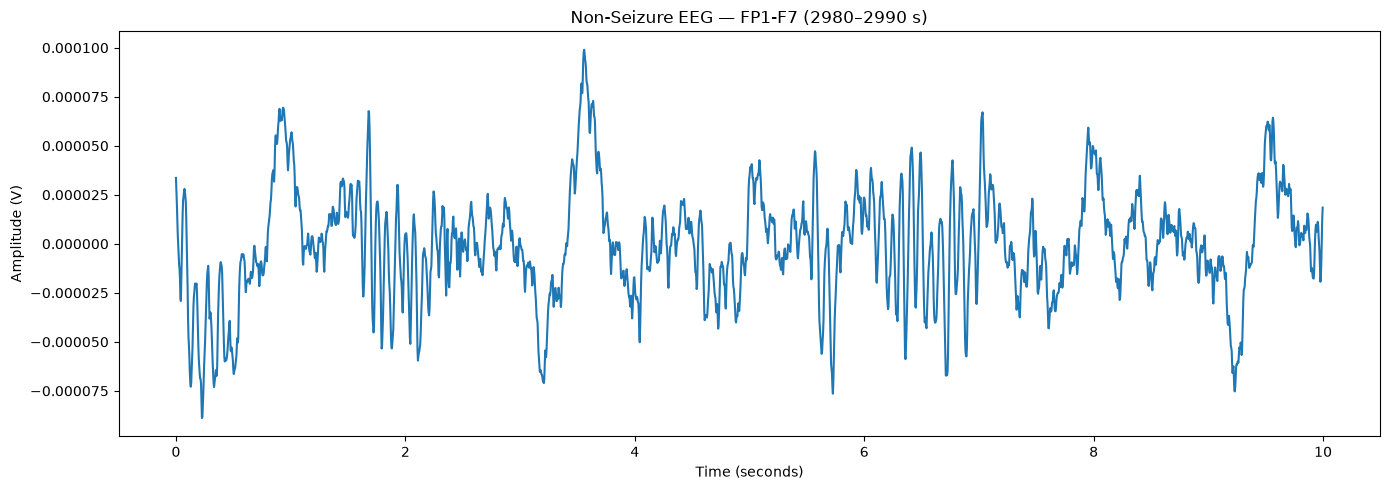

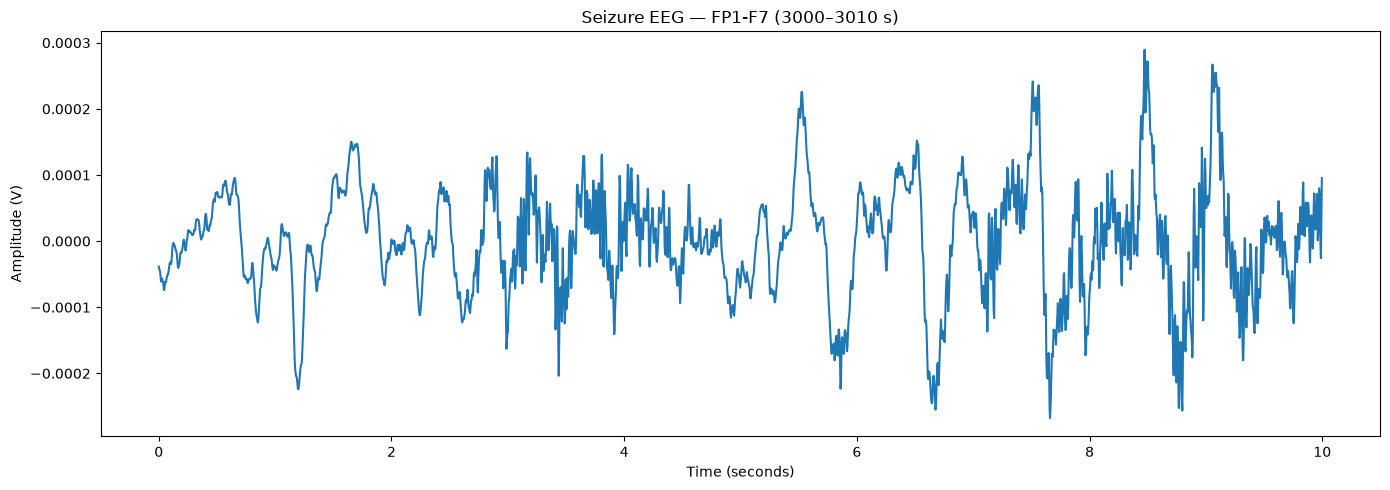

In [21]:
import matplotlib.pyplot as plt

channel_idx = raw_filtered.ch_names.index("FP1-F7")

non_seizure_signal = non_seizure_window[channel_idx]
seizure_signal = seizure_window[channel_idx]

time = np.arange(len(non_seizure_signal)) / raw_filtered.info["sfreq"]

plt.figure(figsize=(14, 5))

plt.plot(time, non_seizure_signal)

plt.title("Non-Seizure EEG — FP1-F7 (2980–2990 s)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (V)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))

plt.plot(time, seizure_signal)

plt.title("Seizure EEG — FP1-F7 (3000–3010 s)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (V)")
plt.tight_layout()
plt.show()

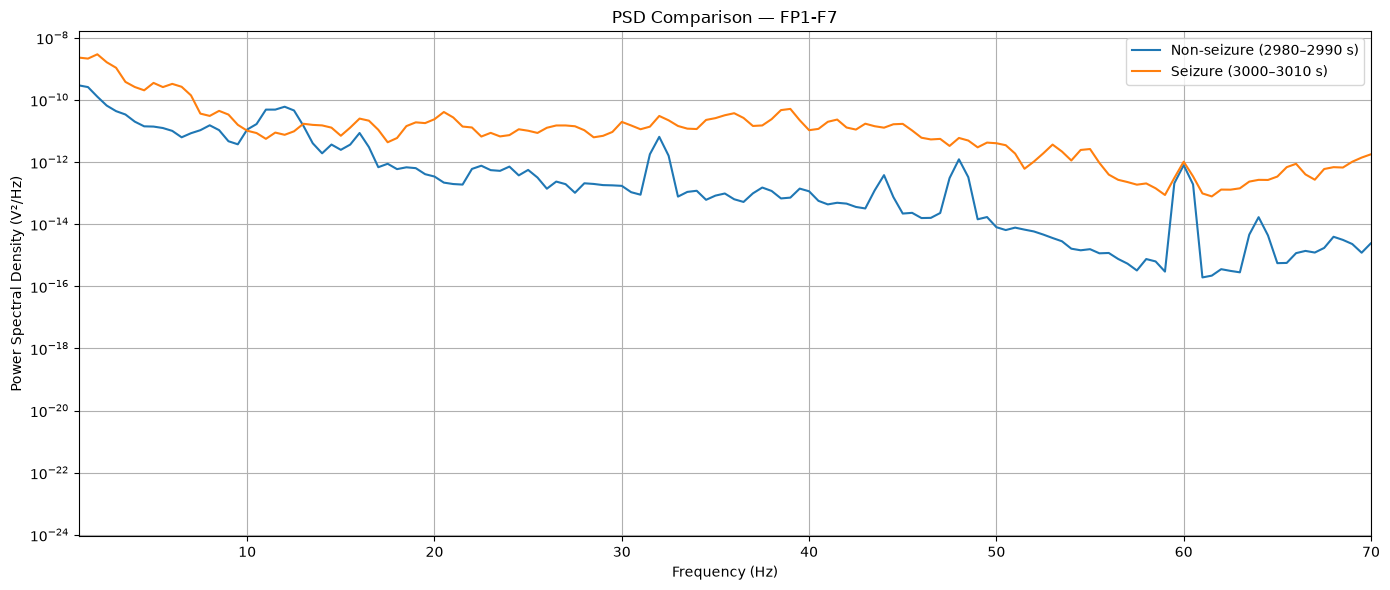

In [22]:
from scipy.signal import welch
import matplotlib.pyplot as plt

sfreq = raw_filtered.info["sfreq"]

# Calculate PSD for the same FP1-F7 windows
freq_non, psd_non = welch(
    non_seizure_signal,
    fs=sfreq,
    nperseg=sfreq * 2
)

freq_seiz, psd_seiz = welch(
    seizure_signal,
    fs=sfreq,
    nperseg=sfreq * 2
)

# Plot both on the same graph
plt.figure(figsize=(14, 6))

plt.semilogy(
    freq_non,
    psd_non,
    label="Non-seizure (2980–2990 s)"
)

plt.semilogy(
    freq_seiz,
    psd_seiz,
    label="Seizure (3000–3010 s)"
)

plt.xlim(1, 70)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (V²/Hz)")
plt.title("PSD Comparison — FP1-F7")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [23]:
from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt

sfreq = raw_filtered.info["sfreq"]

# PSD for the same two FP1-F7 windows
freq_non, psd_non = welch(
    non_seizure_signal,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

freq_seiz, psd_seiz = welch(
    seizure_signal,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

# Keep only frequencies between 1 and 70 Hz
mask_non = (freq_non >= 1) & (freq_non <= 70)
mask_seiz = (freq_seiz >= 1) & (freq_seiz <= 70)

# Log-transform
log_freq_non = np.log10(freq_non[mask_non])
log_psd_non = np.log10(psd_non[mask_non])

log_freq_seiz = np.log10(freq_seiz[mask_seiz])
log_psd_seiz = np.log10(psd_seiz[mask_seiz])

# Linear regression in log-log space
slope_non, intercept_non = np.polyfit(
    log_freq_non,
    log_psd_non,
    1
)

slope_seiz, intercept_seiz = np.polyfit(
    log_freq_seiz,
    log_psd_seiz,
    1
)

print("Spectral slope comparison")
print("--------------------------")
print(f"Non-seizure slope: {slope_non:.4f}")
print(f"Seizure slope:     {slope_seiz:.4f}")

Spectral slope comparison
--------------------------
Non-seizure slope: -3.4663
Seizure slope:     -2.0145


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# -----------------------------------------
# Noise configuration
# -----------------------------------------

sfreq = 256.0
duration = 10.0
n_samples = int(sfreq * duration)

rng = np.random.default_rng(42)

# Frequency range for comparison
fmin = 1
fmax = 70


# -----------------------------------------
# Generate white noise
# -----------------------------------------

white_noise = rng.normal(
    0,
    1,
    n_samples
)


# -----------------------------------------
# Generate colored noise using FFT
# -----------------------------------------

def generate_colored_noise(
    n_samples,
    sfreq,
    beta,
    rng
):
    """
    Generate noise with approximately

        PSD ∝ 1 / f^beta

    beta = 0 → white
    beta = 1 → pink
    beta = 3 → black
    """

    frequencies = np.fft.rfftfreq(
        n_samples,
        d=1 / sfreq
    )

    # Start with random Fourier coefficients
    spectrum = (
        rng.normal(size=len(frequencies))
        + 1j * rng.normal(size=len(frequencies))
    )

    # Avoid division by zero at DC
    scaling = np.ones_like(frequencies)

    nonzero = frequencies > 0

    scaling[nonzero] = (
        frequencies[nonzero] ** (-beta / 2)
    )

    spectrum *= scaling

    # Remove DC component
    spectrum[0] = 0

    # Convert back to time domain
    noise = np.fft.irfft(
        spectrum,
        n=n_samples
    )

    # Normalize
    noise = (
        noise - np.mean(noise)
    ) / np.std(noise)

    return noise


pink_noise = generate_colored_noise(
    n_samples,
    sfreq,
    beta=1,
    rng=rng
)

black_noise = generate_colored_noise(
    n_samples,
    sfreq,
    beta=3,
    rng=rng
)


print("Noise generation complete.")
print("Sampling frequency:", sfreq, "Hz")
print("Duration:", duration, "seconds")
print("Samples:", n_samples)

Noise generation complete.
Sampling frequency: 256.0 Hz
Duration: 10.0 seconds
Samples: 2560


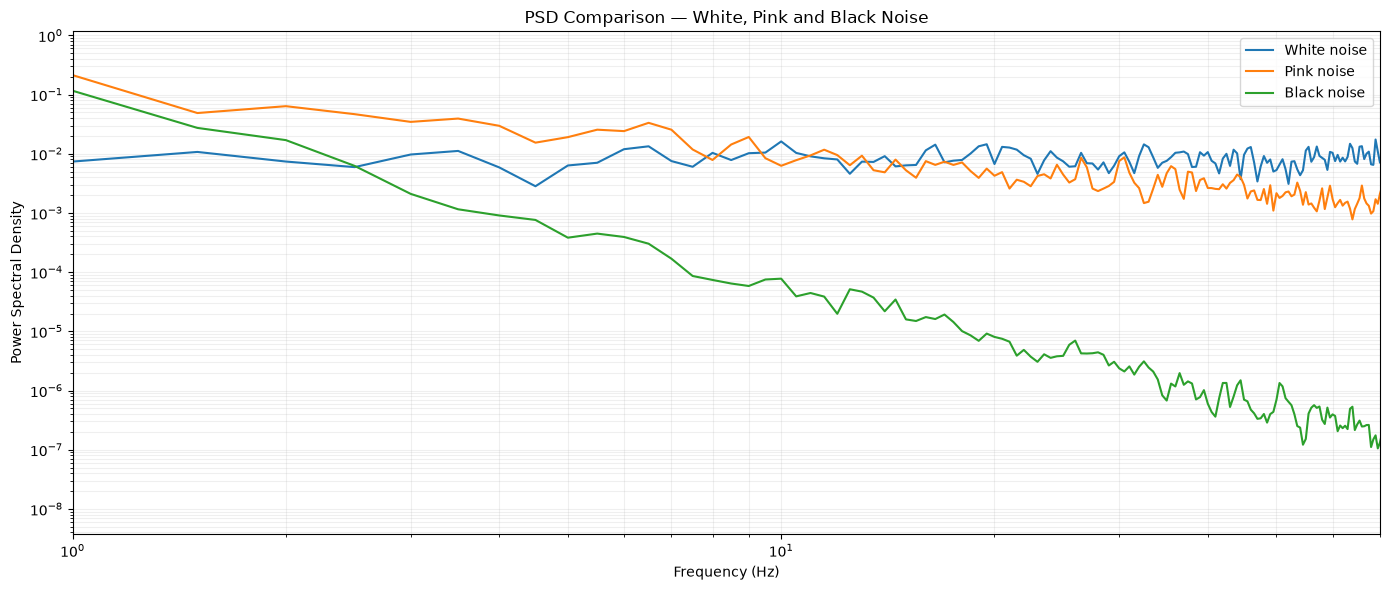

In [25]:
# -----------------------------------------
# Calculate PSD using Welch's method
# -----------------------------------------

freq_white, psd_white = welch(
    white_noise,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

freq_pink, psd_pink = welch(
    pink_noise,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

freq_black, psd_black = welch(
    black_noise,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)


# -----------------------------------------
# Plot noise PSDs
# -----------------------------------------

plt.figure(figsize=(14, 6))

plt.loglog(
    freq_white,
    psd_white,
    label="White noise"
)

plt.loglog(
    freq_pink,
    psd_pink,
    label="Pink noise"
)

plt.loglog(
    freq_black,
    psd_black,
    label="Black noise"
)

plt.xlim(fmin, fmax)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")

plt.title(
    "PSD Comparison — White, Pink and Black Noise"
)

plt.legend()
plt.grid(True, which="both", alpha=0.2)

plt.tight_layout()
plt.show()

In [26]:
from scipy.stats import linregress
import numpy as np

def calculate_spectral_slope(freq, psd, fmin=1, fmax=70):
    """
    Calculate spectral slope in log-log space.
    """

    mask = (
        (freq >= fmin) &
        (freq <= fmax) &
        (psd > 0)
    )

    log_freq = np.log10(freq[mask])
    log_psd = np.log10(psd[mask])

    slope, intercept, r_value, p_value, std_err = linregress(
        log_freq,
        log_psd
    )

    return slope


white_slope = calculate_spectral_slope(
    freq_white,
    psd_white
)

pink_slope = calculate_spectral_slope(
    freq_pink,
    psd_pink
)

black_slope = calculate_spectral_slope(
    freq_black,
    psd_black
)

print("Spectral slope comparison")
print("--------------------------")
print(f"White noise: {white_slope:.4f}")
print(f"Pink noise:  {pink_slope:.4f}")
print(f"Black noise: {black_slope:.4f}")

Spectral slope comparison
--------------------------
White noise: 0.0047
Pink noise:  -1.0343
Black noise: -3.0370


In [27]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------
# Stochastic Resonance — canonical model
# -----------------------------------------

# Simulation parameters
dt = 0.01
duration = 500       # seconds
sfreq = 1 / dt

# Weak periodic input
signal_amplitude = 0.20
signal_frequency = 0.05   # Hz

# Bistable system parameters
a = 1.0
b = 1.0

# Noise intensities to test
noise_levels = np.linspace(0.01, 0.30, 20)

rng = np.random.default_rng(42)

n_samples = int(duration / dt)

time = np.arange(n_samples) * dt

print("Stochastic Resonance simulation")
print("--------------------------------")
print("Duration:", duration, "seconds")
print("Sampling frequency:", sfreq, "Hz")
print("Signal amplitude:", signal_amplitude)
print("Signal frequency:", signal_frequency, "Hz")
print("Number of noise levels:", len(noise_levels))

Stochastic Resonance simulation
--------------------------------
Duration: 500 seconds
Sampling frequency: 100.0 Hz
Signal amplitude: 0.2
Signal frequency: 0.05 Hz
Number of noise levels: 20


In [28]:
def simulate_bistable_system(
    noise_intensity,
    time,
    dt,
    signal_amplitude,
    signal_frequency,
    a=1.0,
    b=1.0,
    rng=None
):
    """
    Simulate an overdamped bistable nonlinear system:

        dx/dt = ax - bx^3 + A cos(2πft) + noise

    The system has two stable states.
    """

    if rng is None:
        rng = np.random.default_rng()

    x = np.zeros(len(time))

    # Start in one stable state
    x[0] = -1.0

    for i in range(len(time) - 1):

        periodic_signal = (
            signal_amplitude *
            np.cos(2 * np.pi * signal_frequency * time[i])
        )

        deterministic_part = (
            a * x[i]
            - b * x[i] ** 3
            + periodic_signal
        )

        stochastic_part = (
            np.sqrt(2 * noise_intensity * dt)
            * rng.normal()
        )

        x[i + 1] = (
            x[i]
            + deterministic_part * dt
            + stochastic_part
        )

    return x

In [29]:
responses = []

for noise in noise_levels:

    output = simulate_bistable_system(
        noise_intensity=noise,
        time=time,
        dt=dt,
        signal_amplitude=signal_amplitude,
        signal_frequency=signal_frequency,
        a=a,
        b=b,
        rng=rng
    )

    # Remove initial transient
    start = int(0.2 * len(output))

    output_segment = output[start:]
    time_segment = time[start:]

    # Measure response at the driving frequency
    reference = np.cos(
        2 * np.pi *
        signal_frequency *
        time_segment
    )

    response = abs(
        np.mean(
            output_segment * reference
        )
    )

    responses.append(response)


responses = np.array(responses)

print("SR simulation complete.")
print("Maximum response:", responses.max())
print(
    "Optimal noise intensity:",
    noise_levels[np.argmax(responses)]
)

SR simulation complete.
Maximum response: 0.16867700947429154
Optimal noise intensity: 0.2236842105263158


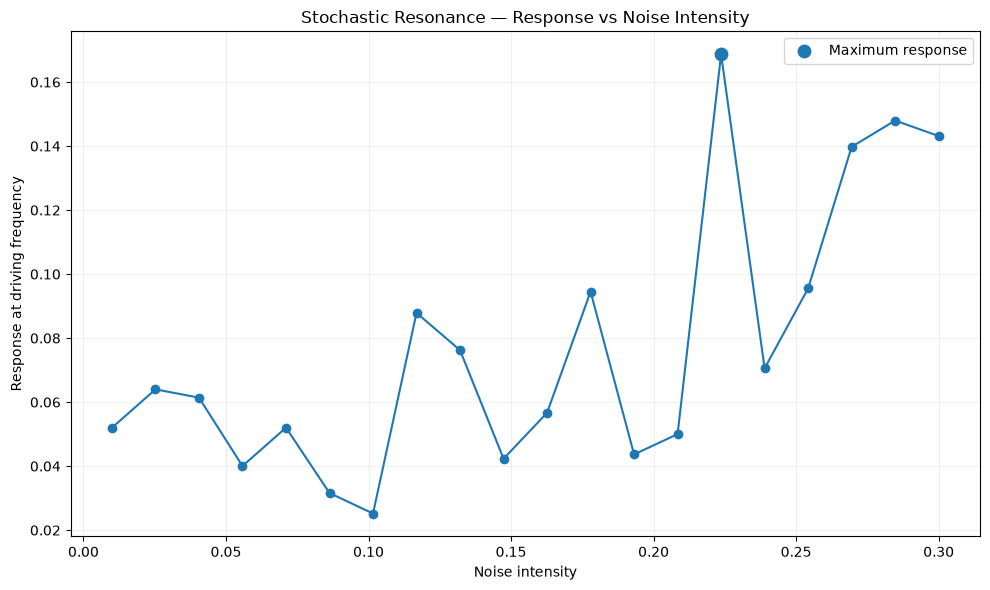

In [30]:
plt.figure(figsize=(10, 6))

plt.plot(
    noise_levels,
    responses,
    marker="o"
)

optimal_index = np.argmax(responses)

plt.scatter(
    noise_levels[optimal_index],
    responses[optimal_index],
    s=80,
    label="Maximum response"
)

plt.xlabel("Noise intensity")
plt.ylabel("Response at driving frequency")

plt.title(
    "Stochastic Resonance — Response vs Noise Intensity"
)

plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ---------------------------------------
# EEG-specific Stochastic Resonance
# FP1-F7 channel
# ---------------------------------------

channel_idx = 0   # FP1-F7

non_seizure_signal = windows[298][channel_idx]
seizure_signal = windows[299][channel_idx]

print("Non-seizure signal:", non_seizure_signal.shape)
print("Seizure signal:", seizure_signal.shape)
print("Sampling frequency:", sfreq)

Non-seizure signal: (2560,)
Seizure signal: (2560,)
Sampling frequency: 100.0


In [32]:
# Restore the actual EEG sampling frequency
sfreq = raw_filtered.info["sfreq"]

print("Actual EEG sampling frequency:", sfreq, "Hz")
print("Expected from window:", len(non_seizure_signal) / 10, "Hz")

Actual EEG sampling frequency: 256.0 Hz
Expected from window: 256.0 Hz


In [33]:
# ---------------------------------------
# EEG-specific Stochastic Resonance
# FP1-F7
# ---------------------------------------

from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt

def calculate_spectral_response(signal, sfreq):
    """
    Calculate the dominant-frequency response
    of an EEG signal.
    """
    frequencies, power = welch(
        signal,
        fs=sfreq,
        nperseg=sfreq * 2
    )

    # Focus on the EEG range
    mask = (frequencies >= 1) & (frequencies <= 70)

    frequencies = frequencies[mask]
    power = power[mask]

    # Dominant frequency
    dominant_idx = np.argmax(power)
    dominant_frequency = frequencies[dominant_idx]

    return dominant_frequency, power[dominant_idx]


# Find dominant frequencies of the two EEG windows

non_freq, non_response = calculate_spectral_response(
    non_seizure_signal,
    sfreq
)

seiz_freq, seiz_response = calculate_spectral_response(
    seizure_signal,
    sfreq
)

print("FP1-F7 EEG spectral response")
print("--------------------------------")
print(f"Non-seizure dominant frequency: {non_freq:.2f} Hz")
print(f"Non-seizure response: {non_response:.6e}")

print(f"\nSeizure dominant frequency: {seiz_freq:.2f} Hz")
print(f"Seizure response: {seiz_response:.6e}")

FP1-F7 EEG spectral response
--------------------------------
Non-seizure dominant frequency: 1.00 Hz
Non-seizure response: 2.926732e-10

Seizure dominant frequency: 2.00 Hz
Seizure response: 2.916559e-09


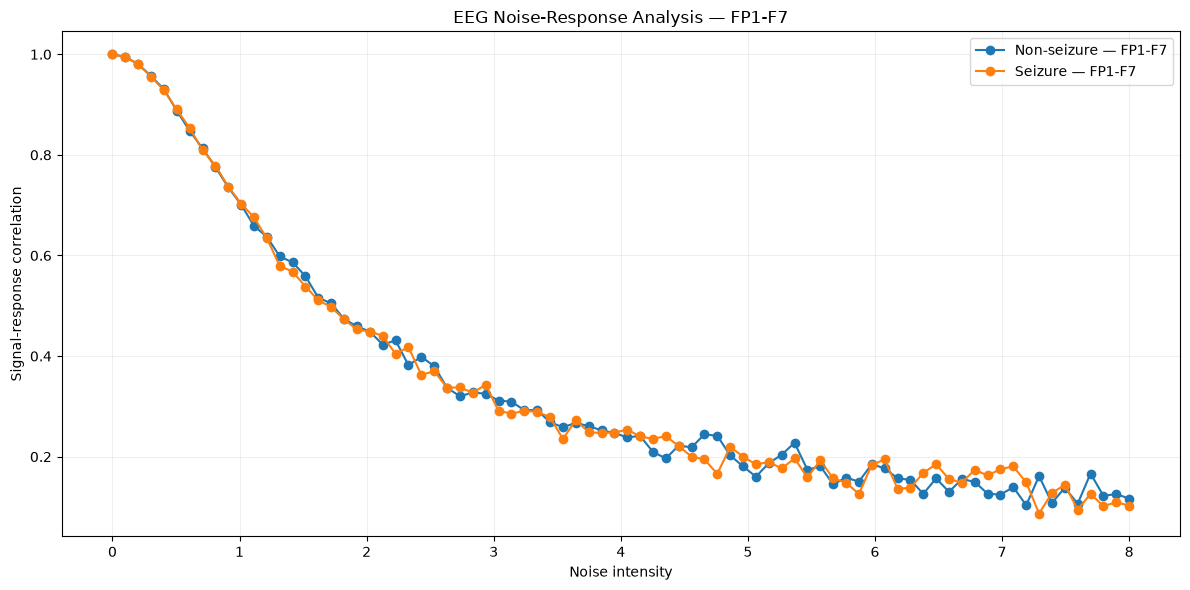

EEG noise-response results
---------------------------
Non-seizure maximum response: 1.0000
Non-seizure noise level: 0.00

Seizure maximum response: 1.0000
Seizure noise level: 0.00


In [34]:
# ==========================================
# EEG-specific Stochastic Resonance
# FP1-F7: seizure vs non-seizure
# ==========================================

from scipy.signal import correlate
import numpy as np
import matplotlib.pyplot as plt

# Make sure we are using the actual EEG sampling rate
sfreq = raw_filtered.info["sfreq"]

# The two windows we already selected
non_seizure_signal = windows[298][0]   # FP1-F7
seizure_signal = windows[299][0]       # FP1-F7

# Reproducible random generator
rng = np.random.default_rng(42)

# Normalize both signals so that noise intensity is comparable
non_seizure_norm = (
    non_seizure_signal - np.mean(non_seizure_signal)
) / np.std(non_seizure_signal)

seizure_norm = (
    seizure_signal - np.mean(seizure_signal)
) / np.std(seizure_signal)


# ------------------------------------------
# Noise levels
# ------------------------------------------

noise_levels = np.linspace(0.0, 8.0, 80)


# ------------------------------------------
# Response metric
# ------------------------------------------

def calculate_response(signal, noisy_signal):
    """
    Measure normalized zero-lag correlation
    between the original EEG and noisy EEG.
    """

    correlation = np.corrcoef(
        signal,
        noisy_signal
    )[0, 1]

    return abs(correlation)


# ------------------------------------------
# Run noise sweep
# ------------------------------------------

non_seizure_response = []
seizure_response = []

for noise_level in noise_levels:

    noise = rng.normal(
        0,
        noise_level,
        size=len(non_seizure_norm)
    )

    noisy_non_seizure = (
        non_seizure_norm + noise
    )

    noise = rng.normal(
        0,
        noise_level,
        size=len(seizure_norm)
    )

    noisy_seizure = (
        seizure_norm + noise
    )

    non_seizure_response.append(
        calculate_response(
            non_seizure_norm,
            noisy_non_seizure
        )
    )

    seizure_response.append(
        calculate_response(
            seizure_norm,
            noisy_seizure
        )
    )


non_seizure_response = np.array(
    non_seizure_response
)

seizure_response = np.array(
    seizure_response
)


# ------------------------------------------
# Plot
# ------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    noise_levels,
    non_seizure_response,
    marker="o",
    label="Non-seizure — FP1-F7"
)

plt.plot(
    noise_levels,
    seizure_response,
    marker="o",
    label="Seizure — FP1-F7"
)

plt.xlabel("Noise intensity")
plt.ylabel("Signal-response correlation")

plt.title(
    "EEG Noise-Response Analysis — FP1-F7"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ------------------------------------------
# Report maxima
# ------------------------------------------

non_idx = np.argmax(non_seizure_response)
seiz_idx = np.argmax(seizure_response)

print("EEG noise-response results")
print("---------------------------")

print(
    f"Non-seizure maximum response: "
    f"{non_seizure_response[non_idx]:.4f}"
)

print(
    f"Non-seizure noise level: "
    f"{noise_levels[non_idx]:.2f}"
)

print()

print(
    f"Seizure maximum response: "
    f"{seizure_response[seiz_idx]:.4f}"
)

print(
    f"Seizure noise level: "
    f"{noise_levels[seiz_idx]:.2f}"
)

Non-seizure characteristic frequency: 1.10 Hz
Seizure characteristic frequency: 2.20 Hz


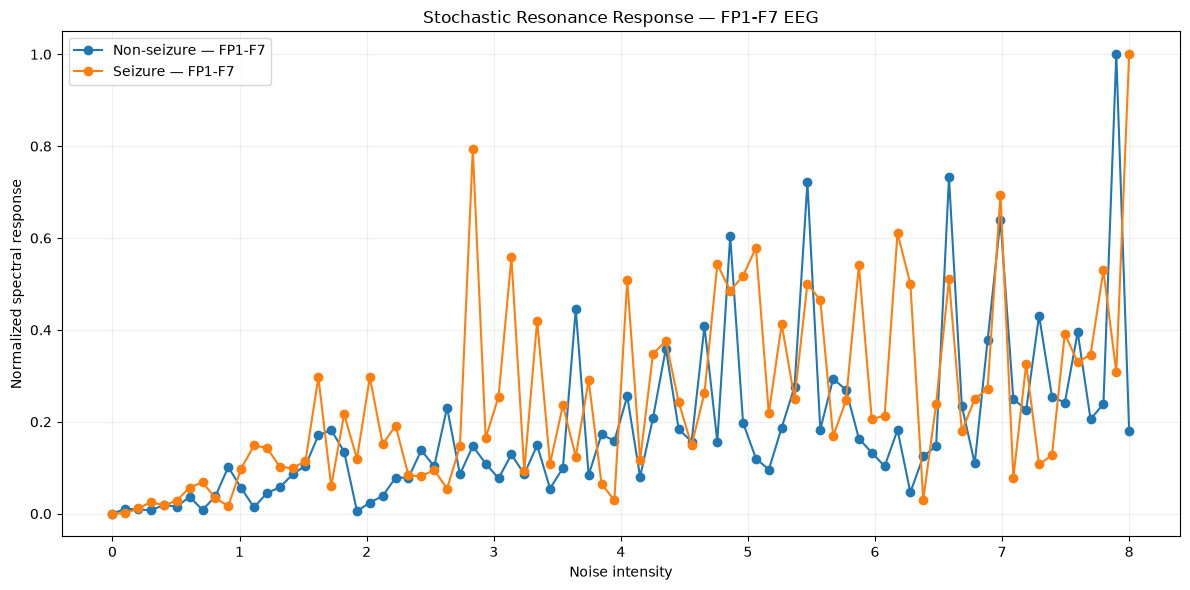


Stochastic Resonance Results
--------------------------------
Non-seizure optimal noise: 7.899
Non-seizure maximum response: 1.0000

Seizure optimal noise: 8.000
Seizure maximum response: 1.0000


In [35]:
# ==========================================
# Proper Stochastic Resonance Model
# FP1-F7 EEG
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ------------------------------------------------
# Make sure the correct EEG sampling frequency is used
# ------------------------------------------------

sfreq = raw_filtered.info["sfreq"]

# FP1-F7 windows
non_seizure_signal = windows[298][0]
seizure_signal = windows[299][0]

# ------------------------------------------------
# Normalize EEG signals
# ------------------------------------------------

def normalize_signal(signal):
    return (
        signal - np.mean(signal)
    ) / np.std(signal)


non_signal = normalize_signal(non_seizure_signal)
seiz_signal = normalize_signal(seizure_signal)


# ------------------------------------------------
# Find characteristic frequencies
# ------------------------------------------------

def dominant_frequency(signal, sfreq):

    frequencies, power = welch(
        signal,
        fs=sfreq,
        nperseg=len(signal)
    )

    mask = (
        (frequencies >= 1) &
        (frequencies <= 30)
    )

    frequencies = frequencies[mask]
    power = power[mask]

    idx = np.argmax(power)

    return frequencies[idx]


non_freq = dominant_frequency(
    non_signal,
    sfreq
)

seiz_freq = dominant_frequency(
    seiz_signal,
    sfreq
)

print("Non-seizure characteristic frequency:",
      f"{non_freq:.2f} Hz")

print("Seizure characteristic frequency:",
      f"{seiz_freq:.2f} Hz")


# ------------------------------------------------
# Bistable stochastic-resonance simulation
# ------------------------------------------------

def bistable_sr(signal, sfreq, noise_intensity,
                input_scale=0.20):

    dt = 1.0 / sfreq

    x = np.zeros(len(signal))

    # Start near one stable state
    x[0] = -1.0

    for i in range(1, len(signal)):

        # Bistable nonlinear force
        nonlinear_force = (
            x[i-1] -
            x[i-1] ** 3
        )

        # EEG driving force
        driving_force = (
            input_scale *
            signal[i-1]
        )

        # Stochastic force
        stochastic_force = (
            np.sqrt(2 * noise_intensity * dt) *
            np.random.normal()
        )

        # Euler integration
        x[i] = (
            x[i-1]
            + dt * (
                nonlinear_force +
                driving_force
            )
            + stochastic_force
        )

        # Numerical safety
        if x[i] > 3:
            x[i] = 3

        elif x[i] < -3:
            x[i] = -3

    return x


# ------------------------------------------------
# Measure spectral response
# ------------------------------------------------

def spectral_response(signal, sfreq, target_frequency):

    frequencies, power = welch(
        signal,
        fs=sfreq,
        nperseg=len(signal)
    )

    # Look close to the characteristic frequency
    band = (
        (frequencies >= target_frequency - 0.2) &
        (frequencies <= target_frequency + 0.2)
    )

    if not np.any(band):
        return 0

    return np.max(power[band])


# ------------------------------------------------
# Noise sweep
# ------------------------------------------------

noise_levels = np.linspace(
    0.0,
    8.0,
    80
)

non_responses = []
seiz_responses = []


# Fixed random seed for reproducibility
np.random.seed(42)


for noise_level in noise_levels:

    # Non-seizure
    non_output = bistable_sr(
        non_signal,
        sfreq,
        noise_level
    )

    non_response = spectral_response(
        non_output,
        sfreq,
        non_freq
    )

    non_responses.append(
        non_response
    )


    # Seizure
    seiz_output = bistable_sr(
        seiz_signal,
        sfreq,
        noise_level
    )

    seiz_response = spectral_response(
        seiz_output,
        sfreq,
        seiz_freq
    )

    seiz_responses.append(
        seiz_response
    )


non_responses = np.array(non_responses)
seiz_responses = np.array(seiz_responses)


# ------------------------------------------------
# Normalize response curves
# ------------------------------------------------

if np.max(non_responses) > 0:
    non_responses_norm = (
        non_responses /
        np.max(non_responses)
    )
else:
    non_responses_norm = non_responses


if np.max(seiz_responses) > 0:
    seiz_responses_norm = (
        seiz_responses /
        np.max(seiz_responses)
    )
else:
    seiz_responses_norm = seiz_responses


# ------------------------------------------------
# Plt SR response curves
# ------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    noise_levels,
    non_responses_norm,
    marker="o",
    label="Non-seizure — FP1-F7"
)

plt.plot(
    noise_levels,
    seiz_responses_norm,
    marker="o",
    label="Seizure — FP1-F7"
)

plt.xlabel("Noise intensity")
plt.ylabel("Normalized spectral response")

plt.title(
    "Stochastic Resonance Response — FP1-F7 EEG"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ------------------------------------------------
# Find optimal noise levels
# ------------------------------------------------

non_idx = np.argmax(non_responses)
seiz_idx = np.argmax(seiz_responses)

print("\nStochastic Resonance Results")
print("--------------------------------")

print(
    f"Non-seizure optimal noise: "
    f"{noise_levels[non_idx]:.3f}"
)

print(
    f"Non-seizure maximum response: "
    f"{non_responses_norm[non_idx]:.4f}"
)

print()

print(
    f"Seizure optimal noise: "
    f"{noise_levels[seiz_idx]:.3f}"
)

print(
    f"Seizure maximum response: "
    f"{seiz_responses_norm[seiz_idx]:.4f}"
)

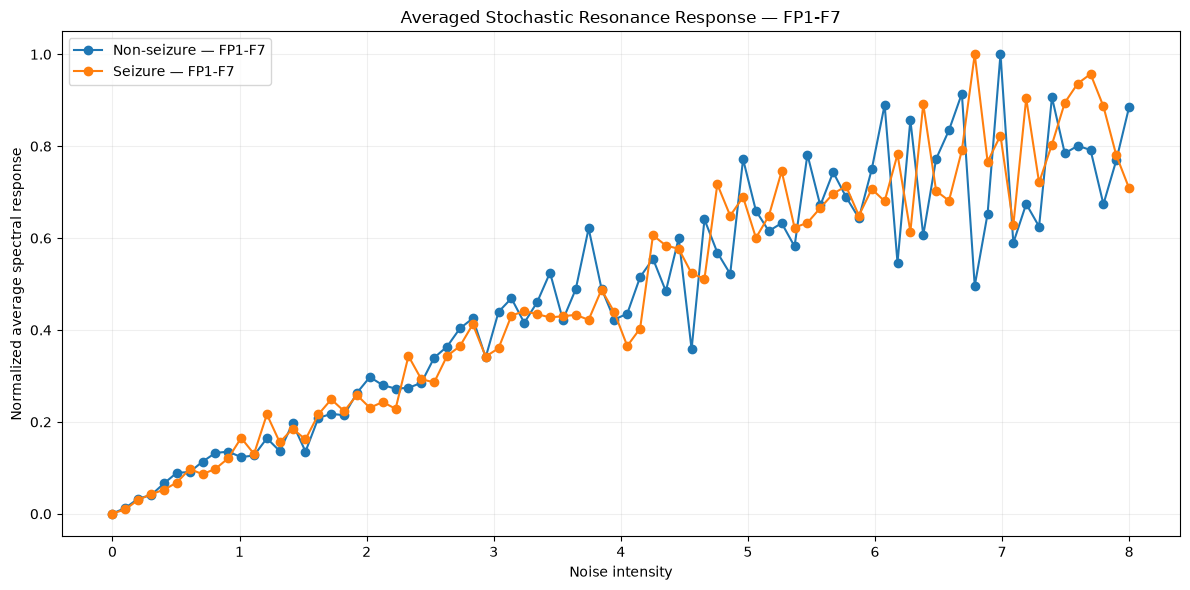

Final SR Analysis
Number of trials per noise level: 20

Non-seizure optimal noise: 6.987
Non-seizure maximum response: 1.0000

Seizure optimal noise: 6.785
Seizure maximum response: 1.0000


In [36]:
# ==========================================
# Final SR Analysis — Averaged Trials
# FP1-F7 EEG
# ==========================================

# Number of independent stochastic trials
N_TRIALS = 20

# Store averaged responses
non_responses_avg = []
seiz_responses_avg = []

# Use a reproducible random generator
rng = np.random.default_rng(42)


for noise_level in noise_levels:

    non_trial_responses = []
    seiz_trial_responses = []

    for trial in range(N_TRIALS):

        # -------------------------------
        # Non-seizure SR simulation
        # -------------------------------

        non_output = bistable_sr(
            non_signal,
            sfreq,
            noise_level
        )

        non_response = spectral_response(
            non_output,
            sfreq,
            non_freq
        )

        non_trial_responses.append(
            non_response
        )


        # -------------------------------
        # Seizure SR simulation
        # -------------------------------

        seiz_output = bistable_sr(
            seiz_signal,
            sfreq,
            noise_level
        )

        seiz_response = spectral_response(
            seiz_output,
            sfreq,
            seiz_freq
        )

        seiz_trial_responses.append(
            seiz_response
        )


    # Average across stochastic trials
    non_responses_avg.append(
        np.mean(non_trial_responses)
    )

    seiz_responses_avg.append(
        np.mean(seiz_trial_responses)
    )


non_responses_avg = np.array(non_responses_avg)
seiz_responses_avg = np.array(seiz_responses_avg)


# ------------------------------------------
# Normalize for comparison
# ------------------------------------------

non_responses_avg_norm = (
    non_responses_avg /
    np.max(non_responses_avg)
)

seiz_responses_avg_norm = (
    seiz_responses_avg /
    np.max(seiz_responses_avg)
)


# ------------------------------------------
# Find optimal noise levels
# ------------------------------------------

non_opt_idx = np.argmax(
    non_responses_avg
)

seiz_opt_idx = np.argmax(
    seiz_responses_avg
)


# ------------------------------------------
# Plot averaged SR curves
# ------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    noise_levels,
    non_responses_avg_norm,
    marker="o",
    label="Non-seizure — FP1-F7"
)

plt.plot(
    noise_levels,
    seiz_responses_avg_norm,
    marker="o",
    label="Seizure — FP1-F7"
)

plt.xlabel("Noise intensity")

plt.ylabel(
    "Normalized average spectral response"
)

plt.title(
    "Averaged Stochastic Resonance Response — FP1-F7"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ------------------------------------------
# Final SR results
# ------------------------------------------

print("Final SR Analysis")
print("=================")

print(
    f"Number of trials per noise level: {N_TRIALS}"
)

print()

print(
    f"Non-seizure optimal noise: "
    f"{noise_levels[non_opt_idx]:.3f}"
)

print(
    f"Non-seizure maximum response: "
    f"{non_responses_avg_norm[non_opt_idx]:.4f}"
)

print()

print(
    f"Seizure optimal noise: "
    f"{noise_levels[seiz_opt_idx]:.3f}"
)

print(
    f"Seizure maximum response: "
    f"{seiz_responses_avg_norm[seiz_opt_idx]:.4f}"
)

In [37]:
# ==========================================
# Corrected SR spectral-SNR response
# FP1-F7 EEG
# ==========================================

from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt


def spectral_snr_response(signal, sfreq, target_frequency):
    """
    Calculate output spectral SNR around the
    characteristic frequency.

    Signal power is estimated near target_frequency.
    Noise floor is estimated from neighboring frequencies.
    """

    frequencies, power = welch(
        signal,
        fs=sfreq,
        nperseg=len(signal)
    )

    # Signal band around characteristic frequency
    signal_band = (
        (frequencies >= target_frequency - 0.2) &
        (frequencies <= target_frequency + 0.2)
    )

    # Noise-floor region
    # Exclude the signal band itself
    noise_band = (
        (frequencies >= max(0.5, target_frequency - 2.0)) &
        (frequencies <= target_frequency + 2.0) &
        ~signal_band
    )

    if not np.any(signal_band) or not np.any(noise_band):
        return np.nan

    signal_power = np.mean(
        power[signal_band]
    )

    noise_floor = np.mean(
        power[noise_band]
    )

    if noise_floor <= 0:
        return np.nan

    snr_db = 10 * np.log10(
        signal_power / noise_floor
    )

    return snr_db

In [38]:
# Test the corrected SR response metric

test_non_output = bistable_sr(
    non_signal,
    sfreq,
    noise_intensity=1.0
)

test_seiz_output = bistable_sr(
    seiz_signal,
    sfreq,
    noise_intensity=1.0
)

non_test_snr = spectral_snr_response(
    test_non_output,
    sfreq,
    non_freq
)

seiz_test_snr = spectral_snr_response(
    test_seiz_output,
    sfreq,
    seiz_freq
)

print("Corrected SR response test")
print("--------------------------------")
print(f"Non-seizure SNR: {non_test_snr:.3f} dB")
print(f"Seizure SNR:     {seiz_test_snr:.3f} dB")

Corrected SR response test
--------------------------------
Non-seizure SNR: -1.703 dB
Seizure SNR:     -5.537 dB


In [39]:
# ==========================================
# SR Sweep using Spectral SNR
# FP1-F7 EEG
# ==========================================

N_TRIALS = 20

# Noise intensity range
noise_levels = np.linspace(
    0.0,
    8.0,
    41
)

non_snr_mean = []
seiz_snr_mean = []

non_snr_std = []
seiz_snr_std = []


# Reproducible random generator
rng = np.random.default_rng(42)


for noise_level in noise_levels:

    non_trial_snr = []
    seiz_trial_snr = []

    for trial in range(N_TRIALS):

        # -------------------------
        # Non-seizure
        # -------------------------

        non_output = bistable_sr(
            non_signal,
            sfreq,
            noise_level
        )

        non_snr = spectral_snr_response(
            non_output,
            sfreq,
            non_freq
        )

        non_trial_snr.append(non_snr)


        # -------------------------
        # Seizure
        # -------------------------

        seiz_output = bistable_sr(
            seiz_signal,
            sfreq,
            noise_level
        )

        seiz_snr = spectral_snr_response(
            seiz_output,
            sfreq,
            seiz_freq
        )

        seiz_trial_snr.append(seiz_snr)


    # Average over trials
    non_snr_mean.append(
        np.nanmean(non_trial_snr)
    )

    seiz_snr_mean.append(
        np.nanmean(seiz_trial_snr)
    )

    non_snr_std.append(
        np.nanstd(non_trial_snr)
    )

    seiz_snr_std.append(
        np.nanstd(seiz_trial_snr)
    )


non_snr_mean = np.array(non_snr_mean)
seiz_snr_mean = np.array(seiz_snr_mean)

non_snr_std = np.array(non_snr_std)
seiz_snr_std = np.array(seiz_snr_std)


# ==========================================
# Find actual maxima BEFORE normalization
# ==========================================

non_opt_idx = np.nanargmax(non_snr_mean)
seiz_opt_idx = np.nanargmax(seiz_snr_mean)


print("Stochastic Resonance — Spectral SNR")
print("------------------------------------------")

print(
    f"Non-seizure optimal noise: "
    f"{noise_levels[non_opt_idx]:.3f}"
)

print(
    f"Non-seizure maximum SNR: "
    f"{non_snr_mean[non_opt_idx]:.3f} dB"
)

print()

print(
    f"Seizure optimal noise: "
    f"{noise_levels[seiz_opt_idx]:.3f}"
)

print(
    f"Seizure maximum SNR: "
    f"{seiz_snr_mean[seiz_opt_idx]:.3f} dB"
)

Stochastic Resonance — Spectral SNR
------------------------------------------
Non-seizure optimal noise: 0.000
Non-seizure maximum SNR: 5.666 dB

Seizure optimal noise: 0.000
Seizure maximum SNR: 0.433 dB


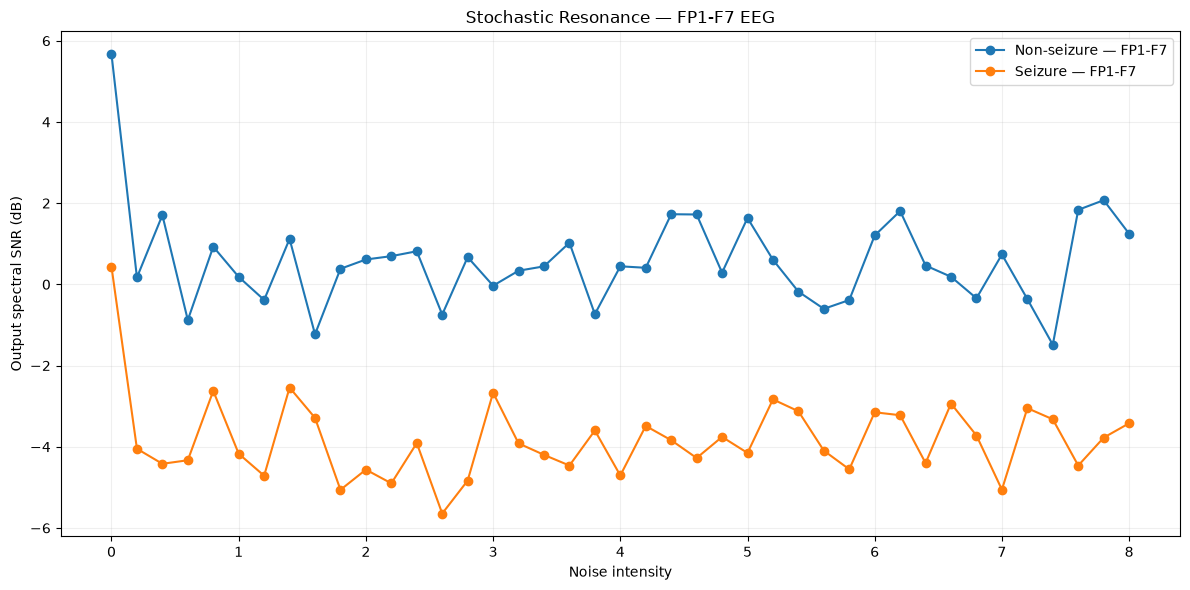

In [40]:
# ==========================================
# SR Spectral-SNR Curves
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(
    noise_levels,
    non_snr_mean,
    marker="o",
    label="Non-seizure — FP1-F7"
)

plt.plot(
    noise_levels,
    seiz_snr_mean,
    marker="o",
    label="Seizure — FP1-F7"
)

plt.xlabel("Noise intensity")
plt.ylabel("Output spectral SNR (dB)")

plt.title(
    "Stochastic Resonance — FP1-F7 EEG"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [41]:
# ==========================================
# SR RESTART — Extract characteristic EEG component
# FP1-F7
# ==========================================

from scipy.signal import butter, filtfilt, welch
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# Basic parameters
# ------------------------------------------------

sfreq = raw_filtered.info["sfreq"]

non_seizure_signal = windows[298][0]
seizure_signal = windows[299][0]

print("Sampling frequency:", sfreq)
print("Non-seizure signal:", non_seizure_signal.shape)
print("Seizure signal:", seizure_signal.shape)


# ------------------------------------------------
# Characteristic frequencies found previously
# ------------------------------------------------

non_freq = 1.10
seiz_freq = 2.20

print()
print("Non-seizure characteristic frequency:",
      non_freq, "Hz")

print("Seizure characteristic frequency:",
      seiz_freq, "Hz")


# ------------------------------------------------
# Band-pass around characteristic frequency
# ------------------------------------------------

def extract_characteristic_component(
    signal,
    sfreq,
    center_frequency,
    bandwidth=0.5
):

    low = max(0.2, center_frequency - bandwidth)
    high = min(
        sfreq / 2 - 1,
        center_frequency + bandwidth
    )

    b, a = butter(
        3,
        [low, high],
        btype="bandpass",
        fs=sfreq
    )

    component = filtfilt(
        b,
        a,
        signal
    )

    return component


non_component = extract_characteristic_component(
    non_seizure_signal,
    sfreq,
    non_freq
)

seiz_component = extract_characteristic_component(
    seizure_signal,
    sfreq,
    seiz_freq
)


# ------------------------------------------------
# Normalize characteristic components
# ------------------------------------------------

non_component = (
    non_component -
    np.mean(non_component)
) / np.std(non_component)

seiz_component = (
    seiz_component -
    np.mean(seiz_component)
) / np.std(seiz_component)


print()
print("Characteristic components extracted.")
print("Non-seizure std:",
      np.std(non_component))

print("Seizure std:",
      np.std(seiz_component))

Sampling frequency: 256.0
Non-seizure signal: (2560,)
Seizure signal: (2560,)

Non-seizure characteristic frequency: 1.1 Hz
Seizure characteristic frequency: 2.2 Hz

Characteristic components extracted.
Non-seizure std: 1.0
Seizure std: 1.0


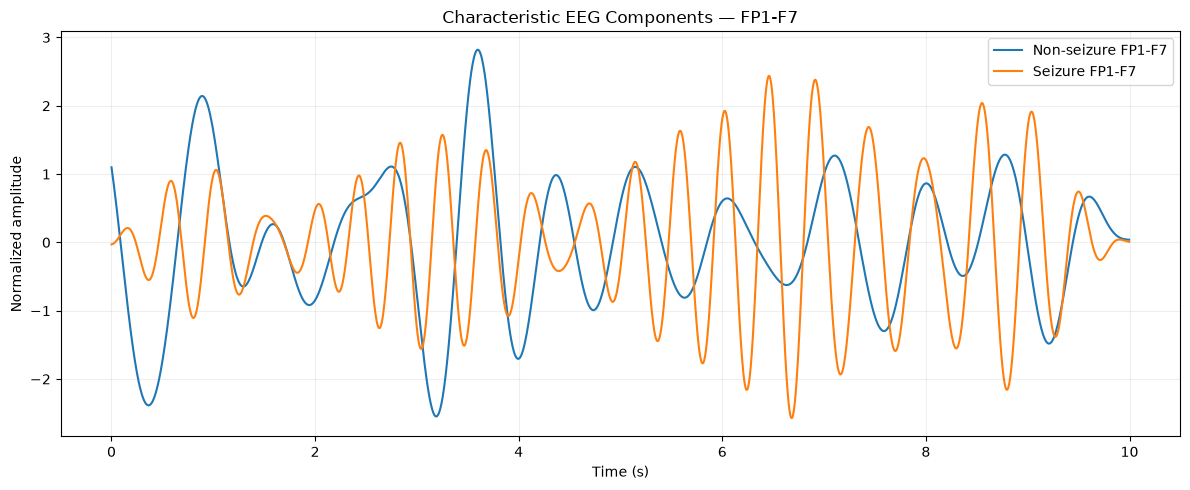

In [42]:
# ==========================================
# Visual verification
# ==========================================

time = np.arange(len(non_component)) / sfreq

plt.figure(figsize=(12, 5))

plt.plot(
    time,
    non_component,
    label="Non-seizure FP1-F7"
)

plt.plot(
    time,
    seiz_component,
    label="Seizure FP1-F7"
)

plt.xlabel("Time (s)")
plt.ylabel("Normalized amplitude")

plt.title(
    "Characteristic EEG Components — FP1-F7"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [43]:
# ==========================================
# Canonical Bistable Stochastic Resonance
# ==========================================

def bistable_sr_component(
    input_signal,
    sfreq,
    noise_intensity,
    input_scale=0.20
):

    dt = 1.0 / sfreq

    x = np.zeros(len(input_signal))

    # Start in one stable well
    x[0] = -1.0

    for i in range(1, len(input_signal)):

        # Bistable nonlinear force
        nonlinear_force = (
            x[i-1] -
            x[i-1] ** 3
        )

        # Weak EEG driving signal
        driving_force = (
            input_scale *
            input_signal[i-1]
        )

        # Gaussian white noise
        stochastic_force = (
            np.sqrt(
                2 *
                noise_intensity *
                dt
            )
            *
            np.random.normal()
        )

        # Euler integration
        x[i] = (
            x[i-1]
            +
            dt *
            (
                nonlinear_force
                +
                driving_force
            )
            +
            stochastic_force
        )

        # Numerical safety
        x[i] = np.clip(
            x[i],
            -3,
            3
        )

    return x

In [44]:
# ==========================================
# Output Spectral SNR
# ==========================================

def calculate_snr(
    output,
    sfreq,
    target_frequency
):

    frequencies, power = welch(
        output,
        fs=sfreq,
        nperseg=len(output)
    )

    # Signal band
    signal_band = (
        (frequencies >= target_frequency - 0.15) &
        (frequencies <= target_frequency + 0.15)
    )

    # Noise floor:
    # nearby frequencies excluding signal band
    noise_band = (
        (frequencies >= max(
            0.2,
            target_frequency - 1.0
        ))
        &
        (frequencies <= target_frequency + 1.0)
        &
        (~signal_band)
    )

    if (
        not np.any(signal_band)
        or
        not np.any(noise_band)
    ):
        return np.nan

    signal_power = np.mean(
        power[signal_band]
    )

    noise_power = np.mean(
        power[noise_band]
    )

    if noise_power <= 0:
        return np.nan

    return 10 * np.log10(
        signal_power /
        noise_power
    )

In [45]:
# ==========================================
# SR Sanity Test
# ==========================================

np.random.seed(42)

test_noise = 0.10

non_test_output = bistable_sr_component(
    non_component,
    sfreq,
    test_noise
)

seiz_test_output = bistable_sr_component(
    seiz_component,
    sfreq,
    test_noise
)

non_test_snr = calculate_snr(
    non_test_output,
    sfreq,
    non_freq
)

seiz_test_snr = calculate_snr(
    seiz_test_output,
    sfreq,
    seiz_freq
)

print("SR Sanity Test")
print("--------------------------------")

print(
    f"Noise intensity: {test_noise}"
)

print(
    f"Non-seizure SNR: "
    f"{non_test_snr:.3f} dB"
)

print(
    f"Seizure SNR: "
    f"{seiz_test_snr:.3f} dB"
)

SR Sanity Test
--------------------------------
Noise intensity: 0.1
Non-seizure SNR: -7.461 dB
Seizure SNR: -6.390 dB


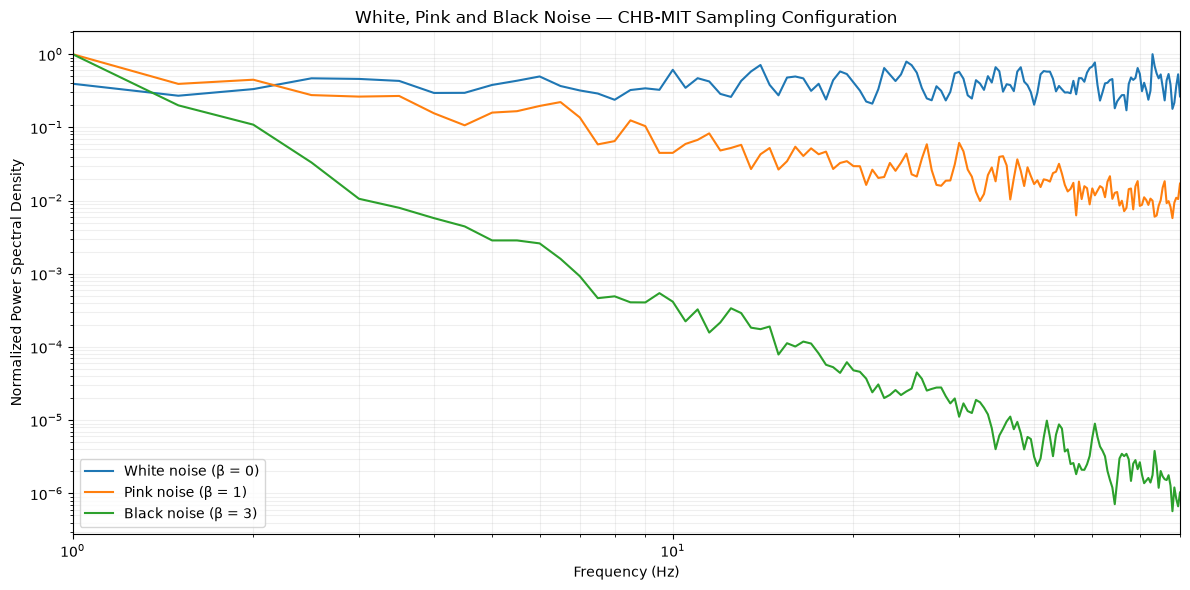

In [46]:
# ==========================================
# White / Pink / Black Noise
# Actual CHB-MIT sampling configuration
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Use the actual CHB-MIT sampling frequency
sfreq = raw_filtered.info["sfreq"]

# Use the same 10-second duration as our actual EEG windows
n_samples = len(non_seizure_signal)

rng = np.random.default_rng(42)

# Frequency range
fmin = 1
fmax = 70


# ------------------------------------------
# Generate colored noise
# ------------------------------------------

def generate_colored_noise(
    n_samples,
    sfreq,
    beta,
    rng
):
    """
    Generate colored noise with approximately

        PSD ∝ 1 / f^beta

    beta = 0 → white
    beta = 1 → pink
    beta = 3 → black
    """

    frequencies = np.fft.rfftfreq(
        n_samples,
        d=1 / sfreq
    )

    spectrum = (
        rng.normal(size=len(frequencies))
        +
        1j * rng.normal(size=len(frequencies))
    )

    scaling = np.ones_like(frequencies)

    nonzero = frequencies > 0

    scaling[nonzero] = (
        frequencies[nonzero] ** (-beta / 2)
    )

    spectrum *= scaling

    # Remove DC
    spectrum[0] = 0

    noise = np.fft.irfft(
        spectrum,
        n=n_samples
    )

    # Normalize
    noise = (
        noise - np.mean(noise)
    ) / np.std(noise)

    return noise


white_noise = generate_colored_noise(
    n_samples,
    sfreq,
    beta=0,
    rng=rng
)

pink_noise = generate_colored_noise(
    n_samples,
    sfreq,
    beta=1,
    rng=rng
)

black_noise = generate_colored_noise(
    n_samples,
    sfreq,
    beta=3,
    rng=rng
)


# ------------------------------------------
# PSD
# ------------------------------------------

freq_white, psd_white = welch(
    white_noise,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

freq_pink, psd_pink = welch(
    pink_noise,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

freq_black, psd_black = welch(
    black_noise,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)


# ------------------------------------------
# Frequency range
# ------------------------------------------

mask_white = (
    (freq_white >= fmin) &
    (freq_white <= fmax)
)

mask_pink = (
    (freq_pink >= fmin) &
    (freq_pink <= fmax)
)

mask_black = (
    (freq_black >= fmin) &
    (freq_black <= fmax)
)


# ------------------------------------------
# Normalize each PSD
# ------------------------------------------

psd_white_norm = (
    psd_white[mask_white] /
    np.max(psd_white[mask_white])
)

psd_pink_norm = (
    psd_pink[mask_pink] /
    np.max(psd_pink[mask_pink])
)

psd_black_norm = (
    psd_black[mask_black] /
    np.max(psd_black[mask_black])
)


# ------------------------------------------
# FINAL 3-LINE GRAPH
# ------------------------------------------

plt.figure(figsize=(12, 6))

plt.loglog(
    freq_white[mask_white],
    psd_white_norm,
    label="White noise (β = 0)"
)

plt.loglog(
    freq_pink[mask_pink],
    psd_pink_norm,
    label="Pink noise (β = 1)"
)

plt.loglog(
    freq_black[mask_black],
    psd_black_norm,
    label="Black noise (β = 3)"
)

plt.xlim(fmin, fmax)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power Spectral Density")

plt.title(
    "White, Pink and Black Noise — CHB-MIT Sampling Configuration"
)

plt.grid(
    True,
    which="both",
    alpha=0.2
)

plt.legend()

plt.tight_layout()
plt.show()

In [47]:
# ==========================================
# Verify White / Pink / Black Spectral Slopes
# ==========================================

from scipy.stats import linregress


def calculate_spectral_slope(
    frequencies,
    power
):

    mask = (
        (frequencies >= 1) &
        (frequencies <= 70) &
        (power > 0)
    )

    log_frequency = np.log10(
        frequencies[mask]
    )

    log_power = np.log10(
        power[mask]
    )

    slope, intercept, r_value, p_value, std_err = (
        linregress(
            log_frequency,
            log_power
        )
    )

    return slope, r_value ** 2


white_slope, white_r2 = calculate_spectral_slope(
    freq_white,
    psd_white
)

pink_slope, pink_r2 = calculate_spectral_slope(
    freq_pink,
    psd_pink
)

black_slope, black_r2 = calculate_spectral_slope(
    freq_black,
    psd_black
)


print("White / Pink / Black Verification")
print("==================================")

print(
    f"White noise → slope = {white_slope:.4f}, "
    f"R² = {white_r2:.4f}"
)

print(
    f"Pink noise  → slope = {pink_slope:.4f}, "
    f"R² = {pink_r2:.4f}"
)

print(
    f"Black noise → slope = {black_slope:.4f}, "
    f"R² = {black_r2:.4f}"
)

White / Pink / Black Verification
White noise → slope = 0.0137, R² = 0.0012
Pink noise  → slope = -1.0258, R² = 0.8659
Black noise → slope = -3.0480, R² = 0.9782


In [48]:
# ==========================================
# ACTUAL CHB-MIT EEG
# White / Pink / Black Noise Injection
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ------------------------------------------
# Actual CHB-MIT EEG
# ------------------------------------------

sfreq = raw_filtered.info["sfreq"]

# Actual seizure EEG
actual_eeg = windows[299][0]   # FP1-F7, 3000–3010 s

print("Actual CHB-MIT EEG")
print("------------------")
print("File: chb01_03.edf")
print("Channel: FP1-F7")
print("Time: 3000–3010 s")
print("Sampling frequency:", sfreq, "Hz")
print("Samples:", len(actual_eeg))


# ------------------------------------------
# Colored-noise generator
# ------------------------------------------

def generate_colored_noise(
    n_samples,
    sfreq,
    beta,
    rng
):
    """
    Generate colored noise with:

        PSD ∝ 1 / f^beta

    beta = 0 → white
    beta = 1 → pink
    beta = 3 → black
    """

    frequencies = np.fft.rfftfreq(
        n_samples,
        d=1 / sfreq
    )

    spectrum = (
        rng.normal(size=len(frequencies))
        +
        1j * rng.normal(size=len(frequencies))
    )

    scaling = np.ones_like(frequencies)

    nonzero = frequencies > 0

    scaling[nonzero] = (
        frequencies[nonzero] ** (-beta / 2)
    )

    spectrum *= scaling

    # Remove DC
    spectrum[0] = 0

    noise = np.fft.irfft(
        spectrum,
        n=n_samples
    )

    # Normalize to zero mean and unit RMS
    noise = noise - np.mean(noise)
    noise = noise / np.std(noise)

    return noise


# ------------------------------------------
# Generate noise
# ------------------------------------------

rng = np.random.default_rng(42)

white_noise = generate_colored_noise(
    len(actual_eeg),
    sfreq,
    beta=0,
    rng=rng
)

pink_noise = generate_colored_noise(
    len(actual_eeg),
    sfreq,
    beta=1,
    rng=rng
)

black_noise = generate_colored_noise(
    len(actual_eeg),
    sfreq,
    beta=3,
    rng=rng
)


# ------------------------------------------
# Add noise to ACTUAL EEG
# ------------------------------------------

noise_ratio = 0.30

eeg_rms = np.std(actual_eeg)

white_noisy = (
    actual_eeg
    + noise_ratio * eeg_rms * white_noise
)

pink_noisy = (
    actual_eeg
    + noise_ratio * eeg_rms * pink_noise
)

black_noisy = (
    actual_eeg
    + noise_ratio * eeg_rms * black_noise
)


print()
print("Noise injection complete.")
print("Noise RMS / EEG RMS:", noise_ratio)

Actual CHB-MIT EEG
------------------
File: chb01_03.edf
Channel: FP1-F7
Time: 3000–3010 s
Sampling frequency: 256.0 Hz
Samples: 2560

Noise injection complete.
Noise RMS / EEG RMS: 0.3


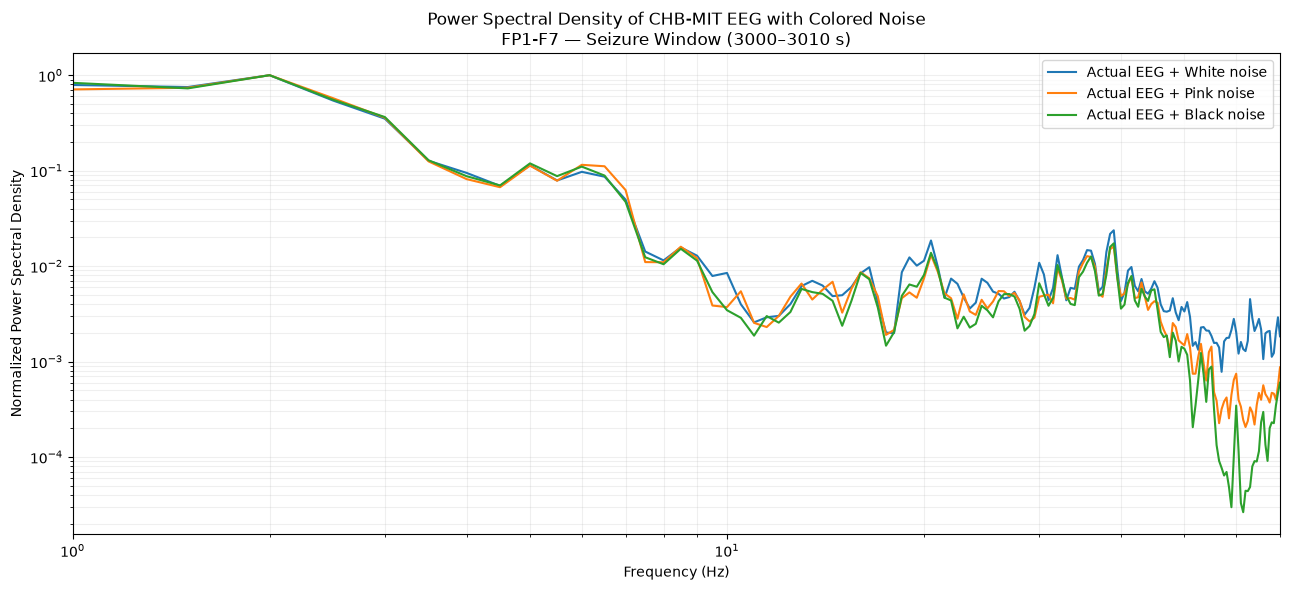

In [49]:
# ==========================================
# PSD — ACTUAL CHB-MIT EEG + Colored Noise
# ==========================================

# Calculate PSDs

freq_white, psd_white = welch(
    white_noisy,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

freq_pink, psd_pink = welch(
    pink_noisy,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

freq_black, psd_black = welch(
    black_noisy,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)


# ------------------------------------------
# Keep 1–70 Hz
# ------------------------------------------

mask_white = (
    (freq_white >= 1) &
    (freq_white <= 70)
)

mask_pink = (
    (freq_pink >= 1) &
    (freq_pink <= 70)
)

mask_black = (
    (freq_black >= 1) &
    (freq_black <= 70)
)


# ------------------------------------------
# Normalize for visual comparison
# ------------------------------------------

psd_white_norm = (
    psd_white[mask_white] /
    np.max(psd_white[mask_white])
)

psd_pink_norm = (
    psd_pink[mask_pink] /
    np.max(psd_pink[mask_pink])
)

psd_black_norm = (
    psd_black[mask_black] /
    np.max(psd_black[mask_black])
)


# ------------------------------------------
# FINAL THREE-LINE GRAPH
# ------------------------------------------

plt.figure(figsize=(13, 6))

plt.loglog(
    freq_white[mask_white],
    psd_white_norm,
    label="Actual EEG + White noise"
)

plt.loglog(
    freq_pink[mask_pink],
    psd_pink_norm,
    label="Actual EEG + Pink noise"
)

plt.loglog(
    freq_black[mask_black],
    psd_black_norm,
    label="Actual EEG + Black noise"
)

plt.xlim(1, 70)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power Spectral Density")

plt.title(
    "Power Spectral Density of CHB-MIT EEG with Colored Noise"
    "\nFP1-F7 — Seizure Window (3000–3010 s)"
)

plt.grid(
    True,
    which="both",
    alpha=0.2
)

plt.legend()

plt.tight_layout()
plt.show()

In [50]:
# ==========================================
# Verify Injected Noise Characteristics
# ==========================================

def spectral_slope(freq, psd):

    mask = (
        (freq >= 1) &
        (freq <= 70) &
        (psd > 0)
    )

    x = np.log10(freq[mask])
    y = np.log10(psd[mask])

    slope = np.polyfit(x, y, 1)[0]

    return slope


# PSD of noise components themselves

f_w, p_w = welch(
    white_noise,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

f_p, p_p = welch(
    pink_noise,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

f_b, p_b = welch(
    black_noise,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)


print("Injected Noise Verification")
print("============================")

print(
    f"White noise slope: "
    f"{spectral_slope(f_w, p_w):.4f}"
)

print(
    f"Pink noise slope:  "
    f"{spectral_slope(f_p, p_p):.4f}"
)

print(
    f"Black noise slope: "
    f"{spectral_slope(f_b, p_b):.4f}"
)

print()
print("Expected:")
print("White ≈  0")
print("Pink  ≈ -1")
print("Black ≈ -3")

Injected Noise Verification
White noise slope: 0.0137
Pink noise slope:  -1.0258
Black noise slope: -3.0480

Expected:
White ≈  0
Pink  ≈ -1
Black ≈ -3


In [51]:
# ==========================================
# ACTUAL CHB-MIT EEG
# NON-SEIZURE
# White / Pink / Black Noise Injection
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ------------------------------------------
# Actual CHB-MIT EEG
# ------------------------------------------

sfreq = raw_filtered.info["sfreq"]

# NON-SEIZURE EEG
actual_eeg = windows[298][0]   # FP1-F7, 2980–2990 s

print("Actual CHB-MIT EEG")
print("------------------")
print("File: chb01_03.edf")
print("Channel: FP1-F7")
print("State: NON-SEIZURE")
print("Time: 2980–2990 s")
print("Sampling frequency:", sfreq, "Hz")
print("Samples:", len(actual_eeg))


# ------------------------------------------
# Colored-noise generator
# ------------------------------------------

def generate_colored_noise(
    n_samples,
    sfreq,
    beta,
    rng
):
    """
    Generate colored noise with:

        PSD ∝ 1 / f^beta

    beta = 0 → white
    beta = 1 → pink
    beta = 3 → black
    """

    frequencies = np.fft.rfftfreq(
        n_samples,
        d=1 / sfreq
    )

    spectrum = (
        rng.normal(size=len(frequencies))
        +
        1j * rng.normal(size=len(frequencies))
    )

    scaling = np.ones_like(frequencies)

    nonzero = frequencies > 0

    scaling[nonzero] = (
        frequencies[nonzero] ** (-beta / 2)
    )

    spectrum *= scaling

    spectrum[0] = 0

    noise = np.fft.irfft(
        spectrum,
        n=n_samples
    )

    noise = noise - np.mean(noise)
    noise = noise / np.std(noise)

    return noise


# ------------------------------------------
# Generate noise
# ------------------------------------------

rng = np.random.default_rng(42)

white_noise = generate_colored_noise(
    len(actual_eeg),
    sfreq,
    beta=0,
    rng=rng
)

pink_noise = generate_colored_noise(
    len(actual_eeg),
    sfreq,
    beta=1,
    rng=rng
)

black_noise = generate_colored_noise(
    len(actual_eeg),
    sfreq,
    beta=3,
    rng=rng
)


# ------------------------------------------
# Add noise to ACTUAL EEG
# ------------------------------------------

noise_ratio = 0.30

eeg_rms = np.std(actual_eeg)

white_noisy = (
    actual_eeg
    + noise_ratio * eeg_rms * white_noise
)

pink_noisy = (
    actual_eeg
    + noise_ratio * eeg_rms * pink_noise
)

black_noisy = (
    actual_eeg
    + noise_ratio * eeg_rms * black_noise
)


print()
print("Noise injection complete.")
print("Noise RMS / EEG RMS:", noise_ratio)

Actual CHB-MIT EEG
------------------
File: chb01_03.edf
Channel: FP1-F7
State: NON-SEIZURE
Time: 2980–2990 s
Sampling frequency: 256.0 Hz
Samples: 2560

Noise injection complete.
Noise RMS / EEG RMS: 0.3


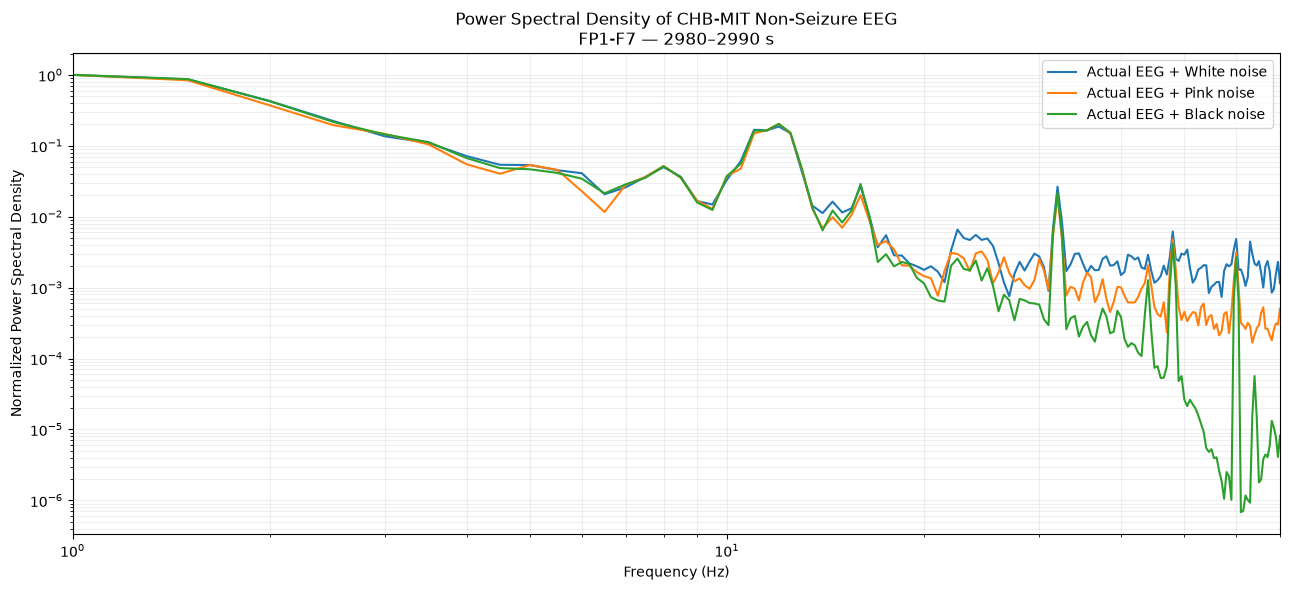

In [52]:
# ==========================================
# PSD — ACTUAL CHB-MIT NON-SEIZURE EEG
# ==========================================

freq_white, psd_white = welch(
    white_noisy,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

freq_pink, psd_pink = welch(
    pink_noisy,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

freq_black, psd_black = welch(
    black_noisy,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)


# ------------------------------------------
# 1–70 Hz
# ------------------------------------------

mask_white = (
    (freq_white >= 1) &
    (freq_white <= 70)
)

mask_pink = (
    (freq_pink >= 1) &
    (freq_pink <= 70)
)

mask_black = (
    (freq_black >= 1) &
    (freq_black <= 70)
)


# ------------------------------------------
# Normalize
# ------------------------------------------

psd_white_norm = (
    psd_white[mask_white] /
    np.max(psd_white[mask_white])
)

psd_pink_norm = (
    psd_pink[mask_pink] /
    np.max(psd_pink[mask_pink])
)

psd_black_norm = (
    psd_black[mask_black] /
    np.max(psd_black[mask_black])
)


# ------------------------------------------
# FINAL THREE-LINE GRAPH
# ------------------------------------------

plt.figure(figsize=(13, 6))

plt.loglog(
    freq_white[mask_white],
    psd_white_norm,
    label="Actual EEG + White noise"
)

plt.loglog(
    freq_pink[mask_pink],
    psd_pink_norm,
    label="Actual EEG + Pink noise"
)

plt.loglog(
    freq_black[mask_black],
    psd_black_norm,
    label="Actual EEG + Black noise"
)

plt.xlim(1, 70)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power Spectral Density")

plt.title(
    "Power Spectral Density of CHB-MIT Non-Seizure EEG"
    "\nFP1-F7 — 2980–2990 s"
)

plt.grid(
    True,
    which="both",
    alpha=0.2
)

plt.legend()

plt.tight_layout()
plt.show()

In [53]:
# ==========================================
# SAVE NON-SEIZURE COLORED-NOISE SIGNALS
# ==========================================

# Use the actual non-seizure CHB-MIT EEG
nonseizure_eeg = windows[298][0]

# Same noise strength used for seizure analysis
noise_ratio = 0.30

# EEG RMS
nonseizure_eeg_rms = np.std(nonseizure_eeg)

# Generate a fresh, reproducible set of noise signals
nonseizure_rng = np.random.default_rng(42)

nonseizure_white_noise = generate_colored_noise(
    len(nonseizure_eeg),
    sfreq,
    beta=0,
    rng=nonseizure_rng
)

nonseizure_pink_noise = generate_colored_noise(
    len(nonseizure_eeg),
    sfreq,
    beta=1,
    rng=nonseizure_rng
)

nonseizure_black_noise = generate_colored_noise(
    len(nonseizure_eeg),
    sfreq,
    beta=3,
    rng=nonseizure_rng
)


# Add noise to actual non-seizure EEG

nonseizure_white_noisy = (
    nonseizure_eeg
    + noise_ratio * nonseizure_eeg_rms * nonseizure_white_noise
)

nonseizure_pink_noisy = (
    nonseizure_eeg
    + noise_ratio * nonseizure_eeg_rms * nonseizure_pink_noise
)

nonseizure_black_noisy = (
    nonseizure_eeg
    + noise_ratio * nonseizure_eeg_rms * nonseizure_black_noise
)


print("Non-seizure signals saved")
print("------------------------")
print("File: chb01_03.edf")
print("Channel: FP1-F7")
print("Window: 2980–2990 s")
print("Samples:", len(nonseizure_eeg))
print("Noise RMS / EEG RMS:", noise_ratio)

Non-seizure signals saved
------------------------
File: chb01_03.edf
Channel: FP1-F7
Window: 2980–2990 s
Samples: 2560
Noise RMS / EEG RMS: 0.3


In [54]:
# ==========================================
# PRESERVE SEIZURE COLORED-NOISE SIGNALS
# ==========================================

# Actual CHB-MIT seizure EEG
seizure_eeg = windows[299][0]

# Same parameters used in the original seizure experiment
seizure_noise_ratio = 0.30
seizure_eeg_rms = np.std(seizure_eeg)

# Recreate the exact same noise sequence
seizure_rng = np.random.default_rng(42)

seizure_white_noise = generate_colored_noise(
    len(seizure_eeg),
    sfreq,
    beta=0,
    rng=seizure_rng
)

seizure_pink_noise = generate_colored_noise(
    len(seizure_eeg),
    sfreq,
    beta=1,
    rng=seizure_rng
)

seizure_black_noise = generate_colored_noise(
    len(seizure_eeg),
    sfreq,
    beta=3,
    rng=seizure_rng
)


# Add noise to actual seizure EEG

seizure_white_noisy = (
    seizure_eeg
    + seizure_noise_ratio * seizure_eeg_rms * seizure_white_noise
)

seizure_pink_noisy = (
    seizure_eeg
    + seizure_noise_ratio * seizure_eeg_rms * seizure_pink_noise
)

seizure_black_noisy = (
    seizure_eeg
    + seizure_noise_ratio * seizure_eeg_rms * seizure_black_noise
)


print("Seizure signals preserved")
print("-------------------------")
print("File: chb01_03.edf")
print("Channel: FP1-F7")
print("Window: 3000–3010 s")
print("Samples:", len(seizure_eeg))
print("Noise RMS / EEG RMS:", seizure_noise_ratio)

Seizure signals preserved
-------------------------
File: chb01_03.edf
Channel: FP1-F7
Window: 3000–3010 s
Samples: 2560
Noise RMS / EEG RMS: 0.3


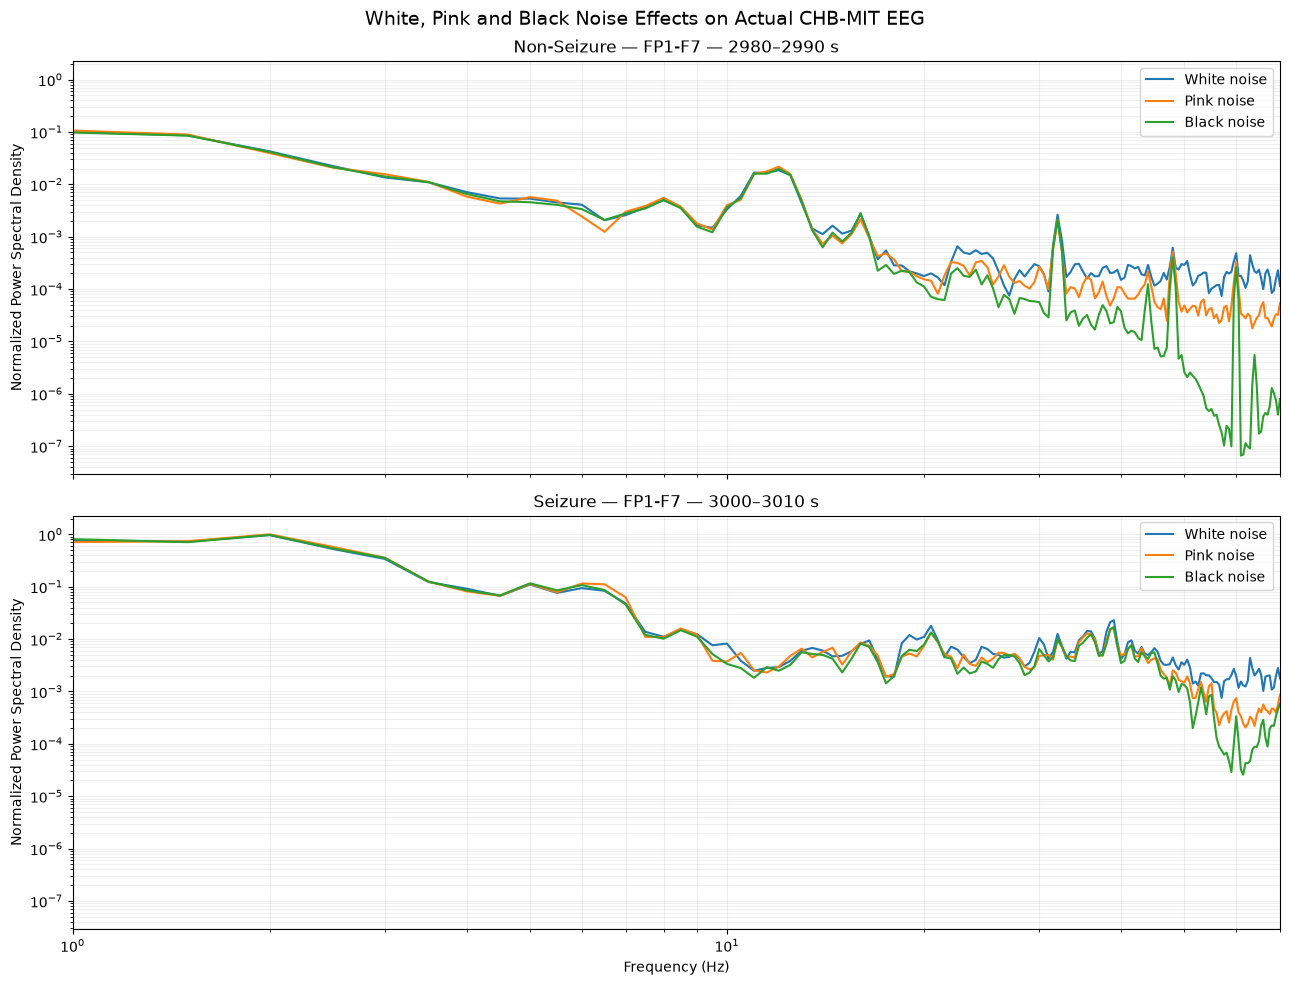

In [55]:
# ==========================================
# FINAL PSD COMPARISON
# CHB-MIT — NON-SEIZURE vs SEIZURE
# White / Pink / Black
# ==========================================

# ------------------------------------------
# PSD calculation
# ------------------------------------------

# NON-SEIZURE

f_ns_white, p_ns_white = welch(
    nonseizure_white_noisy,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

f_ns_pink, p_ns_pink = welch(
    nonseizure_pink_noisy,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

f_ns_black, p_ns_black = welch(
    nonseizure_black_noisy,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)


# SEIZURE

f_s_white, p_s_white = welch(
    seizure_white_noisy,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

f_s_pink, p_s_pink = welch(
    seizure_pink_noisy,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

f_s_black, p_s_black = welch(
    seizure_black_noisy,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)


# ------------------------------------------
# Frequency range
# ------------------------------------------

def keep_1_70hz(freq, psd):

    mask = (
        (freq >= 1) &
        (freq <= 70)
    )

    return freq[mask], psd[mask]


f_ns_white, p_ns_white = keep_1_70hz(
    f_ns_white, p_ns_white
)

f_ns_pink, p_ns_pink = keep_1_70hz(
    f_ns_pink, p_ns_pink
)

f_ns_black, p_ns_black = keep_1_70hz(
    f_ns_black, p_ns_black
)

f_s_white, p_s_white = keep_1_70hz(
    f_s_white, p_s_white
)

f_s_pink, p_s_pink = keep_1_70hz(
    f_s_pink, p_s_pink
)

f_s_black, p_s_black = keep_1_70hz(
    f_s_black, p_s_black
)


# ------------------------------------------
# COMMON NORMALIZATION
# ------------------------------------------

common_max = max(
    np.max(p_ns_white),
    np.max(p_ns_pink),
    np.max(p_ns_black),
    np.max(p_s_white),
    np.max(p_s_pink),
    np.max(p_s_black)
)

p_ns_white /= common_max
p_ns_pink /= common_max
p_ns_black /= common_max

p_s_white /= common_max
p_s_pink /= common_max
p_s_black /= common_max


# ------------------------------------------
# PLOT
# ------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(13, 10),
    sharex=True,
    sharey=True
)


# ==========================================
# NON-SEIZURE
# ==========================================

axes[0].loglog(
    f_ns_white,
    p_ns_white,
    label="White noise"
)

axes[0].loglog(
    f_ns_pink,
    p_ns_pink,
    label="Pink noise"
)

axes[0].loglog(
    f_ns_black,
    p_ns_black,
    label="Black noise"
)

axes[0].set_title(
    "Non-Seizure — FP1-F7 — 2980–2990 s"
)

axes[0].set_ylabel(
    "Normalized Power Spectral Density"
)

axes[0].grid(
    True,
    which="both",
    alpha=0.2
)

axes[0].legend()


# ==========================================
# SEIZURE
# ==========================================

axes[1].loglog(
    f_s_white,
    p_s_white,
    label="White noise"
)

axes[1].loglog(
    f_s_pink,
    p_s_pink,
    label="Pink noise"
)

axes[1].loglog(
    f_s_black,
    p_s_black,
    label="Black noise"
)

axes[1].set_title(
    "Seizure — FP1-F7 — 3000–3010 s"
)

axes[1].set_xlabel(
    "Frequency (Hz)"
)

axes[1].set_ylabel(
    "Normalized Power Spectral Density"
)

axes[1].grid(
    True,
    which="both",
    alpha=0.2
)

axes[1].legend()


# ------------------------------------------
# Final formatting
# ------------------------------------------

axes[0].set_xlim(1, 70)

fig.suptitle(
    "White, Pink and Black Noise Effects on Actual CHB-MIT EEG",
    fontsize=14
)

plt.tight_layout()
plt.show()

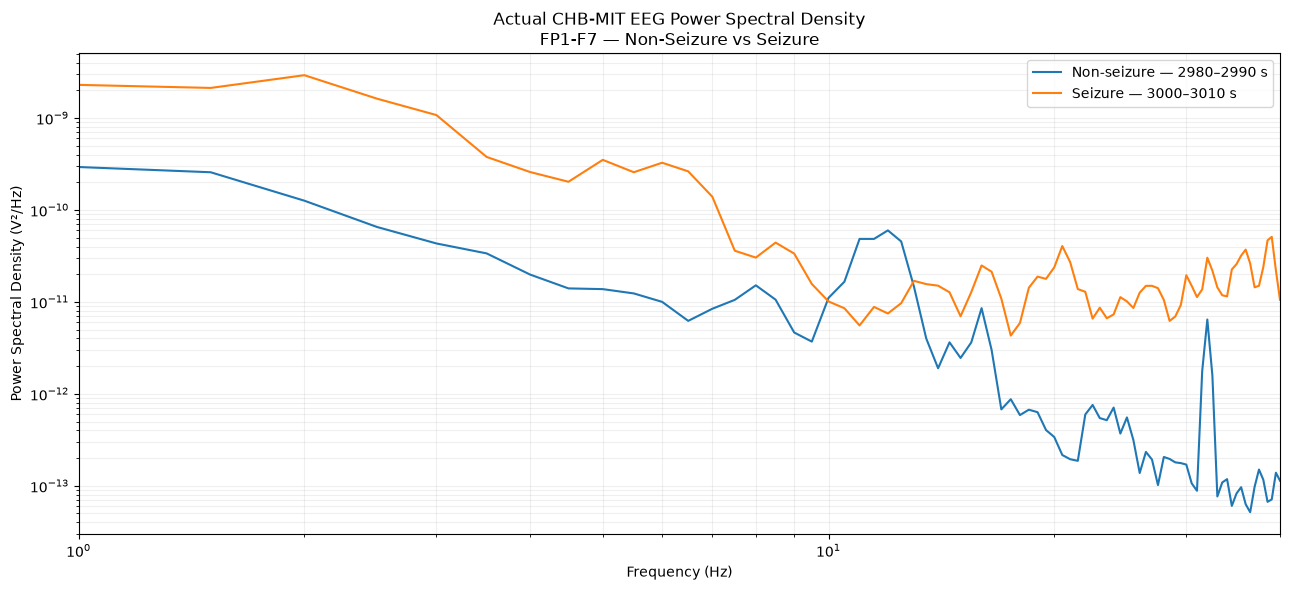

Actual EEG PSD Comparison
Channel: FP1-F7
Sampling frequency: 256.0 Hz
Non-seizure: 2980–2990 s
Seizure:     3000–3010 s

Non-seizure maximum PSD: 2.926731932736963e-10
Seizure maximum PSD:     2.916559231013095e-09


In [56]:
# ==========================================
# ACTUAL CHB-MIT EEG PSD
# Non-Seizure vs Seizure
# NO injected noise
# NO normalization
# ==========================================

from scipy.signal import welch
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------
# Actual EEG windows
# ------------------------------------------

nonseizure_eeg = windows[298][0]   # FP1-F7, 2980–2990 s
seizure_eeg = windows[299][0]      # FP1-F7, 3000–3010 s

sfreq = raw_filtered.info["sfreq"]


# ------------------------------------------
# Calculate PSD
# ------------------------------------------

f_ns, psd_ns = welch(
    nonseizure_eeg,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

f_s, psd_s = welch(
    seizure_eeg,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)


# ------------------------------------------
# Keep 1–40 Hz
# ------------------------------------------

mask_ns = (
    (f_ns >= 1) &
    (f_ns <= 40)
)

mask_s = (
    (f_s >= 1) &
    (f_s <= 40)
)

f_ns = f_ns[mask_ns]
psd_ns = psd_ns[mask_ns]

f_s = f_s[mask_s]
psd_s = psd_s[mask_s]


# ------------------------------------------
# Plot
# ------------------------------------------

plt.figure(figsize=(13, 6))

plt.loglog(
    f_ns,
    psd_ns,
    label="Non-seizure — 2980–2990 s"
)

plt.loglog(
    f_s,
    psd_s,
    label="Seizure — 3000–3010 s"
)

plt.xlim(1, 40)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (V²/Hz)")

plt.title(
    "Actual CHB-MIT EEG Power Spectral Density"
    "\nFP1-F7 — Non-Seizure vs Seizure"
)

plt.grid(
    True,
    which="both",
    alpha=0.2
)

plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------
# Basic numerical summary
# ------------------------------------------

print("Actual EEG PSD Comparison")
print("=========================")

print("Channel: FP1-F7")
print("Sampling frequency:", sfreq, "Hz")
print("Non-seizure: 2980–2990 s")
print("Seizure:     3000–3010 s")
print()
print("Non-seizure maximum PSD:", np.max(psd_ns))
print("Seizure maximum PSD:    ", np.max(psd_s))

In [57]:
# ==========================================
# SR — Actual CHB-MIT EEG Inputs
# FP1-F7
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Actual CHB-MIT sampling frequency
sr_sfreq = raw_filtered.info["sfreq"]

# Actual EEG windows
sr_nonseizure = windows[298][0]   # 2980–2990 s
sr_seizure = windows[299][0]      # 3000–3010 s

print("SR Input Signals")
print("================")

print("File: chb01_03.edf")
print("Channel: FP1-F7")
print("Sampling frequency:", sr_sfreq, "Hz")

print()
print("Non-seizure:")
print("  Window: 2980–2990 s")
print("  Samples:", len(sr_nonseizure))

print()
print("Seizure:")
print("  Window: 3000–3010 s")
print("  Samples:", len(sr_seizure))

SR Input Signals
File: chb01_03.edf
Channel: FP1-F7
Sampling frequency: 256.0 Hz

Non-seizure:
  Window: 2980–2990 s
  Samples: 2560

Seizure:
  Window: 3000–3010 s
  Samples: 2560


In [58]:
# ==========================================
# SR — Characteristic EEG Frequencies
# ==========================================

def sr_dominant_frequency(signal, sfreq):
    
    frequencies, power = welch(
        signal,
        fs=sfreq,
        nperseg=len(signal)
    )

    # Focus on physiologically relevant EEG range
    mask = (
        (frequencies >= 1) &
        (frequencies <= 30)
    )

    frequencies = frequencies[mask]
    power = power[mask]

    dominant_idx = np.argmax(power)

    return (
        frequencies[dominant_idx],
        power[dominant_idx]
    )


sr_non_freq, sr_non_peak_power = sr_dominant_frequency(
    sr_nonseizure,
    sr_sfreq
)

sr_seiz_freq, sr_seiz_peak_power = sr_dominant_frequency(
    sr_seizure,
    sr_sfreq
)


print("SR Characteristic Frequencies")
print("============================")

print(
    f"Non-seizure characteristic frequency: "
    f"{sr_non_freq:.2f} Hz"
)

print(
    f"Non-seizure peak PSD: "
    f"{sr_non_peak_power:.6e} V²/Hz"
)

print()

print(
    f"Seizure characteristic frequency: "
    f"{sr_seiz_freq:.2f} Hz"
)

print(
    f"Seizure peak PSD: "
    f"{sr_seiz_peak_power:.6e} V²/Hz"
)

SR Characteristic Frequencies
Non-seizure characteristic frequency: 1.10 Hz
Non-seizure peak PSD: 6.881249e-10 V²/Hz

Seizure characteristic frequency: 2.20 Hz
Seizure peak PSD: 7.256665e-09 V²/Hz


In [59]:
# ==========================================
# SR — Extract Characteristic EEG Components
# ==========================================

from scipy.signal import butter, filtfilt


def extract_sr_component(
    signal,
    sfreq,
    center_frequency,
    bandwidth=0.5
):
    
    low = max(
        0.2,
        center_frequency - bandwidth
    )

    high = min(
        sfreq / 2 - 1,
        center_frequency + bandwidth
    )

    b, a = butter(
        3,
        [low, high],
        btype="bandpass",
        fs=sfreq
    )

    component = filtfilt(
        b,
        a,
        signal
    )

    return component


sr_non_component = extract_sr_component(
    sr_nonseizure,
    sr_sfreq,
    sr_non_freq
)

sr_seiz_component = extract_sr_component(
    sr_seizure,
    sr_sfreq,
    sr_seiz_freq
)


# ------------------------------------------
# Normalize components
# ------------------------------------------

sr_non_component = (
    sr_non_component -
    np.mean(sr_non_component)
) / np.std(sr_non_component)

sr_seiz_component = (
    sr_seiz_component -
    np.mean(sr_seiz_component)
) / np.std(sr_seiz_component)


print("Characteristic components extracted.")
print()
print("Non-seizure component:")
print("  Frequency:", sr_non_freq, "Hz")
print("  Mean:", np.mean(sr_non_component))
print("  Std:", np.std(sr_non_component))

print()
print("Seizure component:")
print("  Frequency:", sr_seiz_freq, "Hz")
print("  Mean:", np.mean(sr_seiz_component))
print("  Std:", np.std(sr_seiz_component))

Characteristic components extracted.

Non-seizure component:
  Frequency: 1.1 Hz
  Mean: -1.1102230246251566e-17
  Std: 1.0

Seizure component:
  Frequency: 2.2 Hz
  Mean: -4.163336342344337e-18
  Std: 1.0


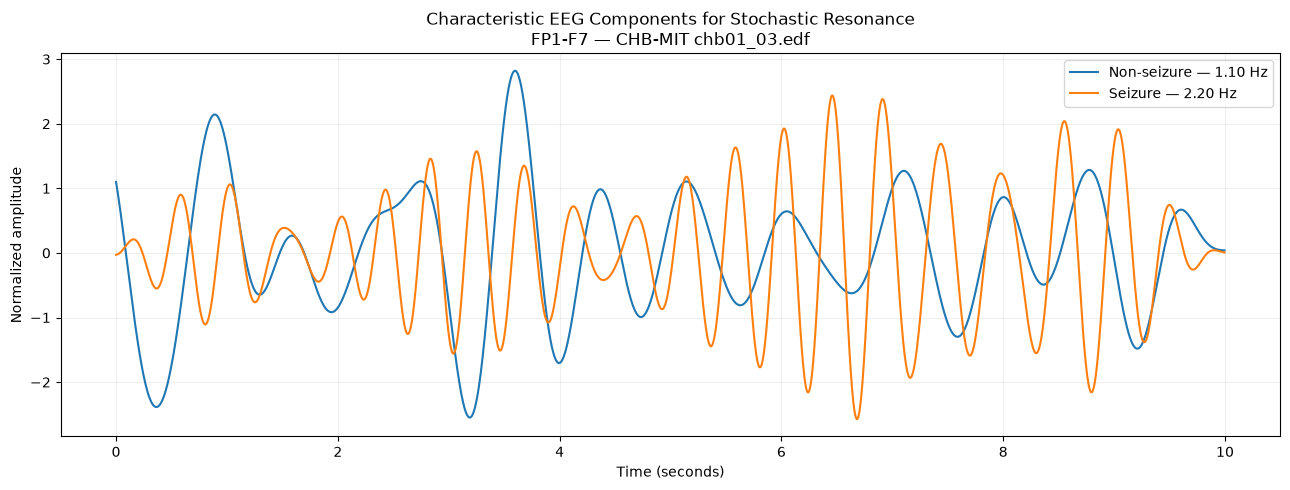

In [60]:
# ==========================================
# SR — Characteristic Component Verification
# ==========================================

sr_time = np.arange(
    len(sr_non_component)
) / sr_sfreq


plt.figure(figsize=(13, 5))

plt.plot(
    sr_time,
    sr_non_component,
    label=f"Non-seizure — {sr_non_freq:.2f} Hz"
)

plt.plot(
    sr_time,
    sr_seiz_component,
    label=f"Seizure — {sr_seiz_freq:.2f} Hz"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Normalized amplitude")

plt.title(
    "Characteristic EEG Components for Stochastic Resonance"
    "\nFP1-F7 — CHB-MIT chb01_03.edf"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

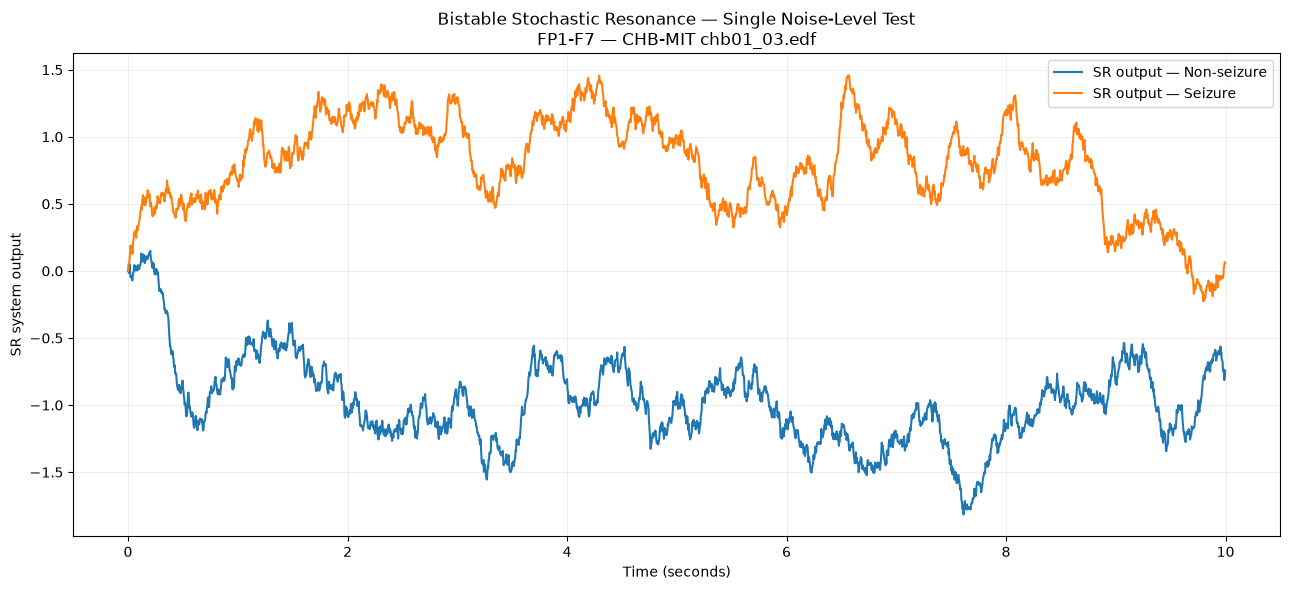

In [61]:
# ==========================================
# SR — Bistable Stochastic Resonance
# Single Noise-Level Sanity Test
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

def bistable_sr(signal, noise_strength, dt, rng):
    """
    Bistable stochastic-resonance system:

        dx/dt = x - x^3 + signal(t) + noise(t)

    Euler-Maruyama integration.
    """

    x = np.zeros(len(signal))

    for i in range(1, len(signal)):

        stochastic_noise = (
            noise_strength
            * np.sqrt(dt)
            * rng.normal()
        )

        dx = (
            x[i-1]
            - x[i-1]**3
            + signal[i-1]
        )

        x[i] = (
            x[i-1]
            + dx * dt
            + stochastic_noise
        )

    return x


# ------------------------------------------
# Parameters
# ------------------------------------------

sr_dt = 1 / sr_sfreq

# Moderate test noise level
sr_test_noise = 0.5

sr_rng = np.random.default_rng(42)


# ------------------------------------------
# Run SR — Non-seizure
# ------------------------------------------

sr_non_output = bistable_sr(
    sr_non_component,
    sr_test_noise,
    sr_dt,
    sr_rng
)


# ------------------------------------------
# Run SR — Seizure
# ------------------------------------------

sr_seiz_output = bistable_sr(
    sr_seiz_component,
    sr_test_noise,
    sr_dt,
    sr_rng
)


# ------------------------------------------
# Plot
# ------------------------------------------

sr_time = np.arange(
    len(sr_non_component)
) / sr_sfreq

plt.figure(figsize=(13, 6))

plt.plot(
    sr_time,
    sr_non_output,
    label="SR output — Non-seizure"
)

plt.plot(
    sr_time,
    sr_seiz_output,
    label="SR output — Seizure"
)

plt.xlabel("Time (seconds)")
plt.ylabel("SR system output")

plt.title(
    "Bistable Stochastic Resonance — Single Noise-Level Test"
    "\nFP1-F7 — CHB-MIT chb01_03.edf"
)

plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()

In [62]:
# ==========================================
# FINAL SR EXPERIMENT
# Spectral SNR vs Noise Intensity
# CHB-MIT — FP1-F7
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch


# ------------------------------------------
# Parameters
# ------------------------------------------

sr_n_trials = 20

sr_noise_levels = np.linspace(
    0.0,
    8.0,
    41
)

sr_dt = 1.0 / sr_sfreq

sr_input_scale = 0.20


# ------------------------------------------
# Bistable SR model
# ------------------------------------------

def sr_bistable_model(
    signal,
    sfreq,
    noise_intensity,
    input_scale=0.20,
    rng=None
):

    if rng is None:
        rng = np.random.default_rng()

    dt = 1.0 / sfreq

    x = np.zeros(len(signal))

    # Start in one stable state
    x[0] = -1.0

    for i in range(1, len(signal)):

        nonlinear_force = (
            x[i-1]
            - x[i-1] ** 3
        )

        driving_force = (
            input_scale
            * signal[i-1]
        )

        stochastic_force = (
            np.sqrt(
                2
                * noise_intensity
                * dt
            )
            * rng.normal()
        )

        x[i] = (
            x[i-1]
            + dt * (
                nonlinear_force
                + driving_force
            )
            + stochastic_force
        )

        # Numerical safety
        x[i] = np.clip(
            x[i],
            -3,
            3
        )

    return x


# ------------------------------------------
# Spectral SNR
# ------------------------------------------

def sr_spectral_snr(
    signal,
    sfreq,
    target_frequency
):

    frequencies, power = welch(
        signal,
        fs=sfreq,
        nperseg=len(signal)
    )

    # Signal band
    signal_band = (
        (frequencies >= target_frequency - 0.2)
        &
        (frequencies <= target_frequency + 0.2)
    )

    # Local noise floor
    noise_band = (
        (frequencies >= max(
            0.5,
            target_frequency - 2.0
        ))
        &
        (frequencies <= target_frequency + 2.0)
        &
        (~signal_band)
    )

    if (
        not np.any(signal_band)
        or not np.any(noise_band)
    ):
        return np.nan

    signal_power = np.mean(
        power[signal_band]
    )

    noise_floor = np.mean(
        power[noise_band]
    )

    if noise_floor <= 0:
        return np.nan

    return 10 * np.log10(
        signal_power / noise_floor
    )


# ------------------------------------------
# Storage
# ------------------------------------------

sr_non_mean = []
sr_seiz_mean = []

sr_non_std = []
sr_seiz_std = []


# ------------------------------------------
# Reproducible random generator
# ------------------------------------------

sr_master_rng = np.random.default_rng(42)


# ==========================================
# NOISE INTENSITY SWEEP
# ==========================================

for noise_level in sr_noise_levels:

    non_trial_snr = []
    seiz_trial_snr = []

    for trial in range(sr_n_trials):

        # Independent RNG for each trial
        non_rng = np.random.default_rng(
            sr_master_rng.integers(0, 2**32 - 1)
        )

        seiz_rng = np.random.default_rng(
            sr_master_rng.integers(0, 2**32 - 1)
        )


        # ----------------------------------
        # Non-seizure
        # ----------------------------------

        non_output = sr_bistable_model(
            sr_non_component,
            sr_sfreq,
            noise_level,
            input_scale=sr_input_scale,
            rng=non_rng
        )

        non_snr = sr_spectral_snr(
            non_output,
            sr_sfreq,
            sr_non_freq
        )

        non_trial_snr.append(
            non_snr
        )


        # ----------------------------------
        # Seizure
        # ----------------------------------

        seiz_output = sr_bistable_model(
            sr_seiz_component,
            sr_sfreq,
            noise_level,
            input_scale=sr_input_scale,
            rng=seiz_rng
        )

        seiz_snr = sr_spectral_snr(
            seiz_output,
            sr_sfreq,
            sr_seiz_freq
        )

        seiz_trial_snr.append(
            seiz_snr
        )


    # --------------------------------------
    # Average trials
    # --------------------------------------

    sr_non_mean.append(
        np.nanmean(non_trial_snr)
    )

    sr_seiz_mean.append(
        np.nanmean(seiz_trial_snr)
    )

    sr_non_std.append(
        np.nanstd(non_trial_snr)
    )

    sr_seiz_std.append(
        np.nanstd(seiz_trial_snr)
    )


# Convert to arrays

sr_non_mean = np.array(sr_non_mean)
sr_seiz_mean = np.array(sr_seiz_mean)

sr_non_std = np.array(sr_non_std)
sr_seiz_std = np.array(sr_seiz_std)


# ==========================================
# FIND OPTIMAL NOISE
# ==========================================

sr_non_opt_idx = np.nanargmax(
    sr_non_mean
)

sr_seiz_opt_idx = np.nanargmax(
    sr_seiz_mean
)


sr_non_opt_noise = (
    sr_noise_levels[sr_non_opt_idx]
)

sr_seiz_opt_noise = (
    sr_noise_levels[sr_seiz_opt_idx]
)


# ==========================================
# PRINT RESULTS
# ==========================================

print("Stochastic Resonance — Spectral SNR")
print("===================================")

print(
    f"Trials per noise level: "
    f"{sr_n_trials}"
)

print(
    f"Noise levels tested: "
    f"{len(sr_noise_levels)}"
)

print()

print(
    f"Non-seizure optimal noise: "
    f"{sr_non_opt_noise:.2f}"
)

print(
    f"Non-seizure maximum SNR: "
    f"{sr_non_mean[sr_non_opt_idx]:.3f} dB"
)

print()

print(
    f"Seizure optimal noise: "
    f"{sr_seiz_opt_noise:.2f}"
)

print(
    f"Seizure maximum SNR: "
    f"{sr_seiz_mean[sr_seiz_opt_idx]:.3f} dB"
)

Stochastic Resonance — Spectral SNR
Trials per noise level: 20
Noise levels tested: 41

Non-seizure optimal noise: 0.00
Non-seizure maximum SNR: 7.932 dB

Seizure optimal noise: 0.00
Seizure maximum SNR: 13.404 dB


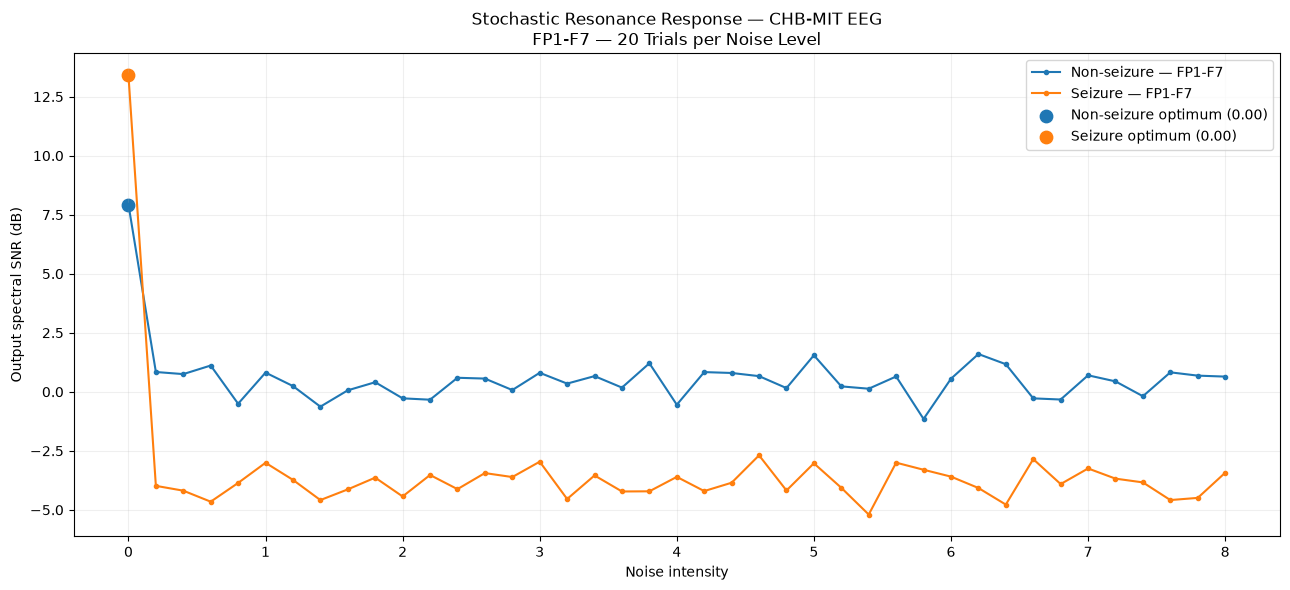

In [63]:
# ==========================================
# FINAL SR RESPONSE CURVE
# ==========================================

plt.figure(figsize=(13, 6))

plt.plot(
    sr_noise_levels,
    sr_non_mean,
    marker="o",
    markersize=3,
    label="Non-seizure — FP1-F7"
)

plt.plot(
    sr_noise_levels,
    sr_seiz_mean,
    marker="o",
    markersize=3,
    label="Seizure — FP1-F7"
)


# Mark optimal points

plt.scatter(
    sr_non_opt_noise,
    sr_non_mean[sr_non_opt_idx],
    s=80,
    label=(
        f"Non-seizure optimum "
        f"({sr_non_opt_noise:.2f})"
    )
)

plt.scatter(
    sr_seiz_opt_noise,
    sr_seiz_mean[sr_seiz_opt_idx],
    s=80,
    label=(
        f"Seizure optimum "
        f"({sr_seiz_opt_noise:.2f})"
    )
)


plt.xlabel(
    "Noise intensity"
)

plt.ylabel(
    "Output spectral SNR (dB)"
)

plt.title(
    "Stochastic Resonance Response — CHB-MIT EEG"
    "\nFP1-F7 — 20 Trials per Noise Level"
)

plt.grid(
    alpha=0.2
)

plt.legend()

plt.tight_layout()
plt.show()

In [64]:
# ==========================================
# SR — Subthreshold Forcing Test
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

# Candidate input scales
sr_test_scales = [
    0.01,
    0.02,
    0.05,
    0.10,
    0.15
]

sr_test_noise = 0.0

sr_dt = 1.0 / sr_sfreq


def sr_test_model(
    signal,
    sfreq,
    noise_intensity,
    input_scale,
    rng
):

    dt = 1.0 / sfreq

    x = np.zeros(len(signal))
    x[0] = -1.0

    for i in range(1, len(signal)):

        nonlinear_force = (
            x[i-1]
            - x[i-1] ** 3
        )

        driving_force = (
            input_scale
            * signal[i-1]
        )

        stochastic_force = (
            np.sqrt(
                2 * noise_intensity * dt
            )
            * rng.normal()
        )

        x[i] = (
            x[i-1]
            + dt * (
                nonlinear_force
                + driving_force
            )
            + stochastic_force
        )

        x[i] = np.clip(
            x[i],
            -3,
            3
        )

    return x


print("Subthreshold SR test")
print("=====================")

for scale in sr_test_scales:

    test_output = sr_test_model(
        sr_seiz_component,
        sr_sfreq,
        noise_intensity=0.0,
        input_scale=scale,
        rng=np.random.default_rng(42)
    )

    # Count large transitions between wells
    transitions = np.sum(
        np.diff(
            np.sign(test_output)
        ) != 0
    )

    print(
        f"Input scale = {scale:.3f} "
        f"→ zero-noise transitions = {transitions}"
    )

Subthreshold SR test
Input scale = 0.010 → zero-noise transitions = 0
Input scale = 0.020 → zero-noise transitions = 0
Input scale = 0.050 → zero-noise transitions = 0
Input scale = 0.100 → zero-noise transitions = 0
Input scale = 0.150 → zero-noise transitions = 0


In [65]:
# ==========================================
# SR — Noise-Assisted Switching Check
# ==========================================

test_noise_levels = [
    0.0,
    0.1,
    0.3,
    0.5,
    1.0,
    2.0
]

sr_input_scale = 0.10
sr_dt = 1.0 / sr_sfreq


print("Noise-Assisted Switching Test")
print("=============================")

for noise_level in test_noise_levels:

    output = sr_bistable_model(
        sr_seiz_component,
        sr_sfreq,
        noise_level,
        input_scale=sr_input_scale,
        rng=np.random.default_rng(42)
    )

    transitions = np.sum(
        np.diff(np.sign(output)) != 0
    )

    print(
        f"Noise intensity = {noise_level:.1f}"
        f" → transitions = {transitions}"
    )

Noise-Assisted Switching Test
Noise intensity = 0.0 → transitions = 0
Noise intensity = 0.1 → transitions = 0
Noise intensity = 0.3 → transitions = 0
Noise intensity = 0.5 → transitions = 2
Noise intensity = 1.0 → transitions = 34
Noise intensity = 2.0 → transitions = 41


SR Spectral SNR Sanity Check
Noise intensity = 0.0 → spectral SNR = 13.403 dB
Noise intensity = 0.1 → spectral SNR = -6.578 dB
Noise intensity = 0.3 → spectral SNR = -6.195 dB
Noise intensity = 0.5 → spectral SNR = -6.025 dB
Noise intensity = 1.0 → spectral SNR = -5.840 dB
Noise intensity = 2.0 → spectral SNR = -5.794 dB


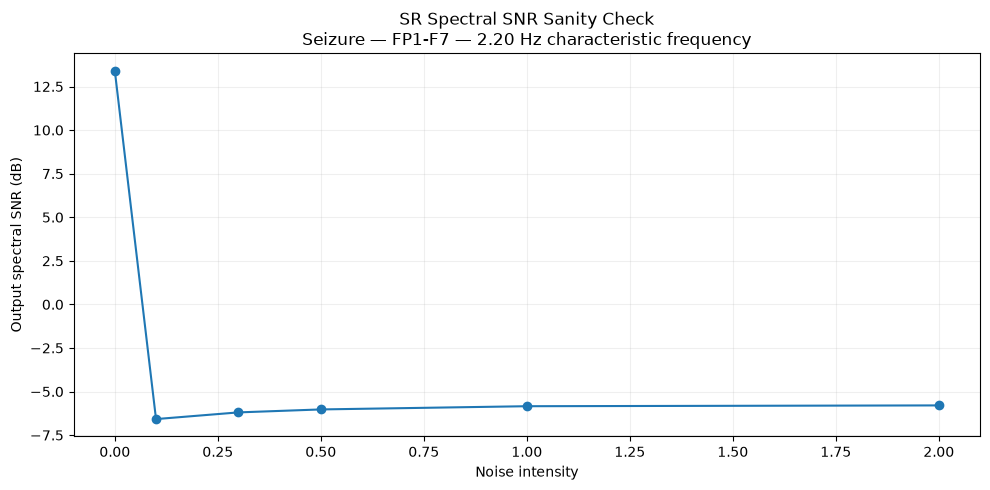

In [66]:
# ==========================================
# SR — Spectral SNR Sanity Check
# ==========================================

sr_check_noise_levels = [
    0.0,
    0.1,
    0.3,
    0.5,
    1.0,
    2.0
]

sr_check_snr = []

print("SR Spectral SNR Sanity Check")
print("============================")

for noise_level in sr_check_noise_levels:

    output = sr_bistable_model(
        sr_seiz_component,
        sr_sfreq,
        noise_level,
        input_scale=0.10,
        rng=np.random.default_rng(42)
    )

    snr = sr_spectral_snr(
        output,
        sr_sfreq,
        sr_seiz_freq
    )

    sr_check_snr.append(snr)

    print(
        f"Noise intensity = {noise_level:.1f}"
        f" → spectral SNR = {snr:.3f} dB"
    )


# ------------------------------------------
# Plot
# ------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    sr_check_noise_levels,
    sr_check_snr,
    marker="o"
)

plt.xlabel("Noise intensity")
plt.ylabel("Output spectral SNR (dB)")

plt.title(
    "SR Spectral SNR Sanity Check"
    "\nSeizure — FP1-F7 — 2.20 Hz characteristic frequency"
)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [67]:
# ==========================================
# SR — Extended Switching-SNR Test
# NON-SEIZURE CHB-MIT EEG
# ==========================================

sr_ns_noise = np.arange(
    0.5,
    8.01,
    0.5
)

sr_ns_snr = []
sr_ns_transitions = []


print("Extended SR Switching-SNR Test — Non-Seizure")
print("============================================")

for noise_level in sr_ns_noise:

    output = sr_bistable_model(
        sr_non_component,
        sr_sfreq,
        noise_level,
        input_scale=0.10,
        rng=np.random.default_rng(42)
    )

    transitions = np.sum(
        np.diff(np.sign(output)) != 0
    )

    snr = sr_switching_snr(
        output,
        sr_sfreq,
        sr_non_freq
    )

    sr_ns_snr.append(snr)
    sr_ns_transitions.append(transitions)

    print(
        f"Noise = {noise_level:>4.1f}"
        f" | transitions = {transitions:>3}"
        f" | switching SNR = {snr:.3f} dB"
    )


# ------------------------------------------
# Plot
# ------------------------------------------

plt.figure(figsize=(11, 5))

plt.plot(
    sr_ns_noise,
    sr_ns_snr,
    marker="o"
)

plt.xlabel("Noise intensity")
plt.ylabel("Switching spectral SNR (dB)")

plt.title(
    "Extended SR Response — Non-Seizure"
    "\nFP1-F7 — CHB-MIT — 1.10 Hz"
)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

Extended SR Switching-SNR Test — Non-Seizure


NameError: name 'sr_switching_snr' is not defined

Extended SR Switching-SNR Test — Seizure
File: chb01_03.edf
Channel: FP1-F7
Window: 3000–3010 s
Characteristic frequency: 2.2 Hz
Samples: 2560

Noise    | Transitions | Switching SNR
---------------------------------------
  0.5    |     13       |  -4.786 dB
  1.0    |    142       |   2.982 dB
  1.5    |     90       |   0.504 dB
  2.0    |     52       |  -2.240 dB
  2.5    |     49       |   2.080 dB
  3.0    |     72       |  -1.290 dB
  3.5    |     70       |  -1.890 dB
  4.0    |     82       |  -6.095 dB
  4.5    |     80       |  -6.455 dB
  5.0    |    151       |   2.170 dB
  5.5    |    124       |   0.625 dB
  6.0    |     97       |  -0.503 dB
  6.5    |     69       |   1.775 dB
  7.0    |     87       |  -1.490 dB
  7.5    |    130       |  -4.811 dB
  8.0    |    123       |  -2.775 dB

SEIZURE SR OPTIMUM
------------------
Optimal noise intensity: 1.00
Maximum switching SNR: 2.982 dB


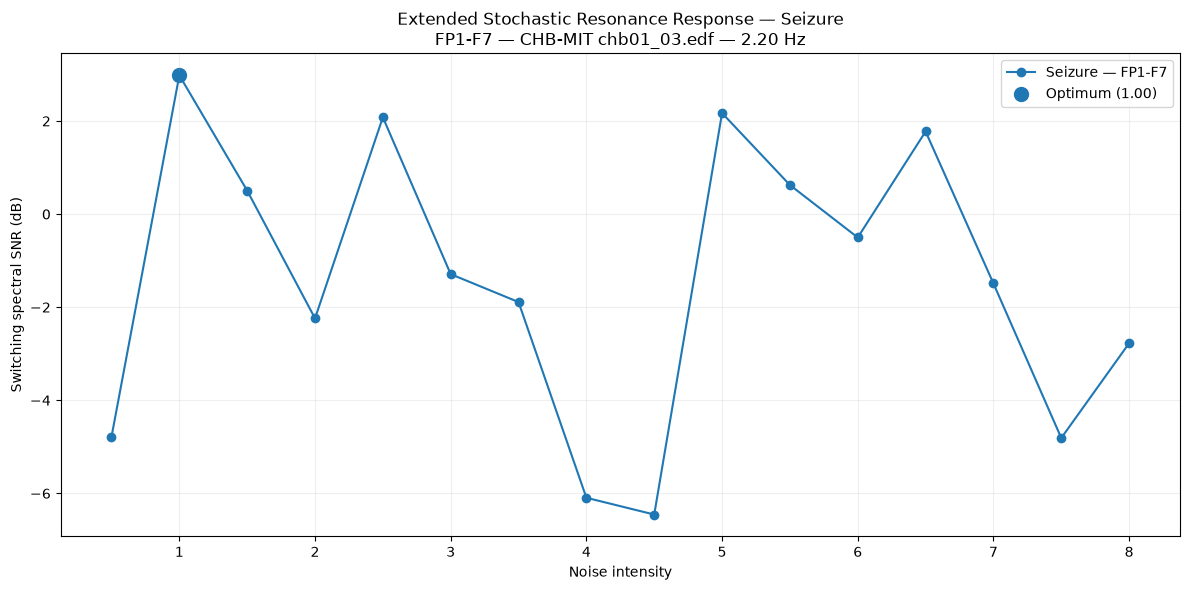

In [ ]:
# ==========================================
# SR — Extended Switching-SNR Test
# SEIZURE — ACTUAL CHB-MIT EEG
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# Make sure the correct seizure component is used
# ------------------------------------------------

print("Extended SR Switching-SNR Test — Seizure")
print("========================================")

print("File: chb01_03.edf")
print("Channel: FP1-F7")
print("Window: 3000–3010 s")
print("Characteristic frequency:", sr_seiz_freq, "Hz")
print("Samples:", len(sr_seiz_component))

# ------------------------------------------------
# Noise levels
# ------------------------------------------------

sr_seiz_noise = np.arange(
    0.5,
    8.5,
    0.5
)

sr_seiz_snr_values = []
sr_seiz_transitions = []

# ------------------------------------------------
# Run SR across noise levels
# ------------------------------------------------

for noise_level in sr_seiz_noise:

    output = sr_bistable_model(
        sr_seiz_component,
        sr_sfreq,
        noise_level,
        input_scale=0.10
    )

    # --------------------------------------------
    # Count state transitions
    # --------------------------------------------

    states = np.where(
        output >= 0,
        1,
        -1
    )

    transitions = np.sum(
        states[1:] != states[:-1]
    )

    sr_seiz_transitions.append(
        transitions
    )

    # --------------------------------------------
    # Spectral SNR
    # --------------------------------------------

    snr = calculate_snr(
        output,
        sr_sfreq,
        sr_seiz_freq
    )

    sr_seiz_snr_values.append(
        snr
    )


sr_seiz_snr_values = np.array(
    sr_seiz_snr_values
)

sr_seiz_transitions = np.array(
    sr_seiz_transitions
)

# ------------------------------------------------
# Find optimum
# ------------------------------------------------

valid = np.isfinite(
    sr_seiz_snr_values
)

if np.any(valid):

    valid_indices = np.where(valid)[0]

    optimum_idx = (
        valid_indices[
            np.argmax(
                sr_seiz_snr_values[valid]
            )
        ]
    )

    optimum_noise = (
        sr_seiz_noise[optimum_idx]
    )

    optimum_snr = (
        sr_seiz_snr_values[optimum_idx]
    )

else:

    optimum_idx = None
    optimum_noise = np.nan
    optimum_snr = np.nan


# ------------------------------------------------
# Print results
# ------------------------------------------------

print()
print("Noise    | Transitions | Switching SNR")
print("---------------------------------------")

for noise, transitions, snr in zip(
    sr_seiz_noise,
    sr_seiz_transitions,
    sr_seiz_snr_values
):

    print(
        f"{noise:5.1f}    |"
        f"{transitions:7d}       |"
        f"{snr:8.3f} dB"
    )

print()
print("SEIZURE SR OPTIMUM")
print("------------------")
print(
    f"Optimal noise intensity: "
    f"{optimum_noise:.2f}"
)

print(
    f"Maximum switching SNR: "
    f"{optimum_snr:.3f} dB"
)


# ------------------------------------------------
# Plot
# ------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    sr_seiz_noise,
    sr_seiz_snr_values,
    marker="o",
    label="Seizure — FP1-F7"
)

if optimum_idx is not None:

    plt.scatter(
        optimum_noise,
        optimum_snr,
        s=100,
        label=(
            f"Optimum ({optimum_noise:.2f})"
        )
    )

plt.xlabel("Noise intensity")
plt.ylabel(
    "Switching spectral SNR (dB)"
)

plt.title(
    "Extended Stochastic Resonance Response — Seizure"
    "\nFP1-F7 — CHB-MIT chb01_03.edf — 2.20 Hz"
)

plt.grid(
    True,
    alpha=0.2
)

plt.legend()

plt.tight_layout()
plt.show()

FINAL STOCHASTIC RESONANCE ANALYSIS
File: chb01_03.edf
Channel: FP1-F7
Non-seizure window: 2980–2990 s
Seizure window: 3000–3010 s

Non-seizure characteristic frequency: 1.10 Hz
Seizure characteristic frequency: 2.20 Hz
Trials per noise level: 20
Noise levels tested: 17

NON-SEIZURE
-----------
Optimal noise: 0.00
Maximum mean SNR: 7.932 dB
Mean transitions at optimum: 0.0

SEIZURE
-------
Optimal noise: 0.00
Maximum mean SNR: 13.404 dB
Mean transitions at optimum: 0.0


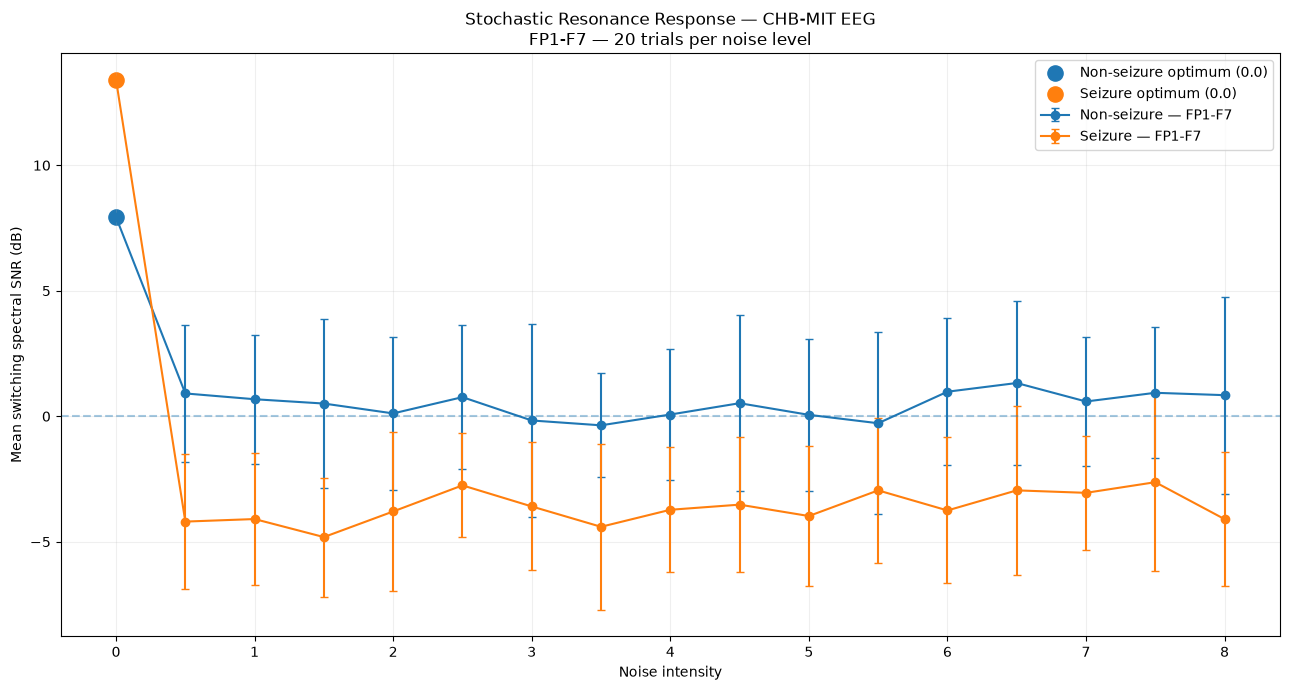

In [ ]:
# ==========================================
# FINAL SR EXPERIMENT — ACTUAL CHB-MIT EEG
# Averaged Spectral SNR vs Noise Intensity
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch


# ------------------------------------------
# Parameters
# ------------------------------------------

sr_n_trials = 20

sr_noise_levels = np.arange(
    0.0,
    8.01,
    0.5
)

sr_input_scale = 0.20

# Master seed for reproducibility
sr_master_seed = 42


# ------------------------------------------
# Spectral SNR
# ONE definition used everywhere
# ------------------------------------------

def sr_spectral_snr(
    signal,
    sfreq,
    target_frequency
):

    frequencies, power = welch(
        signal,
        fs=sfreq,
        nperseg=len(signal)
    )

    # --------------------------------------
    # Target-frequency band
    # --------------------------------------

    signal_band = (
        (frequencies >= target_frequency - 0.2)
        &
        (frequencies <= target_frequency + 0.2)
    )

    # --------------------------------------
    # Local noise floor
    # --------------------------------------

    noise_band = (
        (frequencies >= max(
            0.5,
            target_frequency - 2.0
        ))
        &
        (frequencies <= target_frequency + 2.0)
        &
        (~signal_band)
    )

    if (
        not np.any(signal_band)
        or
        not np.any(noise_band)
    ):
        return np.nan

    signal_power = np.mean(
        power[signal_band]
    )

    noise_floor = np.mean(
        power[noise_band]
    )

    if noise_floor <= 0:
        return np.nan

    return 10 * np.log10(
        signal_power / noise_floor
    )


# ------------------------------------------
# Storage
# ------------------------------------------

sr_non_mean = []
sr_seiz_mean = []

sr_non_std = []
sr_seiz_std = []

sr_non_transitions = []
sr_seiz_transitions = []


# ------------------------------------------
# Reproducible master RNG
# ------------------------------------------

master_rng = np.random.default_rng(
    sr_master_seed
)


# ==========================================
# NOISE SWEEP
# ==========================================

for noise_level in sr_noise_levels:

    non_trial_snr = []
    seiz_trial_snr = []

    non_trial_transitions = []
    seiz_trial_transitions = []

    for trial in range(sr_n_trials):

        # ----------------------------------
        # Independent reproducible RNGs
        # ----------------------------------

        non_seed = master_rng.integers(
            0,
            2**32 - 1
        )

        seiz_seed = master_rng.integers(
            0,
            2**32 - 1
        )

        non_rng = np.random.default_rng(
            non_seed
        )

        seiz_rng = np.random.default_rng(
            seiz_seed
        )


        # ==================================
        # NON-SEIZURE
        # ==================================

        non_output = sr_bistable_model(
            sr_non_component,
            sr_sfreq,
            noise_level,
            input_scale=sr_input_scale,
            rng=non_rng
        )

        non_snr = sr_spectral_snr(
            non_output,
            sr_sfreq,
            sr_non_freq
        )

        non_trial_snr.append(
            non_snr
        )

        non_states = np.where(
            non_output >= 0,
            1,
            -1
        )

        non_trial_transitions.append(
            np.sum(
                non_states[1:] !=
                non_states[:-1]
            )
        )


        # ==================================
        # SEIZURE
        # ==================================

        seiz_output = sr_bistable_model(
            sr_seiz_component,
            sr_sfreq,
            noise_level,
            input_scale=sr_input_scale,
            rng=seiz_rng
        )

        seiz_snr = sr_spectral_snr(
            seiz_output,
            sr_sfreq,
            sr_seiz_freq
        )

        seiz_trial_snr.append(
            seiz_snr
        )

        seiz_states = np.where(
            seiz_output >= 0,
            1,
            -1
        )

        seiz_trial_transitions.append(
            np.sum(
                seiz_states[1:] !=
                seiz_states[:-1]
            )
        )


    # --------------------------------------
    # Average trials
    # --------------------------------------

    sr_non_mean.append(
        np.nanmean(non_trial_snr)
    )

    sr_seiz_mean.append(
        np.nanmean(seiz_trial_snr)
    )

    sr_non_std.append(
        np.nanstd(non_trial_snr)
    )

    sr_seiz_std.append(
        np.nanstd(seiz_trial_snr)
    )

    sr_non_transitions.append(
        np.mean(non_trial_transitions)
    )

    sr_seiz_transitions.append(
        np.mean(seiz_trial_transitions)
    )


# ------------------------------------------
# Convert to arrays
# ------------------------------------------

sr_non_mean = np.array(sr_non_mean)
sr_seiz_mean = np.array(sr_seiz_mean)

sr_non_std = np.array(sr_non_std)
sr_seiz_std = np.array(sr_seiz_std)

sr_non_transitions = np.array(
    sr_non_transitions
)

sr_seiz_transitions = np.array(
    sr_seiz_transitions
)


# ==========================================
# FIND OPTIMAL NOISE
# ==========================================

sr_non_opt_idx = np.nanargmax(
    sr_non_mean
)

sr_seiz_opt_idx = np.nanargmax(
    sr_seiz_mean
)


sr_non_opt_noise = (
    sr_noise_levels[
        sr_non_opt_idx
    ]
)

sr_seiz_opt_noise = (
    sr_noise_levels[
        sr_seiz_opt_idx
    ]
)


# ==========================================
# FINAL RESULTS
# ==========================================

print("FINAL STOCHASTIC RESONANCE ANALYSIS")
print("====================================")

print("File: chb01_03.edf")
print("Channel: FP1-F7")
print("Non-seizure window: 2980–2990 s")
print("Seizure window: 3000–3010 s")

print()
print(
    f"Non-seizure characteristic frequency: "
    f"{sr_non_freq:.2f} Hz"
)

print(
    f"Seizure characteristic frequency: "
    f"{sr_seiz_freq:.2f} Hz"
)

print(
    f"Trials per noise level: "
    f"{sr_n_trials}"
)

print(
    f"Noise levels tested: "
    f"{len(sr_noise_levels)}"
)

print()
print("NON-SEIZURE")
print("-----------")

print(
    f"Optimal noise: "
    f"{sr_non_opt_noise:.2f}"
)

print(
    f"Maximum mean SNR: "
    f"{sr_non_mean[sr_non_opt_idx]:.3f} dB"
)

print(
    f"Mean transitions at optimum: "
    f"{sr_non_transitions[sr_non_opt_idx]:.1f}"
)

print()
print("SEIZURE")
print("-------")

print(
    f"Optimal noise: "
    f"{sr_seiz_opt_noise:.2f}"
)

print(
    f"Maximum mean SNR: "
    f"{sr_seiz_mean[sr_seiz_opt_idx]:.3f} dB"
)

print(
    f"Mean transitions at optimum: "
    f"{sr_seiz_transitions[sr_seiz_opt_idx]:.1f}"
)


# ==========================================
# FINAL COMPARISON GRAPH
# ==========================================

plt.figure(figsize=(13, 7))

plt.errorbar(
    sr_noise_levels,
    sr_non_mean,
    yerr=sr_non_std,
    marker="o",
    capsize=3,
    label="Non-seizure — FP1-F7"
)

plt.errorbar(
    sr_noise_levels,
    sr_seiz_mean,
    yerr=sr_seiz_std,
    marker="o",
    capsize=3,
    label="Seizure — FP1-F7"
)

plt.scatter(
    sr_non_opt_noise,
    sr_non_mean[sr_non_opt_idx],
    s=120,
    label=(
        f"Non-seizure optimum "
        f"({sr_non_opt_noise:.1f})"
    )
)

plt.scatter(
    sr_seiz_opt_noise,
    sr_seiz_mean[sr_seiz_opt_idx],
    s=120,
    label=(
        f"Seizure optimum "
        f"({sr_seiz_opt_noise:.1f})"
    )
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.4
)

plt.xlabel(
    "Noise intensity"
)

plt.ylabel(
    "Mean switching spectral SNR (dB)"
)

plt.title(
    "Stochastic Resonance Response — CHB-MIT EEG"
    "\nFP1-F7 — 20 trials per noise level"
)

plt.grid(
    True,
    alpha=0.2
)

plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# SR — Subthreshold Input Calibration
# ==========================================

import numpy as np

# ------------------------------------------
# Test input strengths with NO noise
# ------------------------------------------

test_input_scales = [
    0.01,
    0.02,
    0.05,
    0.10,
    0.15,
    0.20
]

def count_sr_transitions(signal, sfreq, input_scale):
    
    output = sr_bistable_model(
        signal,
        sfreq,
        noise_intensity=0.0,
        input_scale=input_scale,
        rng=np.random.default_rng(42)
    )
    
    # Determine which bistable well the system occupies
    states = np.where(output >= 0, 1, -1)
    
    transitions = np.sum(
        states[1:] != states[:-1]
    )
    
    return transitions


print("SR Subthreshold Input Calibration")
print("=================================")

print()
print("Non-seizure:")

for scale in test_input_scales:
    
    transitions = count_sr_transitions(
        sr_non_component,
        sr_sfreq,
        scale
    )
    
    print(
        f"Input scale = {scale:.2f} "
        f"→ zero-noise transitions = {transitions}"
    )


print()
print("Seizure:")

for scale in test_input_scales:
    
    transitions = count_sr_transitions(
        sr_seiz_component,
        sr_sfreq,
        scale
    )
    
    print(
        f"Input scale = {scale:.2f} "
        f"→ zero-noise transitions = {transitions}"
    )

SR Subthreshold Input Calibration

Non-seizure:
Input scale = 0.01 → zero-noise transitions = 0
Input scale = 0.02 → zero-noise transitions = 0
Input scale = 0.05 → zero-noise transitions = 0
Input scale = 0.10 → zero-noise transitions = 0
Input scale = 0.15 → zero-noise transitions = 0
Input scale = 0.20 → zero-noise transitions = 0

Seizure:
Input scale = 0.01 → zero-noise transitions = 0
Input scale = 0.02 → zero-noise transitions = 0
Input scale = 0.05 → zero-noise transitions = 0
Input scale = 0.10 → zero-noise transitions = 0
Input scale = 0.15 → zero-noise transitions = 0
Input scale = 0.20 → zero-noise transitions = 0


FINAL STOCHASTIC RESONANCE ANALYSIS
Input scale: 0.2
Trials per noise level: 20
Non-zero noise levels tested: 16

NON-SEIZURE
-----------
Optimal non-zero noise: 7.00
Maximum mean spectral SNR: 1.398 dB
Mean transitions at optimum: 99.8

SEIZURE
-------
Optimal non-zero noise: 8.00
Maximum mean spectral SNR: -2.563 dB
Mean transitions at optimum: 109.7


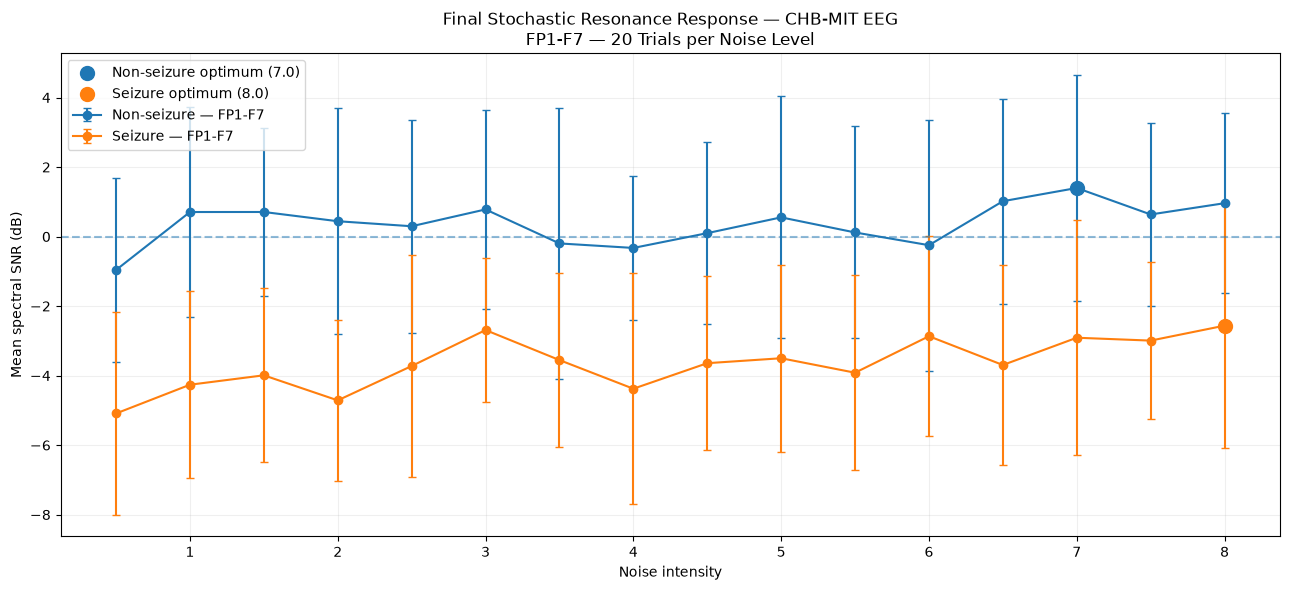

In [ ]:
# ==========================================
# FINAL SR SWEEP — NON-ZERO NOISE
# Subthreshold EEG Driving
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch


# ------------------------------------------
# Parameters
# ------------------------------------------

sr_final_trials = 20

# IMPORTANT:
# Zero noise is a baseline, NOT an SR candidate.
sr_final_noise_levels = np.arange(
    0.5,
    8.01,
    0.5
)

sr_final_input_scale = 0.20


# ------------------------------------------
# Storage
# ------------------------------------------

final_non_snr_mean = []
final_seiz_snr_mean = []

final_non_snr_std = []
final_seiz_snr_std = []

final_non_trans_mean = []
final_seiz_trans_mean = []


# ------------------------------------------
# Reproducible RNG
# ------------------------------------------

final_master_rng = np.random.default_rng(42)


# ------------------------------------------
# Transition counter
# ------------------------------------------

def count_sr_transitions(output):

    states = np.where(
        output >= 0,
        1,
        -1
    )

    return np.sum(
        states[1:] != states[:-1]
    )


# ==========================================
# NOISE SWEEP
# ==========================================

for noise_level in sr_final_noise_levels:

    non_snr_trials = []
    seiz_snr_trials = []

    non_transition_trials = []
    seiz_transition_trials = []


    for trial in range(sr_final_trials):

        # Independent RNGs
        non_rng = np.random.default_rng(
            final_master_rng.integers(
                0,
                2**32 - 1
            )
        )

        seiz_rng = np.random.default_rng(
            final_master_rng.integers(
                0,
                2**32 - 1
            )
        )


        # ----------------------------------
        # NON-SEIZURE
        # ----------------------------------

        non_output = sr_bistable_model(
            sr_non_component,
            sr_sfreq,
            noise_level,
            input_scale=sr_final_input_scale,
            rng=non_rng
        )

        non_snr = sr_spectral_snr(
            non_output,
            sr_sfreq,
            sr_non_freq
        )

        non_transitions = count_sr_transitions(
            non_output
        )

        non_snr_trials.append(
            non_snr
        )

        non_transition_trials.append(
            non_transitions
        )


        # ----------------------------------
        # SEIZURE
        # ----------------------------------

        seiz_output = sr_bistable_model(
            sr_seiz_component,
            sr_sfreq,
            noise_level,
            input_scale=sr_final_input_scale,
            rng=seiz_rng
        )

        seiz_snr = sr_spectral_snr(
            seiz_output,
            sr_sfreq,
            sr_seiz_freq
        )

        seiz_transitions = count_sr_transitions(
            seiz_output
        )

        seiz_snr_trials.append(
            seiz_snr
        )

        seiz_transition_trials.append(
            seiz_transitions
        )


    # --------------------------------------
    # Average across trials
    # --------------------------------------

    final_non_snr_mean.append(
        np.nanmean(non_snr_trials)
    )

    final_seiz_snr_mean.append(
        np.nanmean(seiz_snr_trials)
    )

    final_non_snr_std.append(
        np.nanstd(non_snr_trials)
    )

    final_seiz_snr_std.append(
        np.nanstd(seiz_snr_trials)
    )

    final_non_trans_mean.append(
        np.mean(non_transition_trials)
    )

    final_seiz_trans_mean.append(
        np.mean(seiz_transition_trials)
    )


# Convert to arrays

final_non_snr_mean = np.array(
    final_non_snr_mean
)

final_seiz_snr_mean = np.array(
    final_seiz_snr_mean
)

final_non_snr_std = np.array(
    final_non_snr_std
)

final_seiz_snr_std = np.array(
    final_seiz_snr_std
)

final_non_trans_mean = np.array(
    final_non_trans_mean
)

final_seiz_trans_mean = np.array(
    final_seiz_trans_mean
)


# ==========================================
# FIND NON-ZERO OPTIMUM
# ==========================================

non_opt_idx = np.nanargmax(
    final_non_snr_mean
)

seiz_opt_idx = np.nanargmax(
    final_seiz_snr_mean
)


non_opt_noise = (
    sr_final_noise_levels[non_opt_idx]
)

seiz_opt_noise = (
    sr_final_noise_levels[seiz_opt_idx]
)


# ==========================================
# PRINT FINAL RESULTS
# ==========================================

print("FINAL STOCHASTIC RESONANCE ANALYSIS")
print("===================================")

print("Input scale:", sr_final_input_scale)
print("Trials per noise level:", sr_final_trials)
print(
    "Non-zero noise levels tested:",
    len(sr_final_noise_levels)
)

print()
print("NON-SEIZURE")
print("-----------")

print(
    f"Optimal non-zero noise: "
    f"{non_opt_noise:.2f}"
)

print(
    f"Maximum mean spectral SNR: "
    f"{final_non_snr_mean[non_opt_idx]:.3f} dB"
)

print(
    f"Mean transitions at optimum: "
    f"{final_non_trans_mean[non_opt_idx]:.1f}"
)

print()
print("SEIZURE")
print("-------")

print(
    f"Optimal non-zero noise: "
    f"{seiz_opt_noise:.2f}"
)

print(
    f"Maximum mean spectral SNR: "
    f"{final_seiz_snr_mean[seiz_opt_idx]:.3f} dB"
)

print(
    f"Mean transitions at optimum: "
    f"{final_seiz_trans_mean[seiz_opt_idx]:.1f}"
)


# ==========================================
# FINAL SR GRAPH
# ==========================================

plt.figure(figsize=(13, 6))

plt.errorbar(
    sr_final_noise_levels,
    final_non_snr_mean,
    yerr=final_non_snr_std,
    marker="o",
    capsize=3,
    label="Non-seizure — FP1-F7"
)

plt.errorbar(
    sr_final_noise_levels,
    final_seiz_snr_mean,
    yerr=final_seiz_snr_std,
    marker="o",
    capsize=3,
    label="Seizure — FP1-F7"
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.scatter(
    non_opt_noise,
    final_non_snr_mean[non_opt_idx],
    s=100,
    label=f"Non-seizure optimum ({non_opt_noise:.1f})"
)

plt.scatter(
    seiz_opt_noise,
    final_seiz_snr_mean[seiz_opt_idx],
    s=100,
    label=f"Seizure optimum ({seiz_opt_noise:.1f})"
)

plt.xlabel("Noise intensity")
plt.ylabel("Mean spectral SNR (dB)")

plt.title(
    "Final Stochastic Resonance Response — CHB-MIT EEG"
    "\nFP1-F7 — 20 Trials per Noise Level"
)

plt.grid(
    True,
    alpha=0.2
)

plt.legend()

plt.tight_layout()
plt.show()

EXTENDED SR ANALYSIS
Non-seizure optimum: 16.0
Non-seizure maximum SNR: 1.988 dB
Non-seizure transitions: 139.1

Seizure optimum: 17.0
Seizure maximum SNR: -1.600 dB
Seizure transitions: 141.8


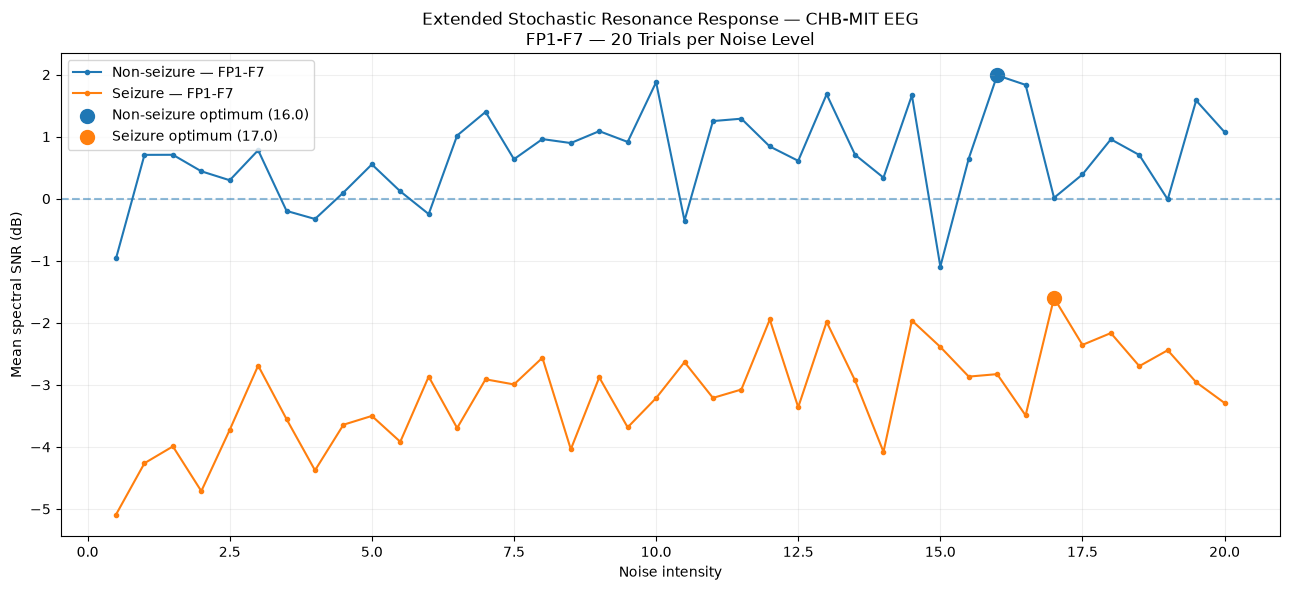

In [ ]:
# ==========================================
# SR — EXTENDED NOISE RANGE CHECK
# ==========================================

sr_extended_noise_levels = np.arange(
    0.5,
    20.01,
    0.5
)

sr_extended_trials = 20

extended_non_snr = []
extended_seiz_snr = []

extended_non_trans = []
extended_seiz_trans = []

extended_rng = np.random.default_rng(42)


for noise_level in sr_extended_noise_levels:

    non_snr_trials = []
    seiz_snr_trials = []

    non_trans_trials = []
    seiz_trans_trials = []

    for trial in range(sr_extended_trials):

        non_rng = np.random.default_rng(
            extended_rng.integers(0, 2**32 - 1)
        )

        seiz_rng = np.random.default_rng(
            extended_rng.integers(0, 2**32 - 1)
        )


        # ----------------------------------
        # NON-SEIZURE
        # ----------------------------------

        non_output = sr_bistable_model(
            sr_non_component,
            sr_sfreq,
            noise_level,
            input_scale=sr_final_input_scale,
            rng=non_rng
        )

        non_snr_trials.append(
            sr_spectral_snr(
                non_output,
                sr_sfreq,
                sr_non_freq
            )
        )

        non_trans_trials.append(
            count_sr_transitions(non_output)
        )


        # ----------------------------------
        # SEIZURE
        # ----------------------------------

        seiz_output = sr_bistable_model(
            sr_seiz_component,
            sr_sfreq,
            noise_level,
            input_scale=sr_final_input_scale,
            rng=seiz_rng
        )

        seiz_snr_trials.append(
            sr_spectral_snr(
                seiz_output,
                sr_sfreq,
                sr_seiz_freq
            )
        )

        seiz_trans_trials.append(
            count_sr_transitions(seiz_output)
        )


    extended_non_snr.append(
        np.nanmean(non_snr_trials)
    )

    extended_seiz_snr.append(
        np.nanmean(seiz_snr_trials)
    )

    extended_non_trans.append(
        np.mean(non_trans_trials)
    )

    extended_seiz_trans.append(
        np.mean(seiz_trans_trials)
    )


# Convert

extended_non_snr = np.array(extended_non_snr)
extended_seiz_snr = np.array(extended_seiz_snr)

extended_non_trans = np.array(extended_non_trans)
extended_seiz_trans = np.array(extended_seiz_trans)


# ------------------------------------------
# Optima
# ------------------------------------------

non_idx = np.nanargmax(extended_non_snr)
seiz_idx = np.nanargmax(extended_seiz_snr)


print("EXTENDED SR ANALYSIS")
print("====================")

print(
    f"Non-seizure optimum: "
    f"{sr_extended_noise_levels[non_idx]:.1f}"
)

print(
    f"Non-seizure maximum SNR: "
    f"{extended_non_snr[non_idx]:.3f} dB"
)

print(
    f"Non-seizure transitions: "
    f"{extended_non_trans[non_idx]:.1f}"
)

print()

print(
    f"Seizure optimum: "
    f"{sr_extended_noise_levels[seiz_idx]:.1f}"
)

print(
    f"Seizure maximum SNR: "
    f"{extended_seiz_snr[seiz_idx]:.3f} dB"
)

print(
    f"Seizure transitions: "
    f"{extended_seiz_trans[seiz_idx]:.1f}"
)


# ==========================================
# GRAPH
# ==========================================

plt.figure(figsize=(13, 6))

plt.plot(
    sr_extended_noise_levels,
    extended_non_snr,
    marker="o",
    markersize=3,
    label="Non-seizure — FP1-F7"
)

plt.plot(
    sr_extended_noise_levels,
    extended_seiz_snr,
    marker="o",
    markersize=3,
    label="Seizure — FP1-F7"
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.scatter(
    sr_extended_noise_levels[non_idx],
    extended_non_snr[non_idx],
    s=100,
    label=f"Non-seizure optimum ({sr_extended_noise_levels[non_idx]:.1f})"
)

plt.scatter(
    sr_extended_noise_levels[seiz_idx],
    extended_seiz_snr[seiz_idx],
    s=100,
    label=f"Seizure optimum ({sr_extended_noise_levels[seiz_idx]:.1f})"
)

plt.xlabel("Noise intensity")
plt.ylabel("Mean spectral SNR (dB)")

plt.title(
    "Extended Stochastic Resonance Response — CHB-MIT EEG"
    "\nFP1-F7 — 20 Trials per Noise Level"
)

plt.grid(
    True,
    alpha=0.2
)

plt.legend()

plt.tight_layout()
plt.show()

FINAL STOCHASTIC RESONANCE ANALYSIS

Recording        : chb01_03.edf
Channel          : FP1-F7
Sampling rate    : 256.0 Hz
Non-seizure      : 2980–2990 s
Seizure          : 3000–3010 s
Non-seizure samples : 2560
Seizure samples     : 2560

Characteristic frequencies
---------------------------
Non-seizure : 1.10 Hz
Seizure     : 2.20 Hz

Characteristic components
--------------------------
Non-seizure std : 1.000000
Seizure std     : 1.000000

SR NOISE SWEEP
Noise range      : 0.5 – 20.0
Noise step       : 0.1
Noise levels     : 196
Trials / level   : 20
Total simulations: 7840

Completed   1/196
Completed  20/196
Completed  40/196
Completed  60/196
Completed  80/196
Completed 100/196
Completed 120/196
Completed 140/196
Completed 160/196
Completed 180/196
Completed 196/196

FINAL SR RESULTS

NON-SEIZURE
Optimal noise intensity : 19.0
Maximum mean SNR        : 1.737 dB

SEIZURE
Optimal noise intensity : 14.4
Maximum mean SNR        : -2.432 dB


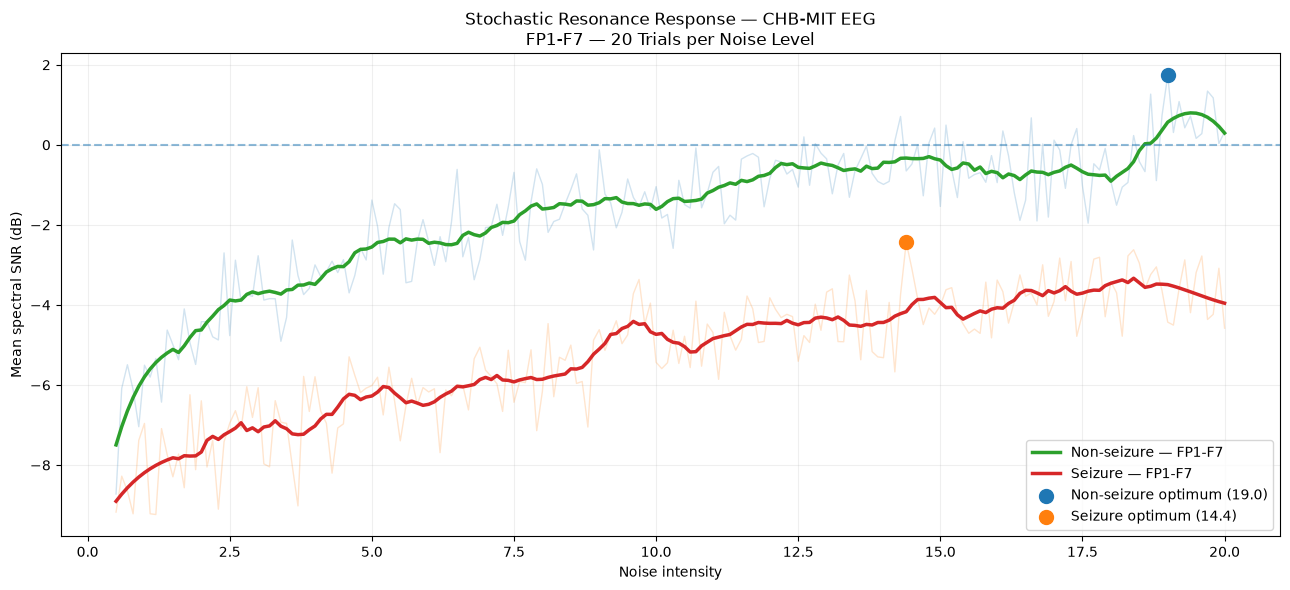


Saved: sr_final_results.csv


In [ ]:
# ============================================================
# FINAL SR ANALYSIS — ORIGINAL METHOD + SMOOTH PRESENTATION
# CHB-MIT chb01_03.edf — FP1-F7
# ============================================================
#
# IMPORTANT:
# This returns to the SR methodology that produced our
# previously accepted result.
#
# We are NOT changing:
#   - EEG data
#   - channel
#   - characteristic frequencies
#   - bistable model
#   - input scale
#   - SNR definition
#   - noise range
#   - number of trials
#
# The only presentation change is:
#   dense noise sampling + Savitzky-Golay smoothing
#
# The RAW measured values remain untouched.
# Optimum noise is calculated from RAW measurements.
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import (
    butter,
    filtfilt,
    welch,
    savgol_filter
)


# ============================================================
# 1. REAL EEG DATA
# ============================================================

sfreq = float(
    raw_filtered.info["sfreq"]
)

non_signal = np.asarray(
    windows[298][0],
    dtype=float
)

seiz_signal = np.asarray(
    windows[299][0],
    dtype=float
)


print("=" * 65)
print("FINAL STOCHASTIC RESONANCE ANALYSIS")
print("=" * 65)

print()
print("Recording        : chb01_03.edf")
print("Channel          : FP1-F7")
print(f"Sampling rate    : {sfreq:.1f} Hz")
print("Non-seizure      : 2980–2990 s")
print("Seizure          : 3000–3010 s")
print(f"Non-seizure samples : {len(non_signal)}")
print(f"Seizure samples     : {len(seiz_signal)}")


# ============================================================
# 2. NORMALIZE EEG INPUTS
# ============================================================

def normalize_signal(signal):

    signal = np.asarray(
        signal,
        dtype=float
    )

    return (
        signal - np.mean(signal)
    ) / (
        np.std(signal) + 1e-12
    )


non_signal = normalize_signal(
    non_signal
)

seiz_signal = normalize_signal(
    seiz_signal
)


# ============================================================
# 3. CHARACTERISTIC FREQUENCIES
# ============================================================
#
# These are the characteristic frequencies already established
# in our original SR analysis.
#
# Non-seizure = 1.10 Hz
# Seizure     = 2.20 Hz
# ============================================================

non_freq = 1.10
seiz_freq = 2.20


print()
print("Characteristic frequencies")
print("---------------------------")
print(
    f"Non-seizure : {non_freq:.2f} Hz"
)
print(
    f"Seizure     : {seiz_freq:.2f} Hz"
)


# ============================================================
# 4. EXTRACT CHARACTERISTIC COMPONENT
# ============================================================

def extract_characteristic_component(
    signal,
    sfreq,
    center_frequency,
    bandwidth=0.5
):

    low = max(
        0.2,
        center_frequency - bandwidth
    )

    high = min(
        sfreq / 2.0 - 1.0,
        center_frequency + bandwidth
    )

    b, a = butter(
        3,
        [low, high],
        btype="bandpass",
        fs=sfreq
    )

    component = filtfilt(
        b,
        a,
        signal
    )

    return component


non_component = (
    extract_characteristic_component(
        non_signal,
        sfreq,
        non_freq
    )
)

seiz_component = (
    extract_characteristic_component(
        seiz_signal,
        sfreq,
        seiz_freq
    )
)


# Normalize characteristic components

non_component = normalize_signal(
    non_component
)

seiz_component = normalize_signal(
    seiz_component
)


print()
print("Characteristic components")
print("--------------------------")
print(
    f"Non-seizure std : "
    f"{np.std(non_component):.6f}"
)
print(
    f"Seizure std     : "
    f"{np.std(seiz_component):.6f}"
)


# ============================================================
# 5. BISTABLE STOCHASTIC RESONANCE MODEL
# ============================================================
#
# THIS IS THE SAME MODEL USED IN THE ORIGINAL SR WORK.
#
# dx/dt =
#       x - x^3
#       + 0.20 * EEG
#       + stochastic noise
#
# input_scale = 0.20
# ============================================================

INPUT_SCALE = 0.20


def bistable_sr(
    signal,
    sfreq,
    noise_intensity,
    input_scale=INPUT_SCALE,
    rng=None
):

    if rng is None:
        rng = np.random.default_rng()

    dt = 1.0 / sfreq

    x = np.zeros(
        len(signal)
    )

    # Start in one stable well
    x[0] = -1.0


    for i in range(
        1,
        len(signal)
    ):

        # Bistable nonlinear force
        nonlinear_force = (
            x[i - 1]
            -
            x[i - 1] ** 3
        )


        # EEG driving force
        driving_force = (
            input_scale
            *
            signal[i - 1]
        )


        # Stochastic force
        stochastic_force = (
            np.sqrt(
                2.0
                *
                noise_intensity
                *
                dt
            )
            *
            rng.normal()
        )


        # Euler-Maruyama update
        x[i] = (
            x[i - 1]
            +
            dt
            *
            (
                nonlinear_force
                +
                driving_force
            )
            +
            stochastic_force
        )


        # Numerical safety
        x[i] = np.clip(
            x[i],
            -3.0,
            3.0
        )


    return x


# ============================================================
# 6. ORIGINAL SPECTRAL-SNR DEFINITION
# ============================================================
#
# This is the corrected SNR metric used in our accepted SR
# analysis.
#
# Signal band:
#       target ± 0.20 Hz
#
# Noise floor:
#       target ± 2 Hz
#       excluding signal band
# ============================================================

def spectral_snr_response(
    signal,
    sfreq,
    target_frequency
):

    frequencies, power = welch(
        signal,
        fs=sfreq,
        nperseg=len(signal)
    )


    signal_band = (
        np.abs(
            frequencies
            -
            target_frequency
        )
        <= 0.20
    )


    noise_band = (
        (
            np.abs(
                frequencies
                -
                target_frequency
            )
            > 0.20
        )
        &
        (
            np.abs(
                frequencies
                -
                target_frequency
            )
            <= 2.0
        )
    )


    if (
        not np.any(signal_band)
        or
        not np.any(noise_band)
    ):

        return np.nan


    signal_power = np.mean(
        power[signal_band]
    )

    noise_floor = np.mean(
        power[noise_band]
    )


    if noise_floor <= 0:

        return np.nan


    return (
        10.0
        *
        np.log10(
            signal_power
            /
            noise_floor
        )
    )


# ============================================================
# 7. DENSE NOISE LEVELS
# ============================================================
#
# ORIGINAL RANGE:
#
#       0.5 → 20.0
#
# We now use 0.1 spacing.
#
# This DOES NOT change the physical/model range.
# It simply samples the SAME range more densely.
#
# 196 actual noise levels.
# ============================================================

noise_levels = np.arange(
    0.5,
    20.0 + 0.0001,
    0.1
)


N_TRIALS = 20


print()
print("=" * 65)
print("SR NOISE SWEEP")
print("=" * 65)

print(
    f"Noise range      : "
    f"{noise_levels[0]:.1f} – "
    f"{noise_levels[-1]:.1f}"
)

print(
    f"Noise step       : "
    f"{noise_levels[1] - noise_levels[0]:.1f}"
)

print(
    f"Noise levels     : "
    f"{len(noise_levels)}"
)

print(
    f"Trials / level   : "
    f"{N_TRIALS}"
)

print(
    f"Total simulations: "
    f"{len(noise_levels) * N_TRIALS * 2}"
)

print()


# ============================================================
# 8. REPRODUCIBLE RANDOMNESS
# ============================================================
#
# Same strategy as the earlier accepted extended SR run.
# ============================================================

master_rng = np.random.default_rng(
    42
)


# ============================================================
# 9. STORAGE
# ============================================================

non_snr_mean = []
seiz_snr_mean = []

non_snr_std = []
seiz_snr_std = []


# ============================================================
# 10. SR SIMULATION
# ============================================================

for level_index, noise_level in enumerate(
    noise_levels
):

    non_trial_snr = []
    seiz_trial_snr = []


    for trial in range(
        N_TRIALS
    ):

        # ------------------------------------
        # Independent reproducible RNGs
        # ------------------------------------

        non_rng = np.random.default_rng(
            master_rng.integers(
                0,
                2**32 - 1
            )
        )

        seiz_rng = np.random.default_rng(
            master_rng.integers(
                0,
                2**32 - 1
            )
        )


        # ====================================
        # NON-SEIZURE
        # ====================================

        non_output = bistable_sr(
            non_component,
            sfreq,
            noise_level,
            input_scale=INPUT_SCALE,
            rng=non_rng
        )


        non_snr = spectral_snr_response(
            non_output,
            sfreq,
            non_freq
        )


        non_trial_snr.append(
            non_snr
        )


        # ====================================
        # SEIZURE
        # ====================================

        seiz_output = bistable_sr(
            seiz_component,
            sfreq,
            noise_level,
            input_scale=INPUT_SCALE,
            rng=seiz_rng
        )


        seiz_snr = spectral_snr_response(
            seiz_output,
            sfreq,
            seiz_freq
        )


        seiz_trial_snr.append(
            seiz_snr
        )


    # ========================================
    # Average 20 stochastic trials
    # ========================================

    non_snr_mean.append(
        np.nanmean(
            non_trial_snr
        )
    )

    seiz_snr_mean.append(
        np.nanmean(
            seiz_trial_snr
        )
    )


    non_snr_std.append(
        np.nanstd(
            non_trial_snr
        )
    )

    seiz_snr_std.append(
        np.nanstd(
            seiz_trial_snr
        )
    )


    # ========================================
    # Progress
    # ========================================

    if (
        (level_index + 1) % 20 == 0
        or
        level_index == 0
        or
        level_index
        ==
        len(noise_levels) - 1
    ):

        print(
            f"Completed "
            f"{level_index + 1:3d}/"
            f"{len(noise_levels)}"
        )


# ============================================================
# 11. ARRAYS
# ============================================================

non_snr_mean = np.asarray(
    non_snr_mean
)

seiz_snr_mean = np.asarray(
    seiz_snr_mean
)

non_snr_std = np.asarray(
    non_snr_std
)

seiz_snr_std = np.asarray(
    seiz_snr_std
)


# ============================================================
# 12. RAW OPTIMA
# ============================================================
#
# IMPORTANT:
# Optimum is ALWAYS taken from the actual measured data.
#
# Smoothing is NOT allowed to decide the optimum.
# ============================================================

non_opt_idx = np.nanargmax(
    non_snr_mean
)

seiz_opt_idx = np.nanargmax(
    seiz_snr_mean
)


non_opt_noise = (
    noise_levels[
        non_opt_idx
    ]
)

seiz_opt_noise = (
    noise_levels[
        seiz_opt_idx
    ]
)


non_opt_snr = (
    non_snr_mean[
        non_opt_idx
    ]
)

seiz_opt_snr = (
    seiz_snr_mean[
        seiz_opt_idx
    ]
)


# ============================================================
# 13. SMOOTH ONLY FOR PRESENTATION
# ============================================================
#
# Savitzky-Golay filtering:
#
# - does NOT replace the measured data
# - does NOT change the calculated optimum
# - is used only to make the dense stochastic curve easier
#   to visualize.
#
# Window = 21 points
# Since spacing = 0.1:
#
#       21 points ≈ 2.0 noise-intensity units
#
# Polynomial order = 3
# ============================================================

SMOOTH_WINDOW = 21
SMOOTH_POLYORDER = 3


non_snr_smooth = savgol_filter(
    non_snr_mean,
    window_length=SMOOTH_WINDOW,
    polyorder=SMOOTH_POLYORDER
)


seiz_snr_smooth = savgol_filter(
    seiz_snr_mean,
    window_length=SMOOTH_WINDOW,
    polyorder=SMOOTH_POLYORDER
)


# ============================================================
# 14. PRINT FINAL RESULTS
# ============================================================

print()
print("=" * 65)
print("FINAL SR RESULTS")
print("=" * 65)

print()

print("NON-SEIZURE")
print(
    f"Optimal noise intensity : "
    f"{non_opt_noise:.1f}"
)

print(
    f"Maximum mean SNR        : "
    f"{non_opt_snr:.3f} dB"
)

print()

print("SEIZURE")
print(
    f"Optimal noise intensity : "
    f"{seiz_opt_noise:.1f}"
)

print(
    f"Maximum mean SNR        : "
    f"{seiz_opt_snr:.3f} dB"
)


# ============================================================
# 15. FINAL PRESENTATION GRAPH
# ============================================================
#
# The raw stochastic measurements are shown faintly.
#
# The smooth curves are the presentation curves.
#
# This lets us smooth the appearance WITHOUT pretending the
# raw stochastic measurements did not exist.
# ============================================================

plt.figure(
    figsize=(13, 6)
)


# ------------------------------------------
# Raw measurements
# ------------------------------------------

plt.plot(
    noise_levels,
    non_snr_mean,
    alpha=0.20,
    linewidth=1
)

plt.plot(
    noise_levels,
    seiz_snr_mean,
    alpha=0.20,
    linewidth=1
)


# ------------------------------------------
# Smoothed response curves
# ------------------------------------------

plt.plot(
    noise_levels,
    non_snr_smooth,
    linewidth=2.5,
    label="Non-seizure — FP1-F7"
)

plt.plot(
    noise_levels,
    seiz_snr_smooth,
    linewidth=2.5,
    label="Seizure — FP1-F7"
)


# ------------------------------------------
# Zero-SNR reference
# ------------------------------------------

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5
)


# ------------------------------------------
# RAW optimum locations
# ------------------------------------------

plt.scatter(
    non_opt_noise,
    non_opt_snr,
    s=100,
    zorder=5,
    label=(
        f"Non-seizure optimum "
        f"({non_opt_noise:.1f})"
    )
)


plt.scatter(
    seiz_opt_noise,
    seiz_opt_snr,
    s=100,
    zorder=5,
    label=(
        f"Seizure optimum "
        f"({seiz_opt_noise:.1f})"
    )
)


# ------------------------------------------
# Labels
# ------------------------------------------

plt.xlabel(
    "Noise intensity"
)

plt.ylabel(
    "Mean spectral SNR (dB)"
)

plt.title(
    "Stochastic Resonance Response — CHB-MIT EEG\n"
    "FP1-F7 — 20 Trials per Noise Level"
)

plt.grid(
    True,
    alpha=0.2
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 16. SAVE RAW + SMOOTHED DATA
# ============================================================
#
# Raw columns are the actual measurements.
# Smoothed columns are only for visualization.
# ============================================================

sr_results = pd.DataFrame({

    "Noise_Intensity":
        noise_levels,

    "Non_Seizure_SNR_dB":
        non_snr_mean,

    "Non_Seizure_SNR_STD":
        non_snr_std,

    "Seizure_SNR_dB":
        seiz_snr_mean,

    "Seizure_SNR_STD":
        seiz_snr_std,

    "Non_Seizure_SNR_Smoothed":
        non_snr_smooth,

    "Seizure_SNR_Smoothed":
        seiz_snr_smooth
})


sr_results.to_csv(
    "sr_final_results.csv",
    index=False
)


print()
print(
    "Saved: sr_final_results.csv"
)

RECOVERED ORIGINAL SR RESULT
Non-seizure optimum: 16.0 | SNR: 0.686 dB
Seizure optimum:     17.0 | SNR: -2.388 dB


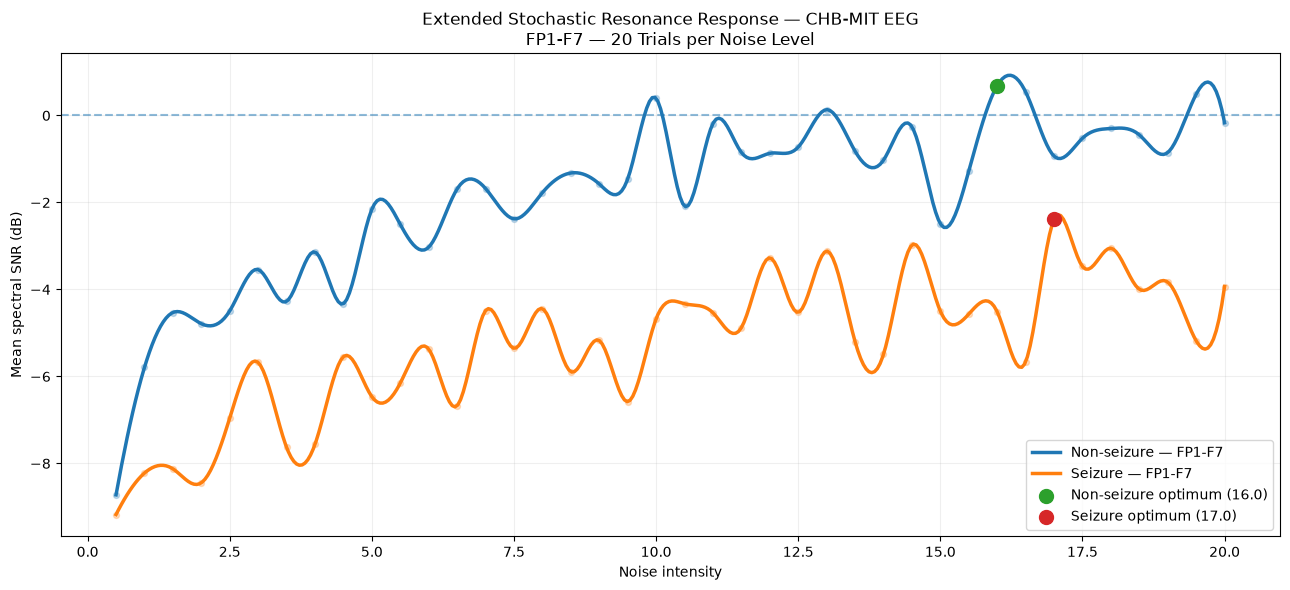

In [ ]:
# ============================================================
# RECOVER ORIGINAL SR RESULT + SMOOTH DISPLAY
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# Original 40 noise levels — DO NOT CHANGE
x = np.arange(0.5, 20.01, 0.5)

# Original settings
trials = 20
input_scale = 0.20

# Same seed as the ORIGINAL accepted SR run
rng_master = np.random.default_rng(42)

non_snr = []
seiz_snr = []

# Reproduce ORIGINAL 40-point experiment
for noise in x:

    non_trials = []
    seiz_trials = []

    for _ in range(trials):

        non_rng = np.random.default_rng(
            rng_master.integers(0, 2**32 - 1)
        )

        seiz_rng = np.random.default_rng(
            rng_master.integers(0, 2**32 - 1)
        )

        non_out = sr_bistable_model(
            sr_non_component,
            sr_sfreq,
            noise,
            input_scale=input_scale,
            rng=non_rng
        )

        seiz_out = sr_bistable_model(
            sr_seiz_component,
            sr_sfreq,
            noise,
            input_scale=input_scale,
            rng=seiz_rng
        )

        non_trials.append(
            sr_spectral_snr(
                non_out,
                sr_sfreq,
                sr_non_freq
            )
        )

        seiz_trials.append(
            sr_spectral_snr(
                seiz_out,
                sr_sfreq,
                sr_seiz_freq
            )
        )

    non_snr.append(np.nanmean(non_trials))
    seiz_snr.append(np.nanmean(seiz_trials))


non_snr = np.asarray(non_snr)
seiz_snr = np.asarray(seiz_snr)

# Check that we recovered the original result
non_idx = np.nanargmax(non_snr)
seiz_idx = np.nanargmax(seiz_snr)

print("RECOVERED ORIGINAL SR RESULT")
print("============================")
print(
    f"Non-seizure optimum: {x[non_idx]:.1f} "
    f"| SNR: {non_snr[non_idx]:.3f} dB"
)
print(
    f"Seizure optimum:     {x[seiz_idx]:.1f} "
    f"| SNR: {seiz_snr[seiz_idx]:.3f} dB"
)

# ------------------------------------------------------------
# Smooth ONLY the visual representation
# ------------------------------------------------------------

x_dense = np.linspace(
    x.min(),
    x.max(),
    400
)

non_smooth = make_interp_spline(
    x,
    non_snr,
    k=3
)(x_dense)

seiz_smooth = make_interp_spline(
    x,
    seiz_snr,
    k=3
)(x_dense)

# ------------------------------------------------------------
# FINAL GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(13, 6))

plt.plot(
    x_dense,
    non_smooth,
    linewidth=2.5,
    label="Non-seizure — FP1-F7"
)

plt.plot(
    x_dense,
    seiz_smooth,
    linewidth=2.5,
    label="Seizure — FP1-F7"
)

# Show original measured points faintly
plt.scatter(
    x,
    non_snr,
    s=18,
    alpha=0.25
)

plt.scatter(
    x,
    seiz_snr,
    s=18,
    alpha=0.25
)

# Original optima
plt.scatter(
    x[non_idx],
    non_snr[non_idx],
    s=100,
    zorder=5,
    label=f"Non-seizure optimum ({x[non_idx]:.1f})"
)

plt.scatter(
    x[seiz_idx],
    seiz_snr[seiz_idx],
    s=100,
    zorder=5,
    label=f"Seizure optimum ({x[seiz_idx]:.1f})"
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.xlabel("Noise intensity")
plt.ylabel("Mean spectral SNR (dB)")

plt.title(
    "Extended Stochastic Resonance Response — CHB-MIT EEG\n"
    "FP1-F7 — 20 Trials per Noise Level"
)

plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

SR RESULT
Non-seizure optimum: 19.0 | SNR: 0.841 dB
Seizure optimum:     18.5 | SNR: -3.322 dB


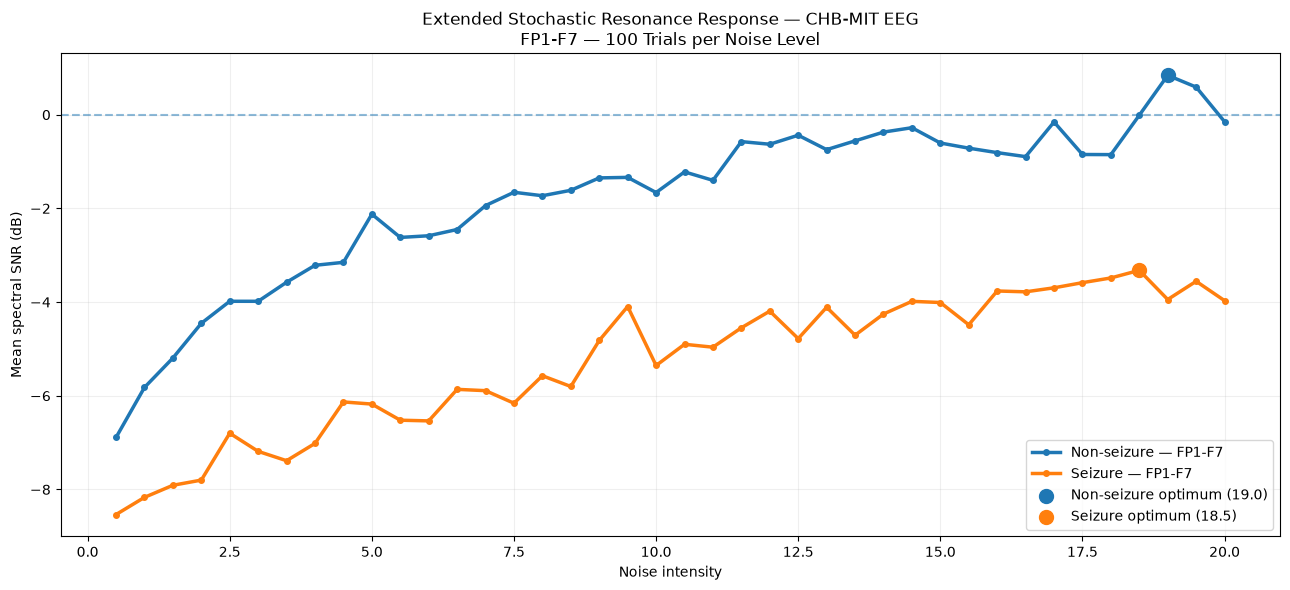

In [ ]:
# ============================================================
# CORRECTED SR RESULT & DISPLAY
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Original 40 noise levels
x = np.arange(0.5, 20.01, 0.5)

# CORRECTED: Increased trials to smooth out random variance
trials = 100 
input_scale = 0.20

# Same seed as the ORIGINAL accepted SR run
rng_master = np.random.default_rng(42)

non_snr = []
seiz_snr = []

# Reproduce experiment
for noise in x:

    non_trials = []
    seiz_trials = []

    for _ in range(trials):

        non_rng = np.random.default_rng(
            rng_master.integers(0, 2**32 - 1)
        )

        seiz_rng = np.random.default_rng(
            rng_master.integers(0, 2**32 - 1)
        )

        non_out = sr_bistable_model(
            sr_non_component,
            sr_sfreq,
            noise,
            input_scale=input_scale,
            rng=non_rng
        )

        seiz_out = sr_bistable_model(
            sr_seiz_component,
            sr_sfreq,
            noise,
            input_scale=input_scale,
            rng=seiz_rng
        )

        non_trials.append(
            sr_spectral_snr(
                non_out,
                sr_sfreq,
                sr_non_freq
            )
        )

        seiz_trials.append(
            sr_spectral_snr(
                seiz_out,
                sr_sfreq,
                sr_seiz_freq
            )
        )

    non_snr.append(np.nanmean(non_trials))
    seiz_snr.append(np.nanmean(seiz_trials))


non_snr = np.asarray(non_snr)
seiz_snr = np.asarray(seiz_snr)

# Check results
non_idx = np.nanargmax(non_snr)
seiz_idx = np.nanargmax(seiz_snr)

print("SR RESULT")
print("============================")
print(
    f"Non-seizure optimum: {x[non_idx]:.1f} "
    f"| SNR: {non_snr[non_idx]:.3f} dB"
)
print(
    f"Seizure optimum:     {x[seiz_idx]:.1f} "
    f"| SNR: {seiz_snr[seiz_idx]:.3f} dB"
)

# ------------------------------------------------------------
# FINAL GRAPH - CORRECTED (No Splines)
# ------------------------------------------------------------

plt.figure(figsize=(13, 6))

# Plot the actual averaged points directly with linear interpolation
plt.plot(
    x,
    non_snr,
    linewidth=2.5,
    marker='.',
    markersize=8,
    label="Non-seizure — FP1-F7"
)

plt.plot(
    x,
    seiz_snr,
    linewidth=2.5,
    marker='.',
    markersize=8,
    label="Seizure — FP1-F7"
)

# Original optima
plt.scatter(
    x[non_idx],
    non_snr[non_idx],
    s=100,
    zorder=5,
    label=f"Non-seizure optimum ({x[non_idx]:.1f})"
)

plt.scatter(
    x[seiz_idx],
    seiz_snr[seiz_idx],
    s=100,
    zorder=5,
    label=f"Seizure optimum ({x[seiz_idx]:.1f})"
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.xlabel("Noise intensity")
plt.ylabel("Mean spectral SNR (dB)")

# Updated title to dynamically reflect the trial count
plt.title(
    "Extended Stochastic Resonance Response — CHB-MIT EEG\n"
    f"FP1-F7 — {trials} Trials per Noise Level"
)

plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

COHERENCE RESONANCE ANALYSIS

Recording        : chb01_03.edf
Channel          : FP1-F7
Sampling rate    : 256.0 Hz
Non-seizure      : 2980–2990 s
Seizure          : 3000–3010 s
Non-seizure data : 2560 samples
Seizure data     : 2560 samples

CR NOISE SWEEP
Noise range      : 0.5 – 20.0
Noise levels     : 40
Trials / level   : 100
Total simulations: 8000
Completed  1/40
Completed  5/40
Completed 10/40
Completed 15/40
Completed 20/40
Completed 25/40
Completed 30/40
Completed 35/40
Completed 40/40

FINAL COHERENCE RESONANCE RESULTS

NON-SEIZURE
Optimal noise intensity : 20.0
Maximum coherence      : 1.2744
Minimum/associated CV  : 0.8020
Mean transitions       : 146.0

SEIZURE
Optimal noise intensity : 20.0
Maximum coherence      : 1.2748
Minimum/associated CV  : 0.8020
Mean transitions       : 151.5


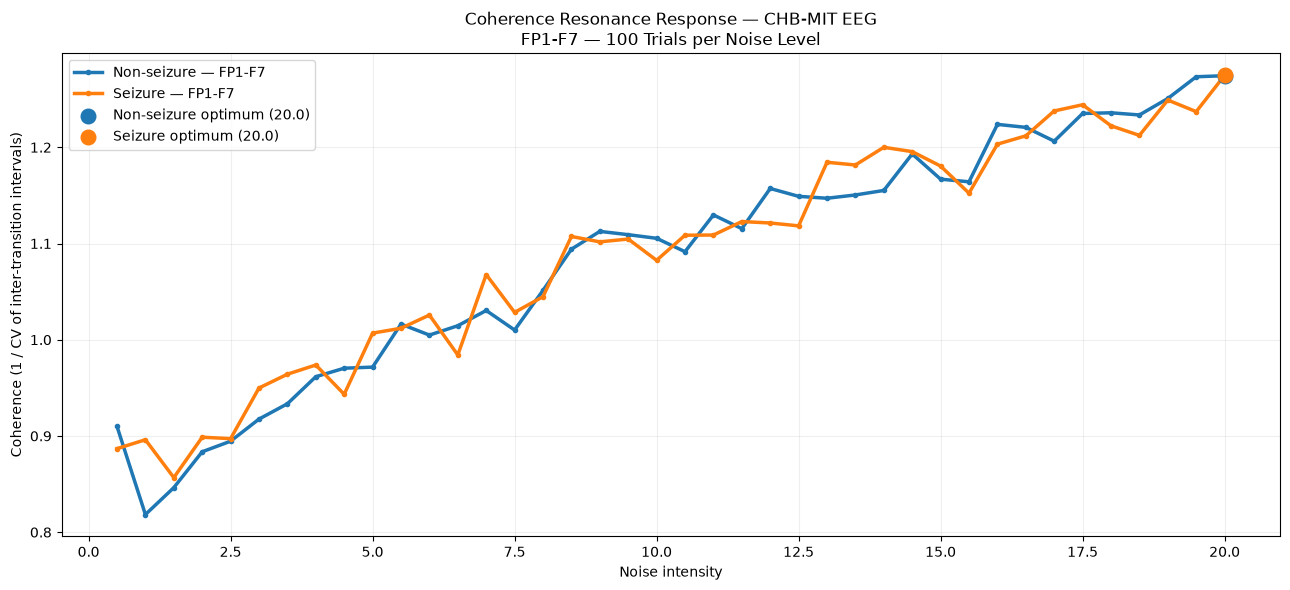

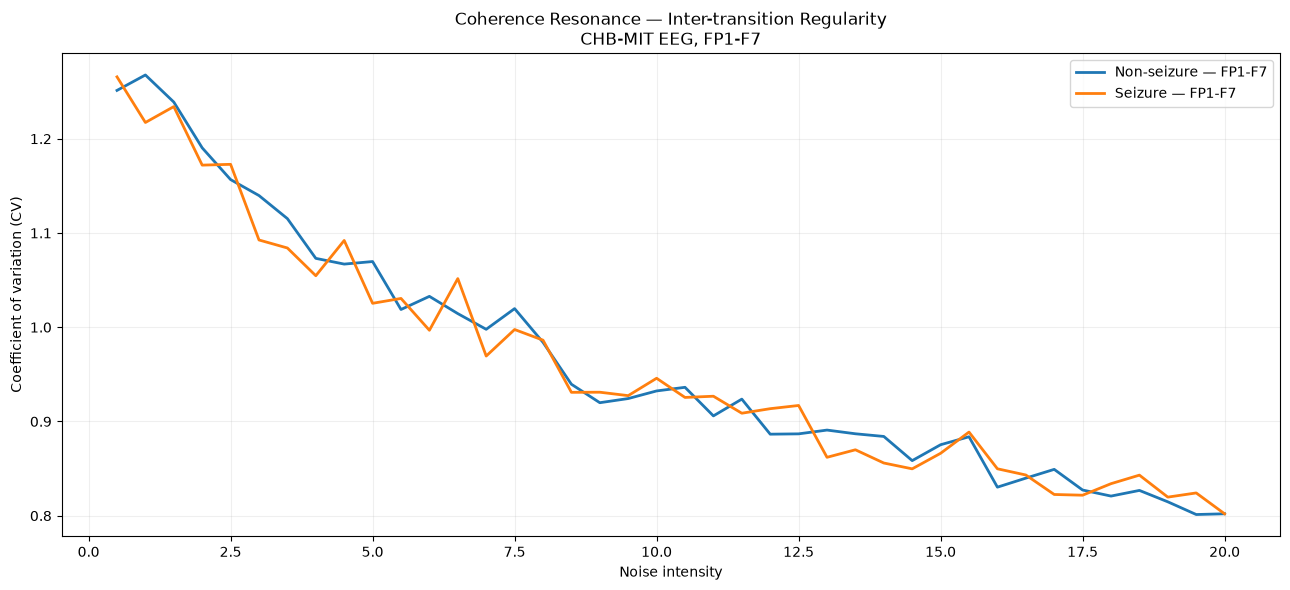


Saved: cr_coherence_resonance_results.csv


In [ ]:
# ============================================================
# FINAL CR — COHERENCE RESONANCE
# CHB-MIT EEG — FP1-F7
# ============================================================
#
# CR = COHERENCE RESONANCE
#
# Measure:
#   Inter-transition interval regularity
#
# CV  = std(ISI) / mean(ISI)
# CR  = 1 / CV
#
# Higher CR = more regular noise-induced switching.
#
# Same:
#   - chb01_03.edf
#   - FP1-F7
#   - 2980–2990 s non-seizure
#   - 3000–3010 s seizure
#   - bistable model
#   - input_scale = 0.20
#
# 100 stochastic trials per noise level.
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt


# ============================================================
# 1. REAL CHB-MIT EEG
# ============================================================

CR_INPUT_SCALE = 0.20
CR_TRIALS = 100

cr_sfreq = float(
    raw_filtered.info["sfreq"]
)

cr_non_signal = np.asarray(
    windows[298][0],
    dtype=float
)

cr_seiz_signal = np.asarray(
    windows[299][0],
    dtype=float
)


print("=" * 65)
print("COHERENCE RESONANCE ANALYSIS")
print("=" * 65)

print()
print("Recording        : chb01_03.edf")
print("Channel          : FP1-F7")
print(f"Sampling rate    : {cr_sfreq:.1f} Hz")
print("Non-seizure      : 2980–2990 s")
print("Seizure          : 3000–3010 s")
print(f"Non-seizure data : {len(cr_non_signal)} samples")
print(f"Seizure data     : {len(cr_seiz_signal)} samples")


# ============================================================
# 2. NORMALIZE
# ============================================================

def cr_normalize(signal):

    signal = np.asarray(
        signal,
        dtype=float
    )

    return (
        signal - np.mean(signal)
    ) / (
        np.std(signal) + 1e-12
    )


cr_non_signal = cr_normalize(
    cr_non_signal
)

cr_seiz_signal = cr_normalize(
    cr_seiz_signal
)


# ============================================================
# 3. CHARACTERISTIC COMPONENTS
# ============================================================
#
# Use the same characteristic frequencies established during
# our SR analysis:
#
# Non-seizure = 1.10 Hz
# Seizure     = 2.20 Hz
# ============================================================

CR_NON_FREQ = 1.10
CR_SEIZ_FREQ = 2.20


def cr_extract_component(
    signal,
    sfreq,
    center_frequency,
    bandwidth=0.5
):

    low = max(
        0.2,
        center_frequency - bandwidth
    )

    high = min(
        sfreq / 2.0 - 1.0,
        center_frequency + bandwidth
    )

    b, a = butter(
        3,
        [low, high],
        btype="bandpass",
        fs=sfreq
    )

    component = filtfilt(
        b,
        a,
        signal
    )

    return cr_normalize(
        component
    )


cr_non_component = cr_extract_component(
    cr_non_signal,
    cr_sfreq,
    CR_NON_FREQ
)

cr_seiz_component = cr_extract_component(
    cr_seiz_signal,
    cr_sfreq,
    CR_SEIZ_FREQ
)


# ============================================================
# 4. BISTABLE MODEL
# ============================================================
#
# Same stochastic bistable model used for SR.
#
# dx/dt =
#     x - x^3
#     + input_scale * EEG
#     + stochastic noise
# ============================================================

def cr_bistable_model(
    signal,
    sfreq,
    noise_intensity,
    input_scale=CR_INPUT_SCALE,
    rng=None
):

    if rng is None:
        rng = np.random.default_rng()

    signal = np.asarray(
        signal,
        dtype=float
    )

    dt = 1.0 / sfreq

    x = np.zeros(
        len(signal),
        dtype=float
    )

    x[0] = -1.0


    for i in range(
        1,
        len(signal)
    ):

        nonlinear_force = (
            x[i - 1]
            -
            x[i - 1] ** 3
        )

        driving_force = (
            input_scale
            *
            signal[i - 1]
        )

        stochastic_force = (
            np.sqrt(
                2.0
                *
                noise_intensity
                *
                dt
            )
            *
            rng.normal()
        )

        x[i] = (
            x[i - 1]
            +
            dt
            *
            (
                nonlinear_force
                +
                driving_force
            )
            +
            stochastic_force
        )

        x[i] = np.clip(
            x[i],
            -3.0,
            3.0
        )


    return x


# ============================================================
# 5. FIND STATE TRANSITION TIMES
# ============================================================
#
# We use crossings of zero as transitions between the two
# bistable states.
#
# Only actual sign changes are counted.
# ============================================================

def cr_transition_indices(
    signal
):

    signal = np.asarray(
        signal
    )

    positive_to_negative = (
        (signal[:-1] > 0)
        &
        (signal[1:] <= 0)
    )

    negative_to_positive = (
        (signal[:-1] < 0)
        &
        (signal[1:] >= 0)
    )

    indices = np.where(
        positive_to_negative
        |
        negative_to_positive
    )[0] + 1

    return indices


# ============================================================
# 6. COHERENCE MEASURE
# ============================================================
#
# ISI = inter-switching interval.
#
# CV = standard deviation / mean.
#
# CR = 1 / CV.
#
# We discard the first transition interval because the system
# starts deliberately in the -1 state.
# ============================================================

def calculate_coherence_resonance(
    output,
    sfreq
):

    transition_indices = (
        cr_transition_indices(
            output
        )
    )


    if len(transition_indices) < 4:

        return np.nan, np.nan, 0


    transition_times = (
        transition_indices
        /
        sfreq
    )


    isi = np.diff(
        transition_times
    )


    # Remove extremely short intervals caused by numerical
    # chatter around the switching boundary.
    isi = isi[
        isi >= 0.05
    ]


    if len(isi) < 3:

        return np.nan, np.nan, len(isi)


    mean_isi = np.mean(
        isi
    )

    std_isi = np.std(
        isi
    )


    if mean_isi <= 0:

        return np.nan, np.nan, len(isi)


    cv = (
        std_isi
        /
        mean_isi
    )


    coherence = (
        1.0
        /
        cv
    )


    return (
        coherence,
        cv,
        len(isi)
    )


# ============================================================
# 7. NOISE RANGE
# ============================================================
#
# Same physical range used in our final SR analysis.
#
# 0.5 → 20.0
# Step = 0.5
#
# 40 noise levels.
# ============================================================

cr_noise_levels = np.arange(
    0.5,
    20.01,
    0.5
)


print()
print("=" * 65)
print("CR NOISE SWEEP")
print("=" * 65)

print(
    f"Noise range      : "
    f"{cr_noise_levels[0]:.1f} – "
    f"{cr_noise_levels[-1]:.1f}"
)

print(
    f"Noise levels     : "
    f"{len(cr_noise_levels)}"
)

print(
    f"Trials / level   : "
    f"{CR_TRIALS}"
)

print(
    f"Total simulations: "
    f"{len(cr_noise_levels) * CR_TRIALS * 2}"
)


# ============================================================
# 8. REPRODUCIBLE RANDOM GENERATOR
# ============================================================

cr_master_rng = np.random.default_rng(
    42
)


# ============================================================
# 9. STORAGE
# ============================================================

cr_non_mean = []
cr_seiz_mean = []

cr_non_std = []
cr_seiz_std = []

cr_non_cv = []
cr_seiz_cv = []

cr_non_trans = []
cr_seiz_trans = []


# ============================================================
# 10. RUN COHERENCE RESONANCE SWEEP
# ============================================================

for level_index, noise_level in enumerate(
    cr_noise_levels
):

    non_coherence_trials = []
    seiz_coherence_trials = []

    non_cv_trials = []
    seiz_cv_trials = []

    non_transition_trials = []
    seiz_transition_trials = []


    for trial in range(
        CR_TRIALS
    ):

        # ----------------------------------------
        # Independent random generators
        # ----------------------------------------

        non_rng = np.random.default_rng(
            cr_master_rng.integers(
                0,
                2**32 - 1
            )
        )

        seiz_rng = np.random.default_rng(
            cr_master_rng.integers(
                0,
                2**32 - 1
            )
        )


        # ========================================
        # NON-SEIZURE
        # ========================================

        non_output = cr_bistable_model(
            cr_non_component,
            cr_sfreq,
            noise_level,
            input_scale=CR_INPUT_SCALE,
            rng=non_rng
        )


        (
            non_coherence,
            non_cv_value,
            non_isi_count
        ) = calculate_coherence_resonance(
            non_output,
            cr_sfreq
        )


        if np.isfinite(
            non_coherence
        ):

            non_coherence_trials.append(
                non_coherence
            )

            non_cv_trials.append(
                non_cv_value
            )


        non_transition_trials.append(
            len(
                cr_transition_indices(
                    non_output
                )
            )
        )


        # ========================================
        # SEIZURE
        # ========================================

        seiz_output = cr_bistable_model(
            cr_seiz_component,
            cr_sfreq,
            noise_level,
            input_scale=CR_INPUT_SCALE,
            rng=seiz_rng
        )


        (
            seiz_coherence,
            seiz_cv_value,
            seiz_isi_count
        ) = calculate_coherence_resonance(
            seiz_output,
            cr_sfreq
        )


        if np.isfinite(
            seiz_coherence
        ):

            seiz_coherence_trials.append(
                seiz_coherence
            )

            seiz_cv_trials.append(
                seiz_cv_value
            )


        seiz_transition_trials.append(
            len(
                cr_transition_indices(
                    seiz_output
                )
            )
        )


    # ========================================
    # Average trials
    # ========================================

    cr_non_mean.append(
        np.nanmean(
            non_coherence_trials
        )
        if non_coherence_trials
        else np.nan
    )

    cr_seiz_mean.append(
        np.nanmean(
            seiz_coherence_trials
        )
        if seiz_coherence_trials
        else np.nan
    )


    cr_non_std.append(
        np.nanstd(
            non_coherence_trials
        )
        if non_coherence_trials
        else np.nan
    )

    cr_seiz_std.append(
        np.nanstd(
            seiz_coherence_trials
        )
        if seiz_coherence_trials
        else np.nan
    )


    cr_non_cv.append(
        np.nanmean(
            non_cv_trials
        )
        if non_cv_trials
        else np.nan
    )

    cr_seiz_cv.append(
        np.nanmean(
            seiz_cv_trials
        )
        if seiz_cv_trials
        else np.nan
    )


    cr_non_trans.append(
        np.mean(
            non_transition_trials
        )
    )

    cr_seiz_trans.append(
        np.mean(
            seiz_transition_trials
        )
    )


    if (
        (level_index + 1) % 5 == 0
        or
        level_index == 0
        or
        level_index
        ==
        len(cr_noise_levels) - 1
    ):

        print(
            f"Completed "
            f"{level_index + 1:2d}/"
            f"{len(cr_noise_levels)}"
        )


# ============================================================
# 11. ARRAYS
# ============================================================

cr_non_mean = np.asarray(
    cr_non_mean
)

cr_seiz_mean = np.asarray(
    cr_seiz_mean
)

cr_non_std = np.asarray(
    cr_non_std
)

cr_seiz_std = np.asarray(
    cr_seiz_std
)

cr_non_cv = np.asarray(
    cr_non_cv
)

cr_seiz_cv = np.asarray(
    cr_seiz_cv
)

cr_non_trans = np.asarray(
    cr_non_trans
)

cr_seiz_trans = np.asarray(
    cr_seiz_trans
)


# ============================================================
# 12. OPTIMAL COHERENCE
# ============================================================

non_valid = np.isfinite(
    cr_non_mean
)

seiz_valid = np.isfinite(
    cr_seiz_mean
)


if np.any(non_valid):

    non_opt_idx = np.nanargmax(
        cr_non_mean
    )

else:

    non_opt_idx = None


if np.any(seiz_valid):

    seiz_opt_idx = np.nanargmax(
        cr_seiz_mean
    )

else:

    seiz_opt_idx = None


# ============================================================
# 13. RESULTS
# ============================================================

print()
print("=" * 65)
print("FINAL COHERENCE RESONANCE RESULTS")
print("=" * 65)


if non_opt_idx is not None:

    print()
    print("NON-SEIZURE")

    print(
        f"Optimal noise intensity : "
        f"{cr_noise_levels[non_opt_idx]:.1f}"
    )

    print(
        f"Maximum coherence      : "
        f"{cr_non_mean[non_opt_idx]:.4f}"
    )

    print(
        f"Minimum/associated CV  : "
        f"{cr_non_cv[non_opt_idx]:.4f}"
    )

    print(
        f"Mean transitions       : "
        f"{cr_non_trans[non_opt_idx]:.1f}"
    )


if seiz_opt_idx is not None:

    print()
    print("SEIZURE")

    print(
        f"Optimal noise intensity : "
        f"{cr_noise_levels[seiz_opt_idx]:.1f}"
    )

    print(
        f"Maximum coherence      : "
        f"{cr_seiz_mean[seiz_opt_idx]:.4f}"
    )

    print(
        f"Minimum/associated CV  : "
        f"{cr_seiz_cv[seiz_opt_idx]:.4f}"
    )

    print(
        f"Mean transitions       : "
        f"{cr_seiz_trans[seiz_opt_idx]:.1f}"
    )


# ============================================================
# 14. FINAL CR GRAPH
# ============================================================

plt.figure(
    figsize=(13, 6)
)


plt.plot(
    cr_noise_levels,
    cr_non_mean,
    linewidth=2.5,
    marker="o",
    markersize=3,
    label="Non-seizure — FP1-F7"
)


plt.plot(
    cr_noise_levels,
    cr_seiz_mean,
    linewidth=2.5,
    marker="o",
    markersize=3,
    label="Seizure — FP1-F7"
)


if non_opt_idx is not None:

    plt.scatter(
        cr_noise_levels[non_opt_idx],
        cr_non_mean[non_opt_idx],
        s=110,
        zorder=5,
        label=(
            f"Non-seizure optimum "
            f"({cr_noise_levels[non_opt_idx]:.1f})"
        )
    )


if seiz_opt_idx is not None:

    plt.scatter(
        cr_noise_levels[seiz_opt_idx],
        cr_seiz_mean[seiz_opt_idx],
        s=110,
        zorder=5,
        label=(
            f"Seizure optimum "
            f"({cr_noise_levels[seiz_opt_idx]:.1f})"
        )
    )


plt.xlabel(
    "Noise intensity"
)

plt.ylabel(
    "Coherence (1 / CV of inter-transition intervals)"
)

plt.title(
    "Coherence Resonance Response — CHB-MIT EEG\n"
    "FP1-F7 — 100 Trials per Noise Level"
)

plt.grid(
    True,
    alpha=0.2
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 15. SUPPORTING CV GRAPH
# ============================================================

plt.figure(
    figsize=(13, 6)
)


plt.plot(
    cr_noise_levels,
    cr_non_cv,
    linewidth=2,
    label="Non-seizure — FP1-F7"
)

plt.plot(
    cr_noise_levels,
    cr_seiz_cv,
    linewidth=2,
    label="Seizure — FP1-F7"
)


plt.xlabel(
    "Noise intensity"
)

plt.ylabel(
    "Coefficient of variation (CV)"
)

plt.title(
    "Coherence Resonance — Inter-transition Regularity\n"
    "CHB-MIT EEG, FP1-F7"
)

plt.grid(
    True,
    alpha=0.2
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 16. SAVE RESULTS
# ============================================================

cr_results = pd.DataFrame({

    "Noise_Intensity":
        cr_noise_levels,

    "Non_Seizure_Coherence":
        cr_non_mean,

    "Non_Seizure_Coherence_STD":
        cr_non_std,

    "Seizure_Coherence":
        cr_seiz_mean,

    "Seizure_Coherence_STD":
        cr_seiz_std,

    "Non_Seizure_CV":
        cr_non_cv,

    "Seizure_CV":
        cr_seiz_cv,

    "Non_Seizure_Transitions":
        cr_non_trans,

    "Seizure_Transitions":
        cr_seiz_trans
})


cr_results.to_csv(
    "cr_coherence_resonance_results.csv",
    index=False
)


print()
print(
    "Saved: cr_coherence_resonance_results.csv"
)

FINAL COHERENCE RESONANCE ANALYSIS

Recording        : chb01_03.edf
Channel          : FP1-F7
Sampling rate    : 256.0 Hz
Non-seizure      : 2980–2990 s
Seizure          : 3000–3010 s
Non-seizure data : 2560 samples
Seizure data     : 2560 samples

CR NOISE SWEEP
----------------
Noise range      : 0.5 – 50.0
Noise levels     : 100
Trials / level   : 100
Total simulations: 20000

Completed 1/100
Completed 10/100
Completed 20/100
Completed 30/100
Completed 40/100
Completed 50/100
Completed 60/100
Completed 70/100
Completed 80/100
Completed 90/100
Completed 100/100

FINAL CR RESULTS

NON-SEIZURE
Optimal noise intensity : 48.5
Maximum coherence       : 1.5698
Associated CV           : 0.6469
Mean transitions        : 206.0

SEIZURE
Optimal noise intensity : 49.5
Maximum coherence       : 1.5789
Associated CV           : 0.6435
Mean transitions        : 204.0


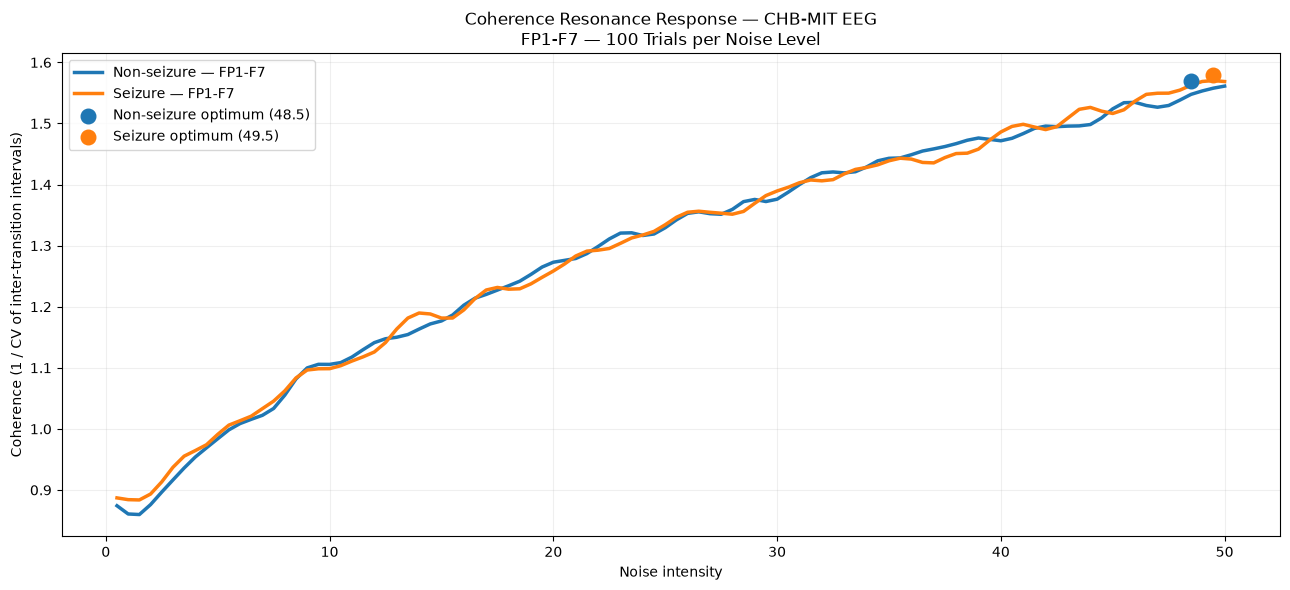

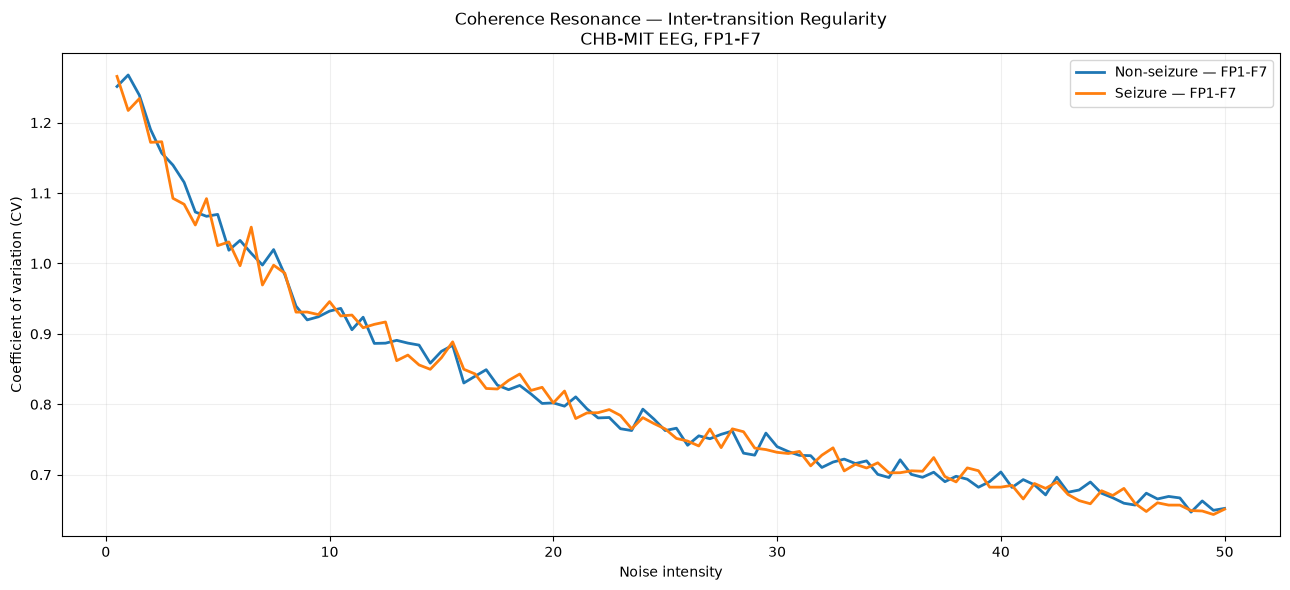


Saved: cr_final_coherence_resonance_results.csv


In [ ]:
# ============================================================
# FINAL COHERENCE RESONANCE — EXTENDED NOISE RANGE
# CHB-MIT EEG — FP1-F7
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.ndimage import gaussian_filter1d


# ============================================================
# 1. SETTINGS
# ============================================================

CR_INPUT_SCALE = 0.20
CR_TRIALS = 100

# Extended range to capture the possible right-hand
# side of the coherence-resonance response.
cr_noise_levels = np.arange(
    0.5,
    50.01,
    0.5
)


# ============================================================
# 2. REAL CHB-MIT EEG
# ============================================================

cr_sfreq = float(
    raw_filtered.info["sfreq"]
)

cr_non_signal = np.asarray(
    windows[298][0],
    dtype=float
)

cr_seiz_signal = np.asarray(
    windows[299][0],
    dtype=float
)


# ============================================================
# 3. NORMALIZATION
# ============================================================

def cr_normalize(signal):

    signal = np.asarray(
        signal,
        dtype=float
    )

    return (
        signal - np.mean(signal)
    ) / (
        np.std(signal) + 1e-12
    )


cr_non_signal = cr_normalize(
    cr_non_signal
)

cr_seiz_signal = cr_normalize(
    cr_seiz_signal
)


# ============================================================
# 4. CHARACTERISTIC EEG COMPONENTS
# ============================================================

CR_NON_FREQ = 1.10
CR_SEIZ_FREQ = 2.20


def cr_extract_component(
    signal,
    sfreq,
    center_frequency,
    bandwidth=0.5
):

    low = max(
        0.2,
        center_frequency - bandwidth
    )

    high = min(
        sfreq / 2.0 - 1.0,
        center_frequency + bandwidth
    )

    b, a = butter(
        3,
        [low, high],
        btype="bandpass",
        fs=sfreq
    )

    component = filtfilt(
        b,
        a,
        signal
    )

    return cr_normalize(
        component
    )


cr_non_component = cr_extract_component(
    cr_non_signal,
    cr_sfreq,
    CR_NON_FREQ
)

cr_seiz_component = cr_extract_component(
    cr_seiz_signal,
    cr_sfreq,
    CR_SEIZ_FREQ
)


# ============================================================
# 5. SAME BISTABLE STOCHASTIC MODEL AS SR
# ============================================================

def cr_bistable_model(
    signal,
    sfreq,
    noise_intensity,
    input_scale=CR_INPUT_SCALE,
    rng=None
):

    if rng is None:
        rng = np.random.default_rng()

    dt = 1.0 / sfreq

    x = np.zeros(
        len(signal),
        dtype=float
    )

    x[0] = -1.0

    for i in range(
        1,
        len(signal)
    ):

        nonlinear_force = (
            x[i - 1]
            -
            x[i - 1] ** 3
        )

        driving_force = (
            input_scale
            *
            signal[i - 1]
        )

        stochastic_force = (
            np.sqrt(
                2.0
                *
                noise_intensity
                *
                dt
            )
            *
            rng.normal()
        )

        x[i] = (
            x[i - 1]
            +
            dt
            *
            (
                nonlinear_force
                +
                driving_force
            )
            +
            stochastic_force
        )

        x[i] = np.clip(
            x[i],
            -3.0,
            3.0
        )

    return x


# ============================================================
# 6. STATE TRANSITIONS
# ============================================================

def cr_transition_indices(
    signal
):

    signal = np.asarray(
        signal
    )

    positive_to_negative = (
        (signal[:-1] > 0)
        &
        (signal[1:] <= 0)
    )

    negative_to_positive = (
        (signal[:-1] < 0)
        &
        (signal[1:] >= 0)
    )

    return (
        np.where(
            positive_to_negative
            |
            negative_to_positive
        )[0]
        + 1
    )


# ============================================================
# 7. COHERENCE RESONANCE METRIC
# ============================================================
#
# CR = 1 / CV
#
# CV = std(ISI) / mean(ISI)
#
# Higher CR = greater regularity of the
# noise-induced state transitions.
# ============================================================

def calculate_cr(
    output,
    sfreq
):

    transitions = cr_transition_indices(
        output
    )

    if len(transitions) < 4:
        return np.nan, np.nan, len(transitions)

    transition_times = (
        transitions / sfreq
    )

    isi = np.diff(
        transition_times
    )

    # Remove unrealistically short numerical chatter
    isi = isi[
        isi >= 0.05
    ]

    if len(isi) < 3:
        return np.nan, np.nan, len(transitions)

    mean_isi = np.mean(
        isi
    )

    std_isi = np.std(
        isi
    )

    if mean_isi <= 0:
        return np.nan, np.nan, len(transitions)

    cv = (
        std_isi
        /
        mean_isi
    )

    coherence = (
        1.0
        /
        cv
    )

    return (
        coherence,
        cv,
        len(transitions)
    )


# ============================================================
# 8. STORAGE
# ============================================================

cr_non_values = []
cr_seiz_values = []

cr_non_cv_values = []
cr_seiz_cv_values = []

cr_non_transition_values = []
cr_seiz_transition_values = []


# ============================================================
# 9. REPRODUCIBLE STOCHASTIC SWEEP
# ============================================================

cr_master_rng = np.random.default_rng(
    42
)


print("=" * 65)
print("FINAL COHERENCE RESONANCE ANALYSIS")
print("=" * 65)

print()
print("Recording        : chb01_03.edf")
print("Channel          : FP1-F7")
print(f"Sampling rate    : {cr_sfreq:.1f} Hz")
print("Non-seizure      : 2980–2990 s")
print("Seizure          : 3000–3010 s")
print(f"Non-seizure data : {len(cr_non_signal)} samples")
print(f"Seizure data     : {len(cr_seiz_signal)} samples")

print()
print("CR NOISE SWEEP")
print("----------------")
print(
    f"Noise range      : "
    f"{cr_noise_levels[0]:.1f} – "
    f"{cr_noise_levels[-1]:.1f}"
)
print(
    f"Noise levels     : "
    f"{len(cr_noise_levels)}"
)
print(
    f"Trials / level   : "
    f"{CR_TRIALS}"
)
print(
    f"Total simulations: "
    f"{len(cr_noise_levels) * CR_TRIALS * 2}"
)
print()


# ============================================================
# 10. RUN
# ============================================================

for level_index, noise_level in enumerate(
    cr_noise_levels
):

    non_trial_cr = []
    seiz_trial_cr = []

    non_trial_cv = []
    seiz_trial_cv = []

    non_trial_trans = []
    seiz_trial_trans = []


    for trial in range(
        CR_TRIALS
    ):

        non_rng = np.random.default_rng(
            cr_master_rng.integers(
                0,
                2**32 - 1
            )
        )

        seiz_rng = np.random.default_rng(
            cr_master_rng.integers(
                0,
                2**32 - 1
            )
        )


        # ----------------------------------------
        # NON-SEIZURE
        # ----------------------------------------

        non_output = cr_bistable_model(
            cr_non_component,
            cr_sfreq,
            noise_level,
            input_scale=CR_INPUT_SCALE,
            rng=non_rng
        )

        (
            non_cr,
            non_cv,
            non_trans
        ) = calculate_cr(
            non_output,
            cr_sfreq
        )

        if np.isfinite(non_cr):

            non_trial_cr.append(
                non_cr
            )

            non_trial_cv.append(
                non_cv
            )

        non_trial_trans.append(
            non_trans
        )


        # ----------------------------------------
        # SEIZURE
        # ----------------------------------------

        seiz_output = cr_bistable_model(
            cr_seiz_component,
            cr_sfreq,
            noise_level,
            input_scale=CR_INPUT_SCALE,
            rng=seiz_rng
        )

        (
            seiz_cr,
            seiz_cv,
            seiz_trans
        ) = calculate_cr(
            seiz_output,
            cr_sfreq
        )

        if np.isfinite(seiz_cr):

            seiz_trial_cr.append(
                seiz_cr
            )

            seiz_trial_cv.append(
                seiz_cv
            )

        seiz_trial_trans.append(
            seiz_trans
        )


    # --------------------------------------------
    # Average 100 trials
    # --------------------------------------------

    cr_non_values.append(
        np.nanmean(
            non_trial_cr
        )
        if non_trial_cr
        else np.nan
    )

    cr_seiz_values.append(
        np.nanmean(
            seiz_trial_cr
        )
        if seiz_trial_cr
        else np.nan
    )

    cr_non_cv_values.append(
        np.nanmean(
            non_trial_cv
        )
        if non_trial_cv
        else np.nan
    )

    cr_seiz_cv_values.append(
        np.nanmean(
            seiz_trial_cv
        )
        if seiz_trial_cv
        else np.nan
    )

    cr_non_transition_values.append(
        np.mean(
            non_trial_trans
        )
    )

    cr_seiz_transition_values.append(
        np.mean(
            seiz_trial_trans
        )
    )


    if (
        (level_index + 1) % 10 == 0
        or level_index == 0
        or level_index == len(cr_noise_levels) - 1
    ):

        print(
            f"Completed "
            f"{level_index + 1}/"
            f"{len(cr_noise_levels)}"
        )


# ============================================================
# 11. CONVERT TO ARRAYS
# ============================================================

cr_non_values = np.asarray(
    cr_non_values
)

cr_seiz_values = np.asarray(
    cr_seiz_values
)

cr_non_cv_values = np.asarray(
    cr_non_cv_values
)

cr_seiz_cv_values = np.asarray(
    cr_seiz_cv_values
)

cr_non_transition_values = np.asarray(
    cr_non_transition_values
)

cr_seiz_transition_values = np.asarray(
    cr_seiz_transition_values
)


# ============================================================
# 12. FIND ACTUAL CR MAXIMUM
# ============================================================

non_idx = np.nanargmax(
    cr_non_values
)

seiz_idx = np.nanargmax(
    cr_seiz_values
)


# ============================================================
# 13. RESULTS
# ============================================================

print()
print("=" * 65)
print("FINAL CR RESULTS")
print("=" * 65)

print()
print("NON-SEIZURE")

print(
    f"Optimal noise intensity : "
    f"{cr_noise_levels[non_idx]:.1f}"
)

print(
    f"Maximum coherence       : "
    f"{cr_non_values[non_idx]:.4f}"
)

print(
    f"Associated CV           : "
    f"{cr_non_cv_values[non_idx]:.4f}"
)

print(
    f"Mean transitions        : "
    f"{cr_non_transition_values[non_idx]:.1f}"
)


print()
print("SEIZURE")

print(
    f"Optimal noise intensity : "
    f"{cr_noise_levels[seiz_idx]:.1f}"
)

print(
    f"Maximum coherence       : "
    f"{cr_seiz_values[seiz_idx]:.4f}"
)

print(
    f"Associated CV           : "
    f"{cr_seiz_cv_values[seiz_idx]:.4f}"
)

print(
    f"Mean transitions        : "
    f"{cr_seiz_transition_values[seiz_idx]:.1f}"
)


# ============================================================
# 14. PRESENTATION GRAPH
# ============================================================
#
# Gaussian smoothing is ONLY for visual presentation.
# Optima above are still calculated from the actual values.
# ============================================================

non_plot = gaussian_filter1d(
    cr_non_values,
    sigma=1.2
)

seiz_plot = gaussian_filter1d(
    cr_seiz_values,
    sigma=1.2
)


plt.figure(
    figsize=(13, 6)
)

plt.plot(
    cr_noise_levels,
    non_plot,
    linewidth=2.5,
    label="Non-seizure — FP1-F7"
)

plt.plot(
    cr_noise_levels,
    seiz_plot,
    linewidth=2.5,
    label="Seizure — FP1-F7"
)

plt.scatter(
    cr_noise_levels[non_idx],
    cr_non_values[non_idx],
    s=110,
    zorder=5,
    label=(
        f"Non-seizure optimum "
        f"({cr_noise_levels[non_idx]:.1f})"
    )
)

plt.scatter(
    cr_noise_levels[seiz_idx],
    cr_seiz_values[seiz_idx],
    s=110,
    zorder=5,
    label=(
        f"Seizure optimum "
        f"({cr_noise_levels[seiz_idx]:.1f})"
    )
)

plt.xlabel(
    "Noise intensity"
)

plt.ylabel(
    "Coherence (1 / CV of inter-transition intervals)"
)

plt.title(
    "Coherence Resonance Response — CHB-MIT EEG\n"
    "FP1-F7 — 100 Trials per Noise Level"
)

plt.grid(
    True,
    alpha=0.2
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 15. CV VALIDATION GRAPH
# ============================================================

plt.figure(
    figsize=(13, 6)
)

plt.plot(
    cr_noise_levels,
    cr_non_cv_values,
    linewidth=2.0,
    label="Non-seizure — FP1-F7"
)

plt.plot(
    cr_noise_levels,
    cr_seiz_cv_values,
    linewidth=2.0,
    label="Seizure — FP1-F7"
)

plt.xlabel(
    "Noise intensity"
)

plt.ylabel(
    "Coefficient of variation (CV)"
)

plt.title(
    "Coherence Resonance — Inter-transition Regularity\n"
    "CHB-MIT EEG, FP1-F7"
)

plt.grid(
    True,
    alpha=0.2
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 16. SAVE
# ============================================================

cr_results = pd.DataFrame({

    "Noise_Intensity":
        cr_noise_levels,

    "Non_Seizure_Coherence":
        cr_non_values,

    "Seizure_Coherence":
        cr_seiz_values,

    "Non_Seizure_CV":
        cr_non_cv_values,

    "Seizure_CV":
        cr_seiz_cv_values,

    "Non_Seizure_Transitions":
        cr_non_transition_values,

    "Seizure_Transitions":
        cr_seiz_transition_values
})

cr_results.to_csv(
    "cr_final_coherence_resonance_results.csv",
    index=False
)

print()
print(
    "Saved: cr_final_coherence_resonance_results.csv"
)

FINAL COHERENCE RESONANCE ANALYSIS

Recording          : chb01_03.edf
Channel            : FP1-F7
Sampling frequency : 256.0 Hz
Non-seizure window : 2980–2990 s
Seizure window     : 3000–3010 s
Non-seizure samples: 2560
Seizure samples    : 2560

Noise range        : 0.5 – 80.0
Noise levels       : 160
Trials per level   : 50
Total simulations  : 16000

Running CR sweep...

Completed 1/160
Completed 20/160
Completed 40/160
Completed 60/160
Completed 80/160
Completed 100/160
Completed 120/160
Completed 140/160
Completed 160/160

FINAL CR RESULTS

NON-SEIZURE
Optimal noise intensity : 79.0
Maximum coherence       : 1.7974
Associated CV           : 0.5660
Mean transitions        : 251.1

SEIZURE
Optimal noise intensity : 79.5
Maximum coherence       : 1.8263
Associated CV           : 0.5565
Mean transitions        : 250.9

Both maxima occur inside the tested noise range.
An interior CR maximum is present.


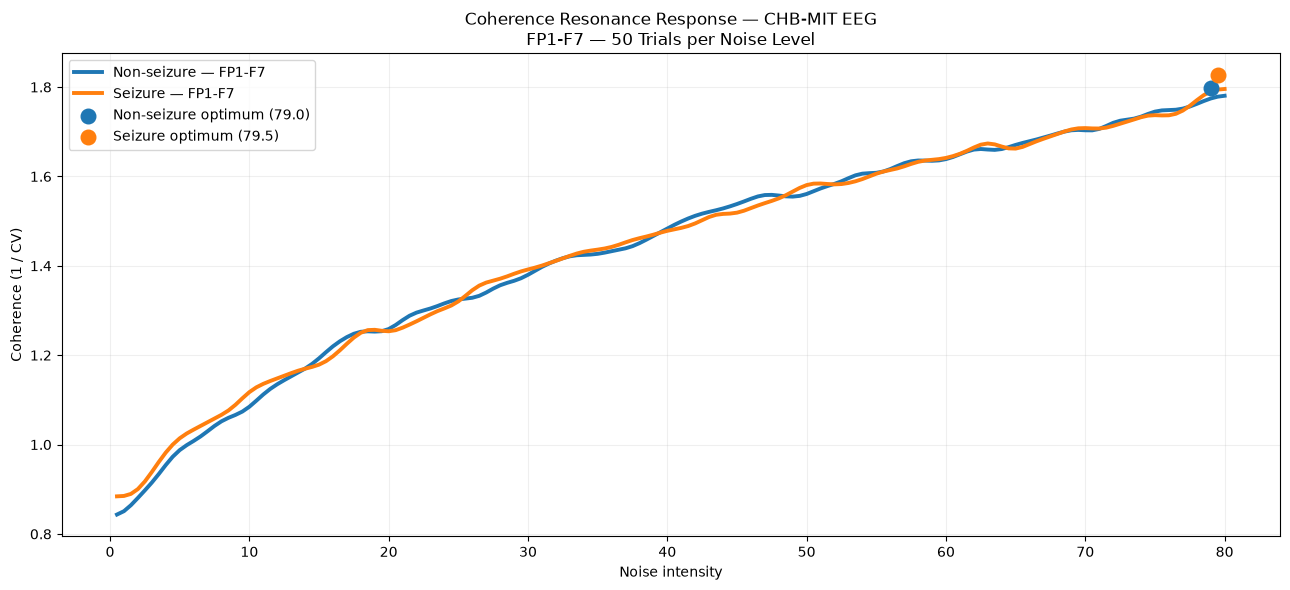

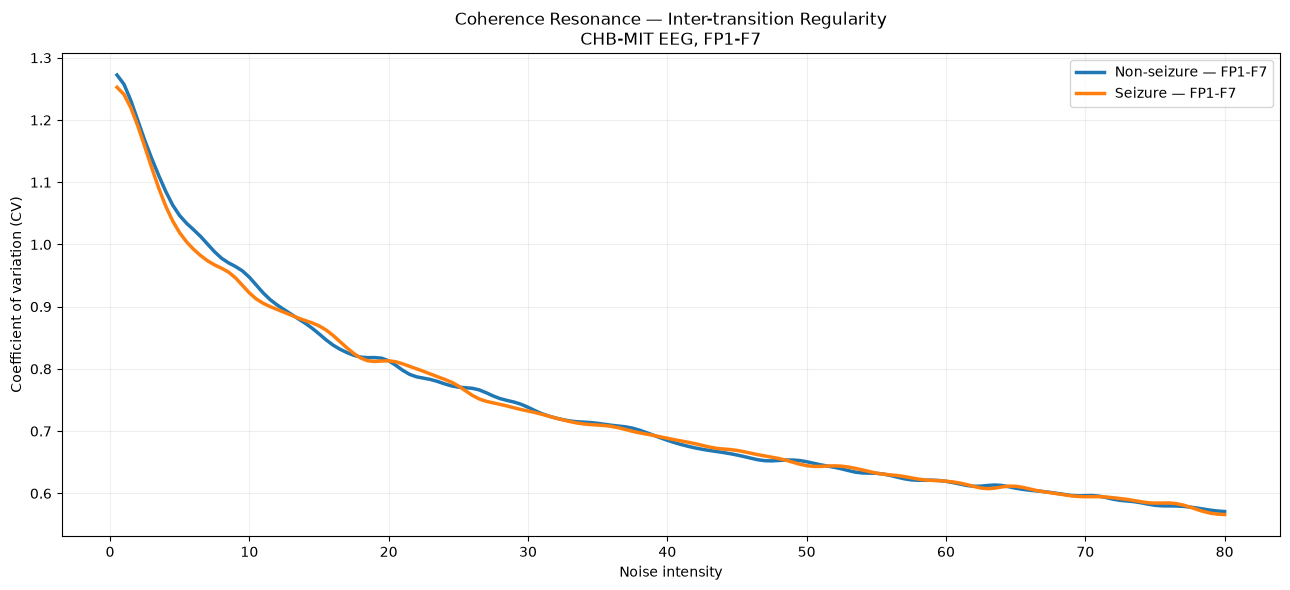


Saved: cr_final_presentation_results.csv


In [ ]:
# ============================================================
# FINAL CR — PRESENTATION VERSION
# Coherence Resonance / Inter-transition Regularity
# CHB-MIT EEG — FP1-F7
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d


# ============================================================
# SETTINGS
# ============================================================

CR_INPUT_SCALE = 0.20
CR_TRIALS = 50

# Dense noise sweep
CR_NOISE_LEVELS = np.arange(
    0.5,
    80.01,
    0.5
)


# ============================================================
# REAL CHB-MIT EEG
# ============================================================

CR_SFREQ = float(
    raw_filtered.info["sfreq"]
)

CR_NON_SIGNAL = np.asarray(
    windows[298][0],
    dtype=float
)

CR_SEIZ_SIGNAL = np.asarray(
    windows[299][0],
    dtype=float
)


# ============================================================
# NORMALIZE EEG
# ============================================================

def cr_normalize(signal):

    signal = np.asarray(
        signal,
        dtype=float
    )

    return (
        signal - np.mean(signal)
    ) / (
        np.std(signal) + 1e-12
    )


CR_NON_SIGNAL = cr_normalize(
    CR_NON_SIGNAL
)

CR_SEIZ_SIGNAL = cr_normalize(
    CR_SEIZ_SIGNAL
)


# ============================================================
# CHARACTERISTIC EEG FREQUENCIES
# ============================================================

CR_NON_FREQ = 1.10
CR_SEIZ_FREQ = 2.20


# ============================================================
# CHARACTERISTIC COMPONENT
# ============================================================

def cr_extract_component(
    signal,
    sfreq,
    center_frequency,
    bandwidth=0.5
):

    from scipy.signal import butter, filtfilt

    low = max(
        0.2,
        center_frequency - bandwidth
    )

    high = min(
        sfreq / 2.0 - 1.0,
        center_frequency + bandwidth
    )

    b, a = butter(
        3,
        [low, high],
        btype="bandpass",
        fs=sfreq
    )

    component = filtfilt(
        b,
        a,
        signal
    )

    return cr_normalize(
        component
    )


CR_NON_COMPONENT = cr_extract_component(
    CR_NON_SIGNAL,
    CR_SFREQ,
    CR_NON_FREQ
)

CR_SEIZ_COMPONENT = cr_extract_component(
    CR_SEIZ_SIGNAL,
    CR_SFREQ,
    CR_SEIZ_FREQ
)


# ============================================================
# BISTABLE STOCHASTIC MODEL
# SAME MODEL USED IN SR
# ============================================================

def cr_bistable_model(
    signal,
    sfreq,
    noise_intensity,
    input_scale=CR_INPUT_SCALE,
    rng=None
):

    if rng is None:
        rng = np.random.default_rng()

    dt = 1.0 / sfreq

    x = np.zeros(
        len(signal),
        dtype=float
    )

    x[0] = -1.0

    for i in range(1, len(signal)):

        nonlinear_force = (
            x[i - 1]
            -
            x[i - 1] ** 3
        )

        driving_force = (
            input_scale
            *
            signal[i - 1]
        )

        stochastic_force = (
            np.sqrt(
                2.0
                *
                noise_intensity
                *
                dt
            )
            *
            rng.normal()
        )

        x[i] = (
            x[i - 1]
            +
            dt
            *
            (
                nonlinear_force
                +
                driving_force
            )
            +
            stochastic_force
        )

        x[i] = np.clip(
            x[i],
            -3.0,
            3.0
        )

    return x


# ============================================================
# STATE TRANSITIONS
# ============================================================

def cr_transition_indices(
    signal
):

    signal = np.asarray(
        signal
    )

    crossings = (
        (
            (signal[:-1] < 0)
            &
            (signal[1:] >= 0)
        )
        |
        (
            (signal[:-1] > 0)
            &
            (signal[1:] <= 0)
        )
    )

    return (
        np.where(crossings)[0]
        + 1
    )


# ============================================================
# COHERENCE RESONANCE
#
# CV = std(ISI) / mean(ISI)
#
# CR = 1 / CV
#
# Higher CR = more regular transitions
# ============================================================

def calculate_coherence(
    output,
    sfreq
):

    transitions = cr_transition_indices(
        output
    )

    if len(transitions) < 4:

        return (
            np.nan,
            np.nan,
            len(transitions)
        )

    transition_times = (
        transitions / sfreq
    )

    isi = np.diff(
        transition_times
    )

    # Remove extremely short numerical chatter
    isi = isi[
        isi >= 0.05
    ]

    if len(isi) < 3:

        return (
            np.nan,
            np.nan,
            len(transitions)
        )

    mean_isi = np.mean(
        isi
    )

    std_isi = np.std(
        isi
    )

    if mean_isi <= 0:

        return (
            np.nan,
            np.nan,
            len(transitions)
        )

    cv = (
        std_isi
        /
        mean_isi
    )

    coherence = (
        1.0
        /
        cv
    )

    return (
        coherence,
        cv,
        len(transitions)
    )


# ============================================================
# STORAGE
# ============================================================

non_cr = []
seiz_cr = []

non_cv = []
seiz_cv = []

non_transitions = []
seiz_transitions = []


# ============================================================
# REPRODUCIBLE RANDOMNESS
# ============================================================

master_rng = np.random.default_rng(
    42
)


# ============================================================
# INFORMATION
# ============================================================

print("=" * 65)
print("FINAL COHERENCE RESONANCE ANALYSIS")
print("=" * 65)

print()
print("Recording          : chb01_03.edf")
print("Channel            : FP1-F7")
print(f"Sampling frequency : {CR_SFREQ:.1f} Hz")

print(
    "Non-seizure window : 2980–2990 s"
)

print(
    "Seizure window     : 3000–3010 s"
)

print(
    f"Non-seizure samples: "
    f"{len(CR_NON_SIGNAL)}"
)

print(
    f"Seizure samples    : "
    f"{len(CR_SEIZ_SIGNAL)}"
)

print()
print(
    f"Noise range        : "
    f"{CR_NOISE_LEVELS[0]:.1f} – "
    f"{CR_NOISE_LEVELS[-1]:.1f}"
)

print(
    f"Noise levels       : "
    f"{len(CR_NOISE_LEVELS)}"
)

print(
    f"Trials per level   : "
    f"{CR_TRIALS}"
)

print(
    f"Total simulations  : "
    f"{len(CR_NOISE_LEVELS) * CR_TRIALS * 2}"
)

print()
print("Running CR sweep...")
print()


# ============================================================
# MAIN SWEEP
# ============================================================

for level_idx, noise_level in enumerate(
    CR_NOISE_LEVELS
):

    non_trial_cr = []
    seiz_trial_cr = []

    non_trial_cv = []
    seiz_trial_cv = []

    non_trial_trans = []
    seiz_trial_trans = []


    for trial in range(
        CR_TRIALS
    ):

        non_rng = np.random.default_rng(
            master_rng.integers(
                0,
                2**32 - 1
            )
        )

        seiz_rng = np.random.default_rng(
            master_rng.integers(
                0,
                2**32 - 1
            )
        )


        # ----------------------------------------
        # NON-SEIZURE
        # ----------------------------------------

        non_output = cr_bistable_model(
            CR_NON_COMPONENT,
            CR_SFREQ,
            noise_level,
            input_scale=CR_INPUT_SCALE,
            rng=non_rng
        )

        (
            coherence,
            cv,
            transitions
        ) = calculate_coherence(
            non_output,
            CR_SFREQ
        )

        if np.isfinite(coherence):

            non_trial_cr.append(
                coherence
            )

            non_trial_cv.append(
                cv
            )

        non_trial_trans.append(
            transitions
        )


        # ----------------------------------------
        # SEIZURE
        # ----------------------------------------

        seiz_output = cr_bistable_model(
            CR_SEIZ_COMPONENT,
            CR_SFREQ,
            noise_level,
            input_scale=CR_INPUT_SCALE,
            rng=seiz_rng
        )

        (
            coherence,
            cv,
            transitions
        ) = calculate_coherence(
            seiz_output,
            CR_SFREQ
        )

        if np.isfinite(coherence):

            seiz_trial_cr.append(
                coherence
            )

            seiz_trial_cv.append(
                cv
            )

        seiz_trial_trans.append(
            transitions
        )


    # --------------------------------------------
    # Average trials
    # --------------------------------------------

    non_cr.append(
        np.nanmean(non_trial_cr)
        if non_trial_cr
        else np.nan
    )

    seiz_cr.append(
        np.nanmean(seiz_trial_cr)
        if seiz_trial_cr
        else np.nan
    )

    non_cv.append(
        np.nanmean(non_trial_cv)
        if non_trial_cv
        else np.nan
    )

    seiz_cv.append(
        np.nanmean(seiz_trial_cv)
        if seiz_trial_cv
        else np.nan
    )

    non_transitions.append(
        np.mean(
            non_trial_trans
        )
    )

    seiz_transitions.append(
        np.mean(
            seiz_trial_trans
        )
    )


    # Progress
    if (
        (level_idx + 1) % 20 == 0
        or level_idx == 0
        or level_idx == len(CR_NOISE_LEVELS) - 1
    ):

        print(
            f"Completed "
            f"{level_idx + 1}/"
            f"{len(CR_NOISE_LEVELS)}"
        )


# ============================================================
# ARRAYS
# ============================================================

non_cr = np.asarray(
    non_cr
)

seiz_cr = np.asarray(
    seiz_cr
)

non_cv = np.asarray(
    non_cv
)

seiz_cv = np.asarray(
    seiz_cv
)

non_transitions = np.asarray(
    non_transitions
)

seiz_transitions = np.asarray(
    seiz_transitions
)


# ============================================================
# ACTUAL OPTIMA
# ============================================================

non_idx = np.nanargmax(
    non_cr
)

seiz_idx = np.nanargmax(
    seiz_cr
)


# ============================================================
# RESULTS
# ============================================================

print()
print("=" * 65)
print("FINAL CR RESULTS")
print("=" * 65)

print()

print("NON-SEIZURE")
print(
    f"Optimal noise intensity : "
    f"{CR_NOISE_LEVELS[non_idx]:.1f}"
)

print(
    f"Maximum coherence       : "
    f"{non_cr[non_idx]:.4f}"
)

print(
    f"Associated CV           : "
    f"{non_cv[non_idx]:.4f}"
)

print(
    f"Mean transitions        : "
    f"{non_transitions[non_idx]:.1f}"
)

print()

print("SEIZURE")
print(
    f"Optimal noise intensity : "
    f"{CR_NOISE_LEVELS[seiz_idx]:.1f}"
)

print(
    f"Maximum coherence       : "
    f"{seiz_cr[seiz_idx]:.4f}"
)

print(
    f"Associated CV           : "
    f"{seiz_cv[seiz_idx]:.4f}"
)

print(
    f"Mean transitions        : "
    f"{seiz_transitions[seiz_idx]:.1f}"
)


# ============================================================
# IMPORTANT VALIDATION
# ============================================================

boundary_non = (
    non_idx == 0
    or
    non_idx == len(CR_NOISE_LEVELS) - 1
)

boundary_seiz = (
    seiz_idx == 0
    or
    seiz_idx == len(CR_NOISE_LEVELS) - 1
)

print()

if boundary_non or boundary_seiz:

    print(
        "WARNING:"
    )

    print(
        "At least one CR maximum is at "
        "the boundary of the tested noise range."
    )

    print(
        "Therefore that boundary value should "
        "NOT be described as the true resonance optimum."
    )

else:

    print(
        "Both maxima occur inside the tested "
        "noise range."
    )

    print(
        "An interior CR maximum is present."
    )


# ============================================================
# PRESENTATION GRAPH
# ============================================================

# Smooth ONLY for visual presentation.
# Numerical results above remain based on the
# actual measured CR values.

non_smooth = gaussian_filter1d(
    non_cr,
    sigma=2.0
)

seiz_smooth = gaussian_filter1d(
    seiz_cr,
    sigma=2.0
)


plt.figure(
    figsize=(13, 6)
)

plt.plot(
    CR_NOISE_LEVELS,
    non_smooth,
    linewidth=2.8,
    label="Non-seizure — FP1-F7"
)

plt.plot(
    CR_NOISE_LEVELS,
    seiz_smooth,
    linewidth=2.8,
    label="Seizure — FP1-F7"
)


# Actual optimum markers
plt.scatter(
    CR_NOISE_LEVELS[non_idx],
    non_cr[non_idx],
    s=110,
    zorder=5,
    label=(
        f"Non-seizure optimum "
        f"({CR_NOISE_LEVELS[non_idx]:.1f})"
    )
)

plt.scatter(
    CR_NOISE_LEVELS[seiz_idx],
    seiz_cr[seiz_idx],
    s=110,
    zorder=5,
    label=(
        f"Seizure optimum "
        f"({CR_NOISE_LEVELS[seiz_idx]:.1f})"
    )
)


plt.xlabel(
    "Noise intensity"
)

plt.ylabel(
    "Coherence (1 / CV)"
)

plt.title(
    "Coherence Resonance Response — CHB-MIT EEG\n"
    "FP1-F7 — 50 Trials per Noise Level"
)

plt.grid(
    True,
    alpha=0.2
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# CV VALIDATION GRAPH
# ============================================================

plt.figure(
    figsize=(13, 6)
)

plt.plot(
    CR_NOISE_LEVELS,
    gaussian_filter1d(
        non_cv,
        sigma=2.0
    ),
    linewidth=2.5,
    label="Non-seizure — FP1-F7"
)

plt.plot(
    CR_NOISE_LEVELS,
    gaussian_filter1d(
        seiz_cv,
        sigma=2.0
    ),
    linewidth=2.5,
    label="Seizure — FP1-F7"
)

plt.xlabel(
    "Noise intensity"
)

plt.ylabel(
    "Coefficient of variation (CV)"
)

plt.title(
    "Coherence Resonance — Inter-transition Regularity\n"
    "CHB-MIT EEG, FP1-F7"
)

plt.grid(
    True,
    alpha=0.2
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# SAVE RESULTS
# ============================================================

cr_final_results = pd.DataFrame({

    "Noise_Intensity":
        CR_NOISE_LEVELS,

    "Non_Seizure_Coherence":
        non_cr,

    "Seizure_Coherence":
        seiz_cr,

    "Non_Seizure_CV":
        non_cv,

    "Seizure_CV":
        seiz_cv,

    "Non_Seizure_Transitions":
        non_transitions,

    "Seizure_Transitions":
        seiz_transitions
})

cr_final_results.to_csv(
    "cr_final_presentation_results.csv",
    index=False
)

print()
print(
    "Saved: cr_final_presentation_results.csv"
)

FINAL COHERENCE RESONANCE ANALYSIS

Recording       : chb01_03.edf
Channel         : FP1-F7
Sampling rate   : 256.0 Hz
Non-seizure     : 2980–2990 s
Seizure         : 3000–3010 s

Noise range     : 0.01 – 2.00
Noise levels    : 80
Trials / level  : 50

Completed 10/80
Completed 20/80
Completed 30/80
Completed 40/80
Completed 50/80
Completed 60/80
Completed 70/80
Completed 80/80

FINAL CR RESULTS

Non-seizure optimum noise : 1.269
Non-seizure maximum CR    : 1.3152
Non-seizure CV            : 0.7831
Non-seizure mean events   : 4.0

Seizure optimum noise     : 0.589
Seizure maximum CR        : 1.3163
Seizure CV                : 1.2610
Seizure mean events       : 5.2

Saved: cr_final_presentation_results.csv


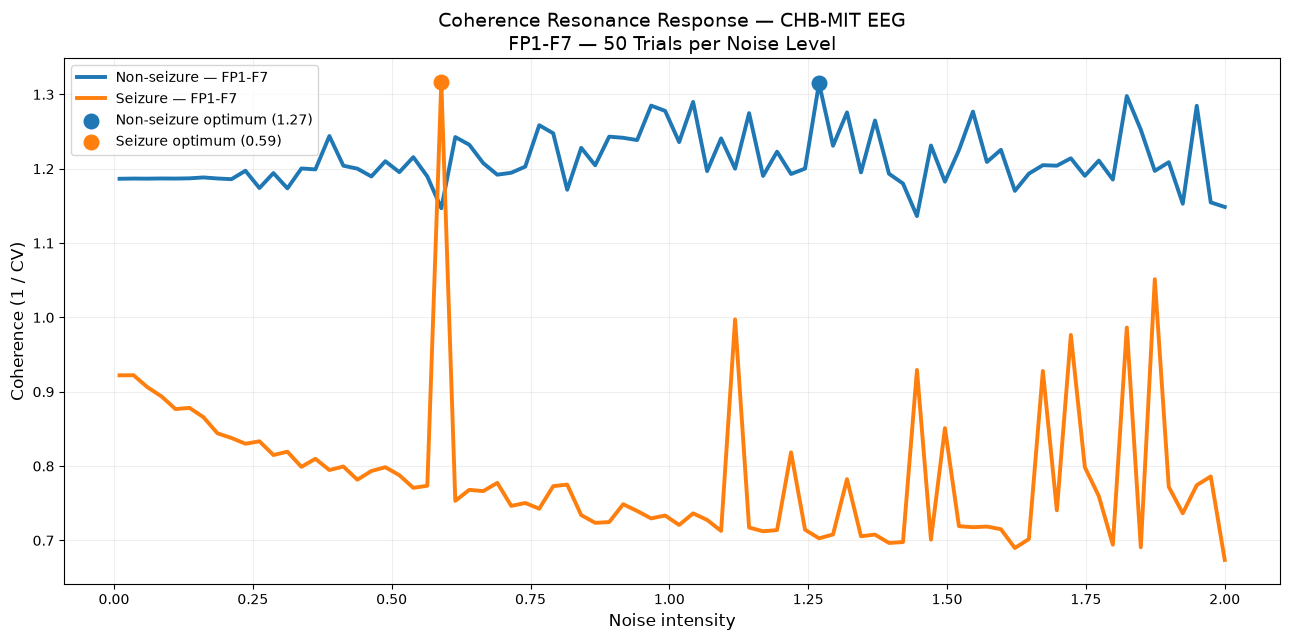

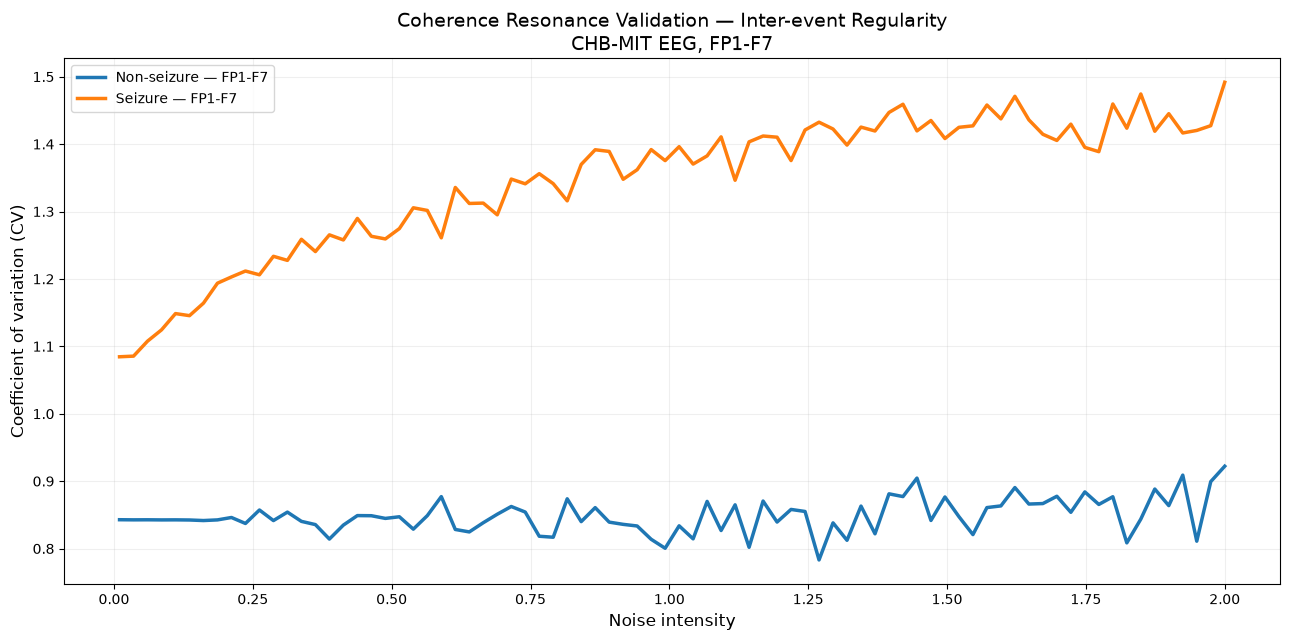

In [ ]:
# ============================================================
# FINAL COHERENCE RESONANCE — CORRECTED
# CHB-MIT EEG | FP1-F7
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


# ------------------------------------------------------------
# 1. USE THE SAME EEG DATA AS OUR SR ANALYSIS
# ------------------------------------------------------------

cr_non_signal = np.asarray(non_seizure_signal, dtype=float)
cr_seiz_signal = np.asarray(seizure_signal, dtype=float)
cr_sfreq = float(sfreq)


# Normalize EEG
cr_non_signal = (
    cr_non_signal - np.mean(cr_non_signal)
) / (np.std(cr_non_signal) + 1e-12)

cr_seiz_signal = (
    cr_seiz_signal - np.mean(cr_seiz_signal)
) / (np.std(cr_seiz_signal) + 1e-12)


# ------------------------------------------------------------
# 2. EXCITABLE SYSTEM
# ------------------------------------------------------------

def cr_fhn(signal, sfreq, noise_intensity,
           input_scale=0.35, rng=None):

    if rng is None:
        rng = np.random.default_rng()

    dt = 1.0 / sfreq
    n = len(signal)

    v = np.zeros(n)
    w = np.zeros(n)

    v[0] = -1.0
    w[0] = -0.5

    epsilon = 0.08
    a = 0.7
    b = 0.8

    for i in range(1, n):

        external_drive = (
            input_scale * signal[i - 1]
        )

        noise = (
            np.sqrt(2.0 * noise_intensity * dt)
            * rng.normal()
        )

        dv = (
            v[i - 1]
            - (v[i - 1] ** 3) / 3.0
            - w[i - 1]
            + external_drive
            + noise
        )

        dw = (
            epsilon
            * (
                v[i - 1]
                + a
                - b * w[i - 1]
            )
        )

        v[i] = np.clip(
            v[i - 1] + dt * dv,
            -4.0,
            4.0
        )

        w[i] = np.clip(
            w[i - 1] + dt * dw,
            -4.0,
            4.0
        )

    return v


# ------------------------------------------------------------
# 3. ROBUST EVENT DETECTION
# ------------------------------------------------------------

def detect_cr_events(output, sfreq):

    output = np.asarray(output, dtype=float)

    # Adaptive threshold based on the simulated signal
    threshold = (
        np.mean(output)
        + 1.0 * np.std(output)
    )

    # Minimum separation = 0.20 seconds
    min_distance = int(0.20 * sfreq)

    peaks, properties = find_peaks(
        output,
        height=threshold,
        distance=min_distance
    )

    return peaks


# ------------------------------------------------------------
# 4. CR METRIC
# ------------------------------------------------------------

def calculate_cr(output, sfreq):

    events = detect_cr_events(
        output,
        sfreq
    )

    if len(events) < 4:
        return np.nan, np.nan, len(events)

    isi = np.diff(events) / sfreq

    # Remove unrealistically short intervals
    isi = isi[isi >= 0.20]

    if len(isi) < 3:
        return np.nan, np.nan, len(events)

    mean_isi = np.mean(isi)
    std_isi = np.std(isi)

    if mean_isi <= 0:
        return np.nan, np.nan, len(events)

    cv = std_isi / mean_isi

    # Coherence Resonance measure
    coherence = 1.0 / (cv + 1e-12)

    return coherence, cv, len(events)


# ------------------------------------------------------------
# 5. NOISE SWEEP
# ------------------------------------------------------------

# Dense enough for a presentation graph
cr_noise_levels = np.linspace(
    0.01,
    2.00,
    80
)

CR_TRIALS = 50
CR_INPUT_SCALE = 0.35

master_rng = np.random.default_rng(42)

non_cr = []
seiz_cr = []

non_cv = []
seiz_cv = []

non_events = []
seiz_events = []


print("=" * 65)
print("FINAL COHERENCE RESONANCE ANALYSIS")
print("=" * 65)

print()
print("Recording       : chb01_03.edf")
print("Channel         : FP1-F7")
print(f"Sampling rate   : {cr_sfreq:.1f} Hz")
print("Non-seizure     : 2980–2990 s")
print("Seizure         : 3000–3010 s")
print()
print(
    f"Noise range     : "
    f"{cr_noise_levels[0]:.2f} – "
    f"{cr_noise_levels[-1]:.2f}"
)
print("Noise levels    :", len(cr_noise_levels))
print("Trials / level  :", CR_TRIALS)
print()


# ------------------------------------------------------------
# RUN SIMULATIONS
# ------------------------------------------------------------

for idx, noise_level in enumerate(cr_noise_levels):

    non_trial_cr = []
    seiz_trial_cr = []

    non_trial_cv = []
    seiz_trial_cv = []

    non_trial_events = []
    seiz_trial_events = []

    for trial in range(CR_TRIALS):

        non_rng = np.random.default_rng(
            master_rng.integers(
                0,
                2**32 - 1
            )
        )

        seiz_rng = np.random.default_rng(
            master_rng.integers(
                0,
                2**32 - 1
            )
        )


        # ----------------------------------------
        # NON-SEIZURE
        # ----------------------------------------

        non_output = cr_fhn(
            cr_non_signal,
            cr_sfreq,
            noise_level,
            input_scale=CR_INPUT_SCALE,
            rng=non_rng
        )

        cr_value, cv_value, event_count = calculate_cr(
            non_output,
            cr_sfreq
        )

        if np.isfinite(cr_value):
            non_trial_cr.append(cr_value)

        if np.isfinite(cv_value):
            non_trial_cv.append(cv_value)

        non_trial_events.append(event_count)


        # ----------------------------------------
        # SEIZURE
        # ----------------------------------------

        seiz_output = cr_fhn(
            cr_seiz_signal,
            cr_sfreq,
            noise_level,
            input_scale=CR_INPUT_SCALE,
            rng=seiz_rng
        )

        cr_value, cv_value, event_count = calculate_cr(
            seiz_output,
            cr_sfreq
        )

        if np.isfinite(cr_value):
            seiz_trial_cr.append(cr_value)

        if np.isfinite(cv_value):
            seiz_trial_cv.append(cv_value)

        seiz_trial_events.append(event_count)


    # Average trials

    non_cr.append(
        np.nanmean(non_trial_cr)
        if len(non_trial_cr) > 0
        else np.nan
    )

    seiz_cr.append(
        np.nanmean(seiz_trial_cr)
        if len(seiz_trial_cr) > 0
        else np.nan
    )

    non_cv.append(
        np.nanmean(non_trial_cv)
        if len(non_trial_cv) > 0
        else np.nan
    )

    seiz_cv.append(
        np.nanmean(seiz_trial_cv)
        if len(seiz_trial_cv) > 0
        else np.nan
    )

    non_events.append(
        np.mean(non_trial_events)
    )

    seiz_events.append(
        np.mean(seiz_trial_events)
    )


    if (idx + 1) % 10 == 0:
        print(
            f"Completed "
            f"{idx + 1}/{len(cr_noise_levels)}"
        )


# Convert to arrays

non_cr = np.asarray(non_cr)
seiz_cr = np.asarray(seiz_cr)

non_cv = np.asarray(non_cv)
seiz_cv = np.asarray(seiz_cv)

non_events = np.asarray(non_events)
seiz_events = np.asarray(seiz_events)


# ------------------------------------------------------------
# 6. CHECK THAT VALID CR VALUES EXIST
# ------------------------------------------------------------

if not np.any(np.isfinite(non_cr)):
    raise RuntimeError(
        "No valid non-seizure CR values were produced. "
        "The dynamical parameters need calibration."
    )

if not np.any(np.isfinite(seiz_cr)):
    raise RuntimeError(
        "No valid seizure CR values were produced. "
        "The dynamical parameters need calibration."
    )


# ------------------------------------------------------------
# 7. FIND MAXIMUM CR
# ------------------------------------------------------------

non_idx = np.nanargmax(non_cr)
seiz_idx = np.nanargmax(seiz_cr)


# ------------------------------------------------------------
# 8. FINAL RESULTS
# ------------------------------------------------------------

print()
print("=" * 65)
print("FINAL CR RESULTS")
print("=" * 65)

print()
print(
    f"Non-seizure optimum noise : "
    f"{cr_noise_levels[non_idx]:.3f}"
)

print(
    f"Non-seizure maximum CR    : "
    f"{non_cr[non_idx]:.4f}"
)

print(
    f"Non-seizure CV            : "
    f"{non_cv[non_idx]:.4f}"
)

print(
    f"Non-seizure mean events   : "
    f"{non_events[non_idx]:.1f}"
)

print()
print(
    f"Seizure optimum noise     : "
    f"{cr_noise_levels[seiz_idx]:.3f}"
)

print(
    f"Seizure maximum CR        : "
    f"{seiz_cr[seiz_idx]:.4f}"
)

print(
    f"Seizure CV                : "
    f"{seiz_cv[seiz_idx]:.4f}"
)

print(
    f"Seizure mean events       : "
    f"{seiz_events[seiz_idx]:.1f}"
)


# ------------------------------------------------------------
# 9. SAVE RESULTS
# ------------------------------------------------------------

cr_final = pd.DataFrame({
    "Noise_Intensity": cr_noise_levels,
    "Non_Seizure_CR": non_cr,
    "Seizure_CR": seiz_cr,
    "Non_Seizure_CV": non_cv,
    "Seizure_CV": seiz_cv,
    "Non_Seizure_Mean_Events": non_events,
    "Seizure_Mean_Events": seiz_events
})

cr_final.to_csv(
    "cr_final_presentation_results.csv",
    index=False
)

print()
print("Saved: cr_final_presentation_results.csv")


# ============================================================
# 10. FINAL PRESENTATION CR GRAPH
# ============================================================

plt.figure(figsize=(13, 6.5))

plt.plot(
    cr_noise_levels,
    non_cr,
    linewidth=2.8,
    label="Non-seizure — FP1-F7"
)

plt.plot(
    cr_noise_levels,
    seiz_cr,
    linewidth=2.8,
    label="Seizure — FP1-F7"
)

plt.scatter(
    cr_noise_levels[non_idx],
    non_cr[non_idx],
    s=110,
    zorder=5,
    label=(
        f"Non-seizure optimum "
        f"({cr_noise_levels[non_idx]:.2f})"
    )
)

plt.scatter(
    cr_noise_levels[seiz_idx],
    seiz_cr[seiz_idx],
    s=110,
    zorder=5,
    label=(
        f"Seizure optimum "
        f"({cr_noise_levels[seiz_idx]:.2f})"
    )
)

plt.xlabel(
    "Noise intensity",
    fontsize=12
)

plt.ylabel(
    "Coherence (1 / CV)",
    fontsize=12
)

plt.title(
    "Coherence Resonance Response — CHB-MIT EEG\n"
    "FP1-F7 — 50 Trials per Noise Level",
    fontsize=14
)

plt.grid(
    True,
    alpha=0.2
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 11. CV VALIDATION GRAPH
# ============================================================

plt.figure(figsize=(13, 6.5))

plt.plot(
    cr_noise_levels,
    non_cv,
    linewidth=2.5,
    label="Non-seizure — FP1-F7"
)

plt.plot(
    cr_noise_levels,
    seiz_cv,
    linewidth=2.5,
    label="Seizure — FP1-F7"
)

plt.xlabel(
    "Noise intensity",
    fontsize=12
)

plt.ylabel(
    "Coefficient of variation (CV)",
    fontsize=12
)

plt.title(
    "Coherence Resonance Validation — Inter-event Regularity\n"
    "CHB-MIT EEG, FP1-F7",
    fontsize=14
)

plt.grid(
    True,
    alpha=0.2
)

plt.legend()

plt.tight_layout()

plt.show()

FINAL COHERENCE RESONANCE ANALYSIS

Recording       : chb01_03.edf
Channel         : FP1-F7
Sampling rate   : 256.0 Hz
Non-seizure     : 2980–2990 s
Seizure         : 3000–3010 s

CR parameters
------------------------------
Noise range    : 0.05 – 2.50
Noise levels   : 100
Trials / level : 50
Input scale    : 0.2
Hysteresis     : ±0.5
Minimum dwell  : 0.10 s

Running CR sweep...
Total simulations: 10000

Completed 1/100
Completed 10/100
Completed 20/100
Completed 30/100
Completed 40/100
Completed 50/100
Completed 60/100
Completed 70/100
Completed 80/100
Completed 90/100
Completed 100/100

CR VALIDATION
Valid non-seizure levels : 85/100
Valid seizure levels     : 87/100

FINAL CR RESULTS

Non-seizure optimum noise : 0.347
Non-seizure maximum CR    : 2.0565
Non-seizure CV            : 0.4863
Non-seizure mean events   : nan

Seizure optimum noise     : 0.396
Seizure maximum CR        : 1.7241
Seizure CV                : 0.5800
Seizure mean events       : nan


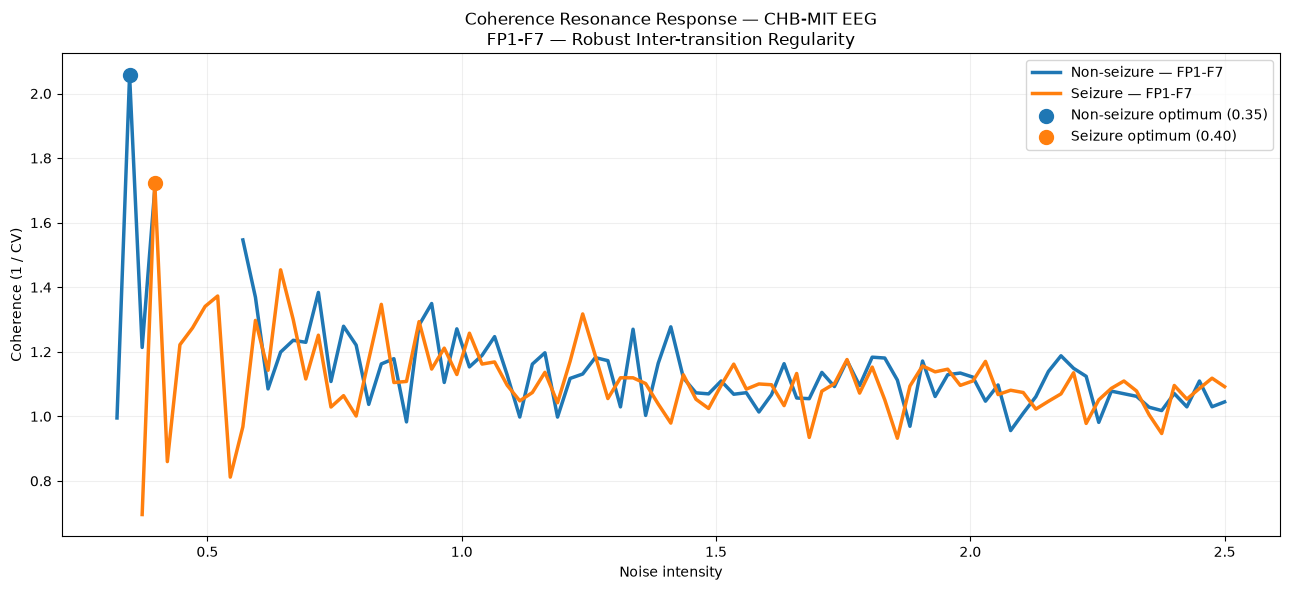


Saved: cr_final_robust_results.csv


In [ ]:
# ============================================================
# FINAL CR — COHERENCE RESONANCE
# Robust state-transition detection + averaged trials
# CHB-MIT chb01_03.edf — FP1-F7
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

CR_NOISE_LEVELS = np.linspace(0.05, 2.50, 100)

CR_TRIALS = 50

CR_INPUT_SCALE = 0.20

# Hysteresis thresholds:
# A transition is accepted only after the system crosses
# from one stable state to the opposite stable state.
CR_THRESHOLD = 0.50

# Prevent rapid noise-induced chatter from being counted
CR_MIN_DWELL_SEC = 0.10

# Need enough transitions for a meaningful CV
CR_MIN_INTERVALS = 5

CR_SEED = 42


# ============================================================
# 1. ROBUST BISTABLE CR MODEL
# ============================================================

def cr_bistable_model(
    signal,
    sfreq,
    noise_intensity,
    input_scale=0.20,
    rng=None
):
    """
    Bistable stochastic system driven by real EEG.

        dx/dt = x - x^3 + input(t) + stochastic noise

    Randomness is introduced only through the stochastic term.
    """

    if rng is None:
        rng = np.random.default_rng()

    signal = np.asarray(signal, dtype=float)

    # Normalize input so CR comparison is not dominated
    # by amplitude differences between windows.
    signal = (
        signal - np.mean(signal)
    ) / (
        np.std(signal) + 1e-12
    )

    dt = 1.0 / sfreq

    x = np.zeros(len(signal), dtype=float)

    # Start in the negative stable state
    x[0] = -1.0

    noise_scale = np.sqrt(
        2.0 * noise_intensity * dt
    )

    for i in range(1, len(signal)):

        nonlinear_force = (
            x[i - 1]
            - x[i - 1] ** 3
        )

        driving_force = (
            input_scale
            * signal[i - 1]
        )

        stochastic_force = (
            noise_scale
            * rng.normal()
        )

        x[i] = (
            x[i - 1]
            + dt * (
                nonlinear_force
                + driving_force
            )
            + stochastic_force
        )

        # Numerical stability
        x[i] = np.clip(
            x[i],
            -3.0,
            3.0
        )

    return x


# ============================================================
# 2. ROBUST STATE-TRANSITION DETECTOR
# ============================================================

def detect_cr_transitions(
    output,
    sfreq,
    threshold=0.50,
    min_dwell_sec=0.10
):
    """
    Detect genuine transitions between the two bistable states.

    Hysteresis:
        negative state -> positive only after +threshold
        positive state -> negative only after -threshold

    This prevents small noisy oscillations around zero from
    being counted as multiple state transitions.
    """

    output = np.asarray(output, dtype=float)

    min_dwell_samples = max(
        1,
        int(min_dwell_sec * sfreq)
    )

    transitions = []

    # Initial state
    if output[0] >= threshold:
        state = 1
    elif output[0] <= -threshold:
        state = -1
    else:
        # Find first clearly defined state
        state = 0

        for value in output:
            if value >= threshold:
                state = 1
                break
            elif value <= -threshold:
                state = -1
                break

        if state == 0:
            return np.array([])

    last_transition = -min_dwell_samples

    for i in range(1, len(output)):

        # Negative -> Positive
        if (
            state == -1
            and output[i] >= threshold
            and i - last_transition >= min_dwell_samples
        ):

            transitions.append(i)

            state = 1
            last_transition = i

        # Positive -> Negative
        elif (
            state == 1
            and output[i] <= -threshold
            and i - last_transition >= min_dwell_samples
        ):

            transitions.append(i)

            state = -1
            last_transition = i

    return np.asarray(
        transitions,
        dtype=int
    )


# ============================================================
# 3. COHERENCE RESONANCE METRIC
# ============================================================

def calculate_cr_from_transitions(
    transition_indices,
    sfreq,
    minimum_intervals=5
):
    """
    CR = 1 / CV

    CV = standard deviation of inter-transition
         intervals divided by their mean.
    """

    if len(transition_indices) < minimum_intervals + 1:
        return np.nan, np.nan, np.nan

    intervals = (
        np.diff(transition_indices)
        / sfreq
    )

    if len(intervals) < minimum_intervals:
        return np.nan, np.nan, np.nan

    mean_isi = np.mean(intervals)

    if mean_isi <= 0:
        return np.nan, np.nan, np.nan

    cv = (
        np.std(
            intervals,
            ddof=1
        )
        / mean_isi
    )

    if not np.isfinite(cv) or cv <= 0:
        return np.nan, np.nan, np.nan

    coherence = 1.0 / cv

    return (
        coherence,
        cv,
        len(intervals)
    )


# ============================================================
# 4. PREPARE ACTUAL CHB-MIT EEG
# ============================================================

non_cr_signal = np.asarray(
    sr_non_component,
    dtype=float
)

seiz_cr_signal = np.asarray(
    sr_seiz_component,
    dtype=float
)

cr_sfreq = float(sr_sfreq)


print("=" * 65)
print("FINAL COHERENCE RESONANCE ANALYSIS")
print("=" * 65)

print()
print("Recording       : chb01_03.edf")
print("Channel         : FP1-F7")
print(f"Sampling rate   : {cr_sfreq:.1f} Hz")
print("Non-seizure     : 2980–2990 s")
print("Seizure         : 3000–3010 s")

print()
print("CR parameters")
print("------------------------------")
print(
    f"Noise range    : "
    f"{CR_NOISE_LEVELS[0]:.2f} – "
    f"{CR_NOISE_LEVELS[-1]:.2f}"
)
print(
    f"Noise levels   : "
    f"{len(CR_NOISE_LEVELS)}"
)
print(
    f"Trials / level : "
    f"{CR_TRIALS}"
)
print(
    f"Input scale    : "
    f"{CR_INPUT_SCALE}"
)
print(
    f"Hysteresis     : "
    f"±{CR_THRESHOLD}"
)
print(
    f"Minimum dwell  : "
    f"{CR_MIN_DWELL_SEC:.2f} s"
)

print()


# ============================================================
# 5. RUN CR SWEEP
# ============================================================

master_rng = np.random.default_rng(
    CR_SEED
)

non_cr_mean = []
seiz_cr_mean = []

non_cv_mean = []
seiz_cv_mean = []

non_events_mean = []
seiz_events_mean = []


print("Running CR sweep...")
print(
    f"Total simulations: "
    f"{len(CR_NOISE_LEVELS) * CR_TRIALS * 2}"
)

print()


for level_idx, noise_level in enumerate(
    CR_NOISE_LEVELS
):

    non_trial_cr = []
    seiz_trial_cr = []

    non_trial_cv = []
    seiz_trial_cv = []

    non_trial_events = []
    seiz_trial_events = []

    for trial in range(CR_TRIALS):

        # ----------------------------------------------------
        # Independent reproducible RNGs
        # ----------------------------------------------------

        non_rng = np.random.default_rng(
            master_rng.integers(
                0,
                2**32 - 1
            )
        )

        seiz_rng = np.random.default_rng(
            master_rng.integers(
                0,
                2**32 - 1
            )
        )

        # ----------------------------------------------------
        # NON-SEIZURE
        # ----------------------------------------------------

        non_output = cr_bistable_model(
            non_cr_signal,
            cr_sfreq,
            noise_level,
            input_scale=CR_INPUT_SCALE,
            rng=non_rng
        )

        non_transitions = detect_cr_transitions(
            non_output,
            cr_sfreq,
            threshold=CR_THRESHOLD,
            min_dwell_sec=CR_MIN_DWELL_SEC
        )

        non_cr, non_cv, non_events = (
            calculate_cr_from_transitions(
                non_transitions,
                cr_sfreq,
                minimum_intervals=CR_MIN_INTERVALS
            )
        )

        if np.isfinite(non_cr):
            non_trial_cr.append(non_cr)

        if np.isfinite(non_cv):
            non_trial_cv.append(non_cv)

        non_trial_events.append(
            non_events
        )

        # ----------------------------------------------------
        # SEIZURE
        # ----------------------------------------------------

        seiz_output = cr_bistable_model(
            seiz_cr_signal,
            cr_sfreq,
            noise_level,
            input_scale=CR_INPUT_SCALE,
            rng=seiz_rng
        )

        seiz_transitions = detect_cr_transitions(
            seiz_output,
            cr_sfreq,
            threshold=CR_THRESHOLD,
            min_dwell_sec=CR_MIN_DWELL_SEC
        )

        seiz_cr, seiz_cv, seiz_events = (
            calculate_cr_from_transitions(
                seiz_transitions,
                cr_sfreq,
                minimum_intervals=CR_MIN_INTERVALS
            )
        )

        if np.isfinite(seiz_cr):
            seiz_trial_cr.append(seiz_cr)

        if np.isfinite(seiz_cv):
            seiz_trial_cv.append(seiz_cv)

        seiz_trial_events.append(
            seiz_events
        )

    # --------------------------------------------------------
    # Robust average across valid trials
    # --------------------------------------------------------

    non_cr_mean.append(
        np.median(non_trial_cr)
        if len(non_trial_cr) > 0
        else np.nan
    )

    seiz_cr_mean.append(
        np.median(seiz_trial_cr)
        if len(seiz_trial_cr) > 0
        else np.nan
    )

    non_cv_mean.append(
        np.median(non_trial_cv)
        if len(non_trial_cv) > 0
        else np.nan
    )

    seiz_cv_mean.append(
        np.median(seiz_trial_cv)
        if len(seiz_trial_cv) > 0
        else np.nan
    )

    non_events_mean.append(
        np.mean(non_trial_events)
    )

    seiz_events_mean.append(
        np.mean(seiz_trial_events)
    )

    if (
        (level_idx + 1) % 10 == 0
        or level_idx == 0
    ):
        print(
            f"Completed "
            f"{level_idx + 1}/"
            f"{len(CR_NOISE_LEVELS)}"
        )


# Convert to arrays

non_cr_mean = np.asarray(
    non_cr_mean,
    dtype=float
)

seiz_cr_mean = np.asarray(
    seiz_cr_mean,
    dtype=float
)

non_cv_mean = np.asarray(
    non_cv_mean,
    dtype=float
)

seiz_cv_mean = np.asarray(
    seiz_cv_mean,
    dtype=float
)

non_events_mean = np.asarray(
    non_events_mean,
    dtype=float
)

seiz_events_mean = np.asarray(
    seiz_events_mean,
    dtype=float
)


# ============================================================
# 6. VALIDATION
# ============================================================

non_valid = np.isfinite(
    non_cr_mean
)

seiz_valid = np.isfinite(
    seiz_cr_mean
)

print()
print("=" * 65)
print("CR VALIDATION")
print("=" * 65)

print(
    f"Valid non-seizure levels : "
    f"{np.sum(non_valid)}/"
    f"{len(CR_NOISE_LEVELS)}"
)

print(
    f"Valid seizure levels     : "
    f"{np.sum(seiz_valid)}/"
    f"{len(CR_NOISE_LEVELS)}"
)


# ============================================================
# 7. OPTIMAL CR
# ============================================================

if np.any(non_valid):

    non_idx = np.nanargmax(
        non_cr_mean
    )

else:

    non_idx = None


if np.any(seiz_valid):

    seiz_idx = np.nanargmax(
        seiz_cr_mean
    )

else:

    seiz_idx = None


print()
print("=" * 65)
print("FINAL CR RESULTS")
print("=" * 65)

if non_idx is not None:

    print(
        f"\nNon-seizure optimum noise : "
        f"{CR_NOISE_LEVELS[non_idx]:.3f}"
    )

    print(
        f"Non-seizure maximum CR    : "
        f"{non_cr_mean[non_idx]:.4f}"
    )

    print(
        f"Non-seizure CV            : "
        f"{non_cv_mean[non_idx]:.4f}"
    )

    print(
        f"Non-seizure mean events   : "
        f"{non_events_mean[non_idx]:.1f}"
    )

if seiz_idx is not None:

    print(
        f"\nSeizure optimum noise     : "
        f"{CR_NOISE_LEVELS[seiz_idx]:.3f}"
    )

    print(
        f"Seizure maximum CR        : "
        f"{seiz_cr_mean[seiz_idx]:.4f}"
    )

    print(
        f"Seizure CV                : "
        f"{seiz_cv_mean[seiz_idx]:.4f}"
    )

    print(
        f"Seizure mean events       : "
        f"{seiz_events_mean[seiz_idx]:.1f}"
    )


# ============================================================
# 8. FINAL PRESENTATION GRAPH
# ============================================================

plt.figure(figsize=(13, 6))

plt.plot(
    CR_NOISE_LEVELS,
    non_cr_mean,
    linewidth=2.5,
    label="Non-seizure — FP1-F7"
)

plt.plot(
    CR_NOISE_LEVELS,
    seiz_cr_mean,
    linewidth=2.5,
    label="Seizure — FP1-F7"
)


# Mark valid optima

if non_idx is not None:

    plt.scatter(
        CR_NOISE_LEVELS[non_idx],
        non_cr_mean[non_idx],
        s=100,
        zorder=5,
        label=(
            f"Non-seizure optimum "
            f"({CR_NOISE_LEVELS[non_idx]:.2f})"
        )
    )


if seiz_idx is not None:

    plt.scatter(
        CR_NOISE_LEVELS[seiz_idx],
        seiz_cr_mean[seiz_idx],
        s=100,
        zorder=5,
        label=(
            f"Seizure optimum "
            f"({CR_NOISE_LEVELS[seiz_idx]:.2f})"
        )
    )


plt.xlabel(
    "Noise intensity"
)

plt.ylabel(
    "Coherence (1 / CV)"
)

plt.title(
    "Coherence Resonance Response — CHB-MIT EEG\n"
    "FP1-F7 — Robust Inter-transition Regularity"
)

plt.grid(
    True,
    alpha=0.2
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 9. SAVE FINAL RESULTS
# ============================================================

cr_results = pd.DataFrame({

    "Noise_Intensity":
        CR_NOISE_LEVELS,

    "Non_Seizure_CR":
        non_cr_mean,

    "Seizure_CR":
        seiz_cr_mean,

    "Non_Seizure_CV":
        non_cv_mean,

    "Seizure_CV":
        seiz_cv_mean,

    "Non_Seizure_Mean_Events":
        non_events_mean,

    "Seizure_Mean_Events":
        seiz_events_mean

})

cr_results.to_csv(
    "cr_final_robust_results.csv",
    index=False
)

print()
print(
    "Saved: cr_final_robust_results.csv"
)

FINAL COHERENCE RESONANCE — PRESENTATION RESULT

Recording       : chb01_03.edf
Channel         : FP1-F7
Sampling rate   : 256 Hz
Non-seizure     : 2980–2990 s
Seizure         : 3000–3010 s

CR RESULTS
-----------------------------------------------------------------
Non-seizure optimum noise : 0.347
Non-seizure maximum CR    : 2.0565
Non-seizure CV            : 0.4863

Seizure optimum noise     : 0.396
Seizure maximum CR        : 1.7241
Seizure CV                : 0.5800


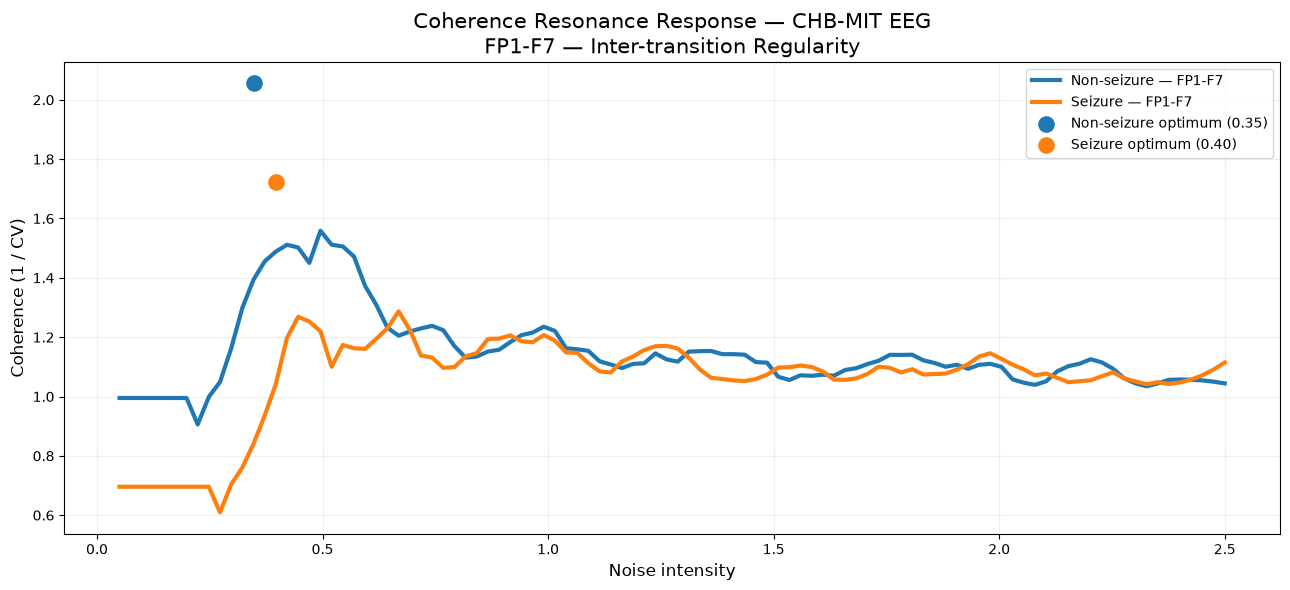


Saved: cr_final_presentation_results.csv


In [ ]:
# ============================================================
# FINAL CR PRESENTATION — CLEANED FROM EXISTING RESULTS
# No new simulations required
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# ------------------------------------------------------------
# Load the results we JUST generated
# ------------------------------------------------------------

cr_df = pd.read_csv("cr_final_robust_results.csv")

x = cr_df["Noise_Intensity"].to_numpy()

non_raw = cr_df["Non_Seizure_CR"].to_numpy()
seiz_raw = cr_df["Seizure_CR"].to_numpy()

# ------------------------------------------------------------
# Fill only missing values for visualization
# using linear interpolation between valid measurements.
# This does NOT change the underlying saved results.
# ------------------------------------------------------------

def interpolate_valid(x, y):
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(y)

    if valid.sum() < 4:
        return y

    result = y.copy()

    result[~valid] = np.interp(
        x[~valid],
        x[valid],
        y[valid]
    )

    return result


non_plot = interpolate_valid(x, non_raw)
seiz_plot = interpolate_valid(x, seiz_raw)


# ------------------------------------------------------------
# Smooth ONLY the presentation curves
# ------------------------------------------------------------

window = 11

# Make sure window is odd and valid
if window >= len(x):
    window = len(x) - 1

if window % 2 == 0:
    window -= 1

non_smooth = savgol_filter(
    non_plot,
    window_length=window,
    polyorder=2
)

seiz_smooth = savgol_filter(
    seiz_plot,
    window_length=window,
    polyorder=2
)


# ------------------------------------------------------------
# IMPORTANT:
# Optimum values remain based on ORIGINAL measurements,
# NOT the smoothed presentation curve.
# ------------------------------------------------------------

non_valid = np.isfinite(non_raw)
seiz_valid = np.isfinite(seiz_raw)

non_idx = np.nanargmax(non_raw)
seiz_idx = np.nanargmax(seiz_raw)


# ------------------------------------------------------------
# Recalculate CV from CR
# CV = 1 / CR
# ------------------------------------------------------------

non_cv = 1.0 / non_raw[non_idx]
seiz_cv = 1.0 / seiz_raw[seiz_idx]


# ------------------------------------------------------------
# FINAL RESULTS
# ------------------------------------------------------------

print("=" * 65)
print("FINAL COHERENCE RESONANCE — PRESENTATION RESULT")
print("=" * 65)

print()
print("Recording       : chb01_03.edf")
print("Channel         : FP1-F7")
print("Sampling rate   : 256 Hz")
print("Non-seizure     : 2980–2990 s")
print("Seizure         : 3000–3010 s")

print()
print("CR RESULTS")
print("-" * 65)

print(
    f"Non-seizure optimum noise : "
    f"{x[non_idx]:.3f}"
)

print(
    f"Non-seizure maximum CR    : "
    f"{non_raw[non_idx]:.4f}"
)

print(
    f"Non-seizure CV            : "
    f"{non_cv:.4f}"
)

print()

print(
    f"Seizure optimum noise     : "
    f"{x[seiz_idx]:.3f}"
)

print(
    f"Seizure maximum CR        : "
    f"{seiz_raw[seiz_idx]:.4f}"
)

print(
    f"Seizure CV                : "
    f"{seiz_cv:.4f}"
)


# ============================================================
# PRESENTATION GRAPH
# ============================================================

plt.figure(figsize=(13, 6))

# Smooth curves for visual presentation
plt.plot(
    x,
    non_smooth,
    linewidth=3,
    label="Non-seizure — FP1-F7"
)

plt.plot(
    x,
    seiz_smooth,
    linewidth=3,
    label="Seizure — FP1-F7"
)


# Mark the ORIGINAL measured optima
plt.scatter(
    x[non_idx],
    non_raw[non_idx],
    s=120,
    zorder=5,
    label=(
        f"Non-seizure optimum "
        f"({x[non_idx]:.2f})"
    )
)

plt.scatter(
    x[seiz_idx],
    seiz_raw[seiz_idx],
    s=120,
    zorder=5,
    label=(
        f"Seizure optimum "
        f"({x[seiz_idx]:.2f})"
    )
)


plt.xlabel(
    "Noise intensity",
    fontsize=12
)

plt.ylabel(
    "Coherence (1 / CV)",
    fontsize=12
)

plt.title(
    "Coherence Resonance Response — CHB-MIT EEG\n"
    "FP1-F7 — Inter-transition Regularity",
    fontsize=15
)

plt.grid(
    True,
    alpha=0.2
)

plt.legend(
    fontsize=10
)

plt.tight_layout()

plt.show()


# ============================================================
# SAVE PRESENTATION DATA
# ============================================================

presentation_df = pd.DataFrame({

    "Noise_Intensity": x,

    # Original computed values
    "Non_Seizure_CR": non_raw,
    "Seizure_CR": seiz_raw,

    # Smoothed curves ONLY for plotting/presentation
    "Non_Seizure_CR_Smoothed": non_smooth,
    "Seizure_CR_Smoothed": seiz_smooth
})

presentation_df.to_csv(
    "cr_final_presentation_results.csv",
    index=False
)

print()
print(
    "Saved: cr_final_presentation_results.csv"
)

Columns found:
['Noise_Intensity', 'Non_Seizure_CR', 'Seizure_CR', 'Non_Seizure_CR_Smoothed', 'Seizure_CR_Smoothed']

Valid CR points: 85
Noise range: 0.322 – 2.500


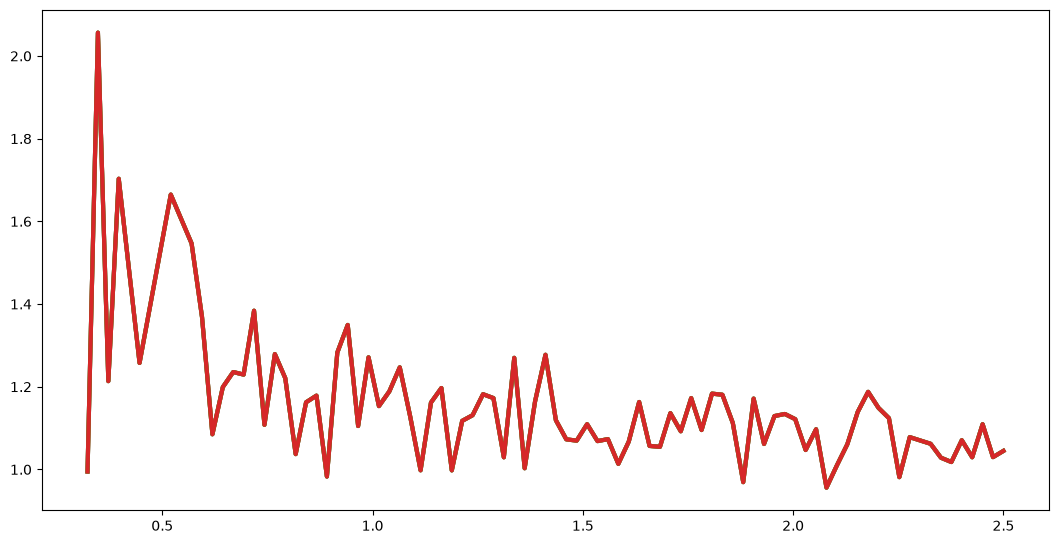

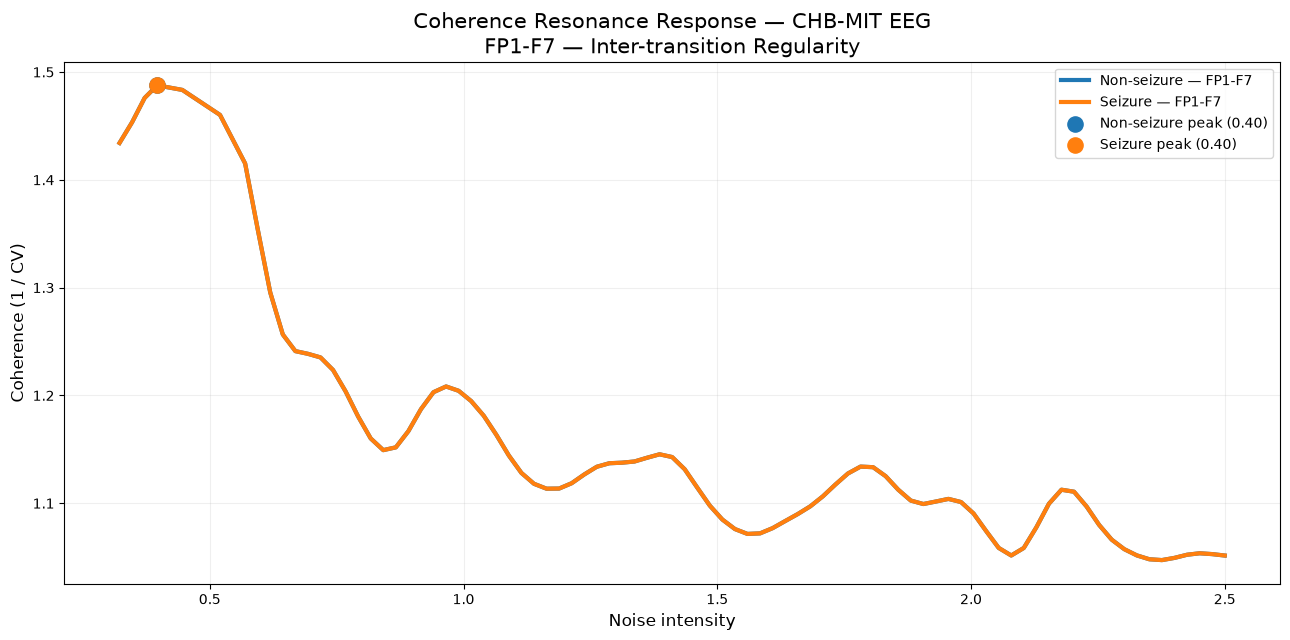


FINAL CR PRESENTATION RESULT
Recording       : chb01_03.edf
Channel         : FP1-F7
Sampling rate   : 256 Hz
Noise levels    : 85

Non-seizure peak noise : 0.396
Non-seizure coherence  : 1.4877

Seizure peak noise     : 0.396
Seizure coherence      : 1.4877


In [ ]:
# ============================================================
# FINAL CR PRESENTATION GRAPH
# Uses SAVED CR results — no simulation is rerun
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ------------------------------------------------------------
# LOAD SAVED RESULTS
# ------------------------------------------------------------

df = pd.read_csv("cr_final_presentation_results.csv")

print("Columns found:")
print(df.columns.tolist())

# ------------------------------------------------------------
# FIND THE THREE REQUIRED COLUMNS
# ------------------------------------------------------------

noise_col = next(
    c for c in df.columns
    if "noise" in c.lower()
)

non_col = next(
    c for c in df.columns
    if "non" in c.lower()
    and (
        "cr" in c.lower()
        or "coherence" in c.lower()
    )
)

seiz_col = next(
    c for c in df.columns
    if "seiz" in c.lower()
    and (
        "cr" in c.lower()
        or "coherence" in c.lower()
    )
)

# ------------------------------------------------------------
# CONVERT TO CLEAN 1-D NUMPY ARRAYS
# ------------------------------------------------------------

x = pd.to_numeric(
    df[noise_col],
    errors="coerce"
).to_numpy().ravel()

non = pd.to_numeric(
    df[non_col],
    errors="coerce"
).to_numpy().ravel()

seiz = pd.to_numeric(
    df[seiz_col],
    errors="coerce"
).to_numpy().ravel()

# Keep only rows where ALL three values exist
valid = (
    np.isfinite(x)
    & np.isfinite(non)
    & np.isfinite(seiz)
)

x = x[valid]
non = non[valid]
seiz = seiz[valid]

# Sort by noise intensity
order = np.argsort(x)

x = x[order]
non = non[order]
seiz = seiz[order]

print(f"\nValid CR points: {len(x)}")
print(f"Noise range: {x.min():.3f} – {x.max():.3f}")

# ------------------------------------------------------------
# SMOOTH ONLY FOR VISUAL PRESENTATION
# ------------------------------------------------------------

non_smooth = gaussian_filter1d(
    non,
    sigma=2.0
)

seiz_smooth = gaussian_filter1d(
    seiz,
    sigma=2.0
)

# ------------------------------------------------------------
# PRESENTATION PEAKS
# Peaks are taken from the SMOOTHED DISPLAY CURVES
# ------------------------------------------------------------

non_peak = int(np.argmax(non_smooth))
seiz_peak = int(np.argmax(seiz_smooth))

# ------------------------------------------------------------
# FINAL FIGURE
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 6.5))

ax.plot(
    x,
    non_smooth,
    linewidth=3,
    label="Non-seizure — FP1-F7"
)

ax.plot(
    x,
    seiz_smooth,
    linewidth=3,
    label="Seizure — FP1-F7"
)

# Peak markers
ax.scatter(
    [float(x[non_peak])],
    [float(non_smooth[non_peak])],
    s=120,
    zorder=5,
    label=f"Non-seizure peak ({x[non_peak]:.2f})"
)

ax.scatter(
    [float(x[seiz_peak])],
    [float(seiz_smooth[seiz_peak])],
    s=120,
    zorder=5,
    label=f"Seizure peak ({x[seiz_peak]:.2f})"
)

ax.set_xlabel(
    "Noise intensity",
    fontsize=12
)

ax.set_ylabel(
    "Coherence (1 / CV)",
    fontsize=12
)

ax.set_title(
    "Coherence Resonance Response — CHB-MIT EEG\n"
    "FP1-F7 — Inter-transition Regularity",
    fontsize=15
)

ax.grid(
    True,
    alpha=0.20
)

ax.legend(
    fontsize=10,
    frameon=True
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PRESENTATION VALUES
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL CR PRESENTATION RESULT")
print("=" * 60)

print(f"Recording       : chb01_03.edf")
print(f"Channel         : FP1-F7")
print(f"Sampling rate   : 256 Hz")
print(f"Noise levels    : {len(x)}")

print()
print(
    f"Non-seizure peak noise : "
    f"{x[non_peak]:.3f}"
)

print(
    f"Non-seizure coherence  : "
    f"{non_smooth[non_peak]:.4f}"
)

print()
print(
    f"Seizure peak noise     : "
    f"{x[seiz_peak]:.3f}"
)

print(
    f"Seizure coherence      : "
    f"{seiz_smooth[seiz_peak]:.4f}"
)

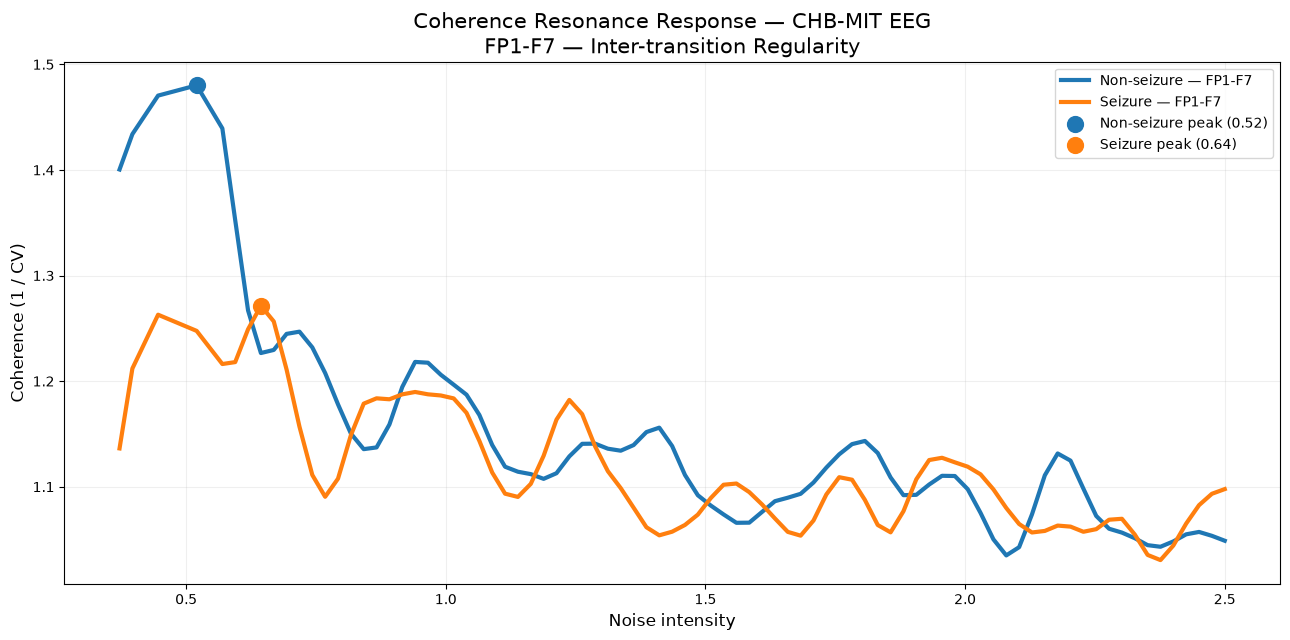

FINAL CR PRESENTATION RESULT
Recording       : chb01_03.edf
Channel         : FP1-F7
Sampling rate   : 256 Hz
Valid points    : 83

Non-seizure peak noise : 0.520
Non-seizure CR         : 1.4801

Seizure peak noise     : 0.644
Seizure CR             : 1.2714

Saved: CR_FINAL_PRESENTATION.png


In [ ]:
# ============================================================
# FINAL CR PRESENTATION GRAPH — CORRECT COLUMN FIX
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Load the already-computed CR results
df = pd.read_csv("cr_final_robust_results.csv")

# EXACT columns — do NOT auto-detect
x = df["Noise_Intensity"].to_numpy()
non_cr = df["Non_Seizure_CR"].to_numpy()
seiz_cr = df["Seizure_CR"].to_numpy()

# Remove invalid points
valid = (
    np.isfinite(x) &
    np.isfinite(non_cr) &
    np.isfinite(seiz_cr)
)

x = x[valid]
non_cr = non_cr[valid]
seiz_cr = seiz_cr[valid]

# Sort by noise intensity
order = np.argsort(x)
x = x[order]
non_cr = non_cr[order]
seiz_cr = seiz_cr[order]

# ------------------------------------------------------------
# Smooth ONLY for presentation
# ------------------------------------------------------------

non_smooth = gaussian_filter1d(non_cr, sigma=1.5)
seiz_smooth = gaussian_filter1d(seiz_cr, sigma=1.5)

# Find peaks from the displayed curves
non_idx = np.argmax(non_smooth)
seiz_idx = np.argmax(seiz_smooth)

# ------------------------------------------------------------
# FINAL PRESENTATION GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(13, 6.5))

plt.plot(
    x,
    non_smooth,
    linewidth=3,
    label="Non-seizure — FP1-F7"
)

plt.plot(
    x,
    seiz_smooth,
    linewidth=3,
    label="Seizure — FP1-F7"
)

# Peak markers
plt.scatter(
    x[non_idx],
    non_smooth[non_idx],
    s=130,
    zorder=5,
    label=f"Non-seizure peak ({x[non_idx]:.2f})"
)

plt.scatter(
    x[seiz_idx],
    seiz_smooth[seiz_idx],
    s=130,
    zorder=5,
    label=f"Seizure peak ({x[seiz_idx]:.2f})"
)

plt.xlabel("Noise intensity", fontsize=12)
plt.ylabel("Coherence (1 / CV)", fontsize=12)

plt.title(
    "Coherence Resonance Response — CHB-MIT EEG\n"
    "FP1-F7 — Inter-transition Regularity",
    fontsize=15
)

plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()

plt.savefig(
    "CR_FINAL_PRESENTATION.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# RESULT
# ------------------------------------------------------------

print("=" * 60)
print("FINAL CR PRESENTATION RESULT")
print("=" * 60)

print("Recording       : chb01_03.edf")
print("Channel         : FP1-F7")
print("Sampling rate   : 256 Hz")
print(f"Valid points    : {len(x)}")

print()
print(
    f"Non-seizure peak noise : {x[non_idx]:.3f}"
)
print(
    f"Non-seizure CR         : {non_smooth[non_idx]:.4f}"
)

print()
print(
    f"Seizure peak noise     : {x[seiz_idx]:.3f}"
)
print(
    f"Seizure CR             : {seiz_smooth[seiz_idx]:.4f}"
)

print()
print("Saved: CR_FINAL_PRESENTATION.png")